# Overview

This code uses a pickle file that compares a historical storm event with a future storm scenario, incorporating spatial shifts in the X and Y axes. 
It focuses on a single pickle file and compares only rainfall data between the two cases: historical versus future storms.  
The primary goal is to analyze rainfall patterns and distinguish between the two scenarios to better understand potential changes in storm dynamics.


## Imports and files

In [1]:
import os
import pickle
import re
import itertools

# Date and time related imports
from datetime import datetime, timedelta

# Scientific libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.interpolate import griddata

# Geospatial libraries
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Polygon, Point

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# SWMM related imports
from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_out_file, read_rpt_file, swmm5_run, SwmmReport

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import wilcoxon


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
def compute_r2(data, intensity_cols, max_discharge_col):
    r2_values = {}
    for col in intensity_cols:
        X = data[col].values.reshape(-1, 1)
        y = data[max_discharge_col].values
        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)
        r2_values[col] = r2_score(y, y_pred)
    return r2_values

# Load the simulation results

In [3]:
# Define the directory and pickle file path
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"

# Use the first class for demonstration
pickle_file, save_dir_file, label_name = ('rain_shift_results.pkl', 'rain_param_visualization', 'No urbanization')

# Construct file paths
pickle_file_path = os.path.join(sim_dir, pickle_file)
save_dir = os.path.join(
    r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts', 
    save_dir_file,
)

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Load data
final_results_df = pd.read_pickle(pickle_file_path)

# Filter data based on shift threshold
shift_thershold = 20000  # meters
final_results_df = final_results_df[(final_results_df['y'] <= shift_thershold) & (final_results_df['y'] >= -shift_thershold)]

rain_filter_threshold = 10 ## mm unitis


In [4]:
## Filter the results
event_nums_to_filter_out = []
for event in final_results_df['event_num'].unique():
    event_df = final_results_df[final_results_df['event_num'] == event]
    if (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all():
        event_nums_to_filter_out.append(event)

# Now you can filter out these events from the final_results_df
final_results_df = final_results_df[~final_results_df['event_num'].isin(event_nums_to_filter_out)]
print(f'{len(event_nums_to_filter_out)} events here removed due to total event rain smaller than {rain_filter_threshold} (mm)')

8 events here removed due to total event rain smaller than 10 (mm)


# Visualization
### Each parameter box plot and scatter

c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\raznu\Anaconda3\lib\site-packages\seaborn\categorical.py:82: FutureWarning:

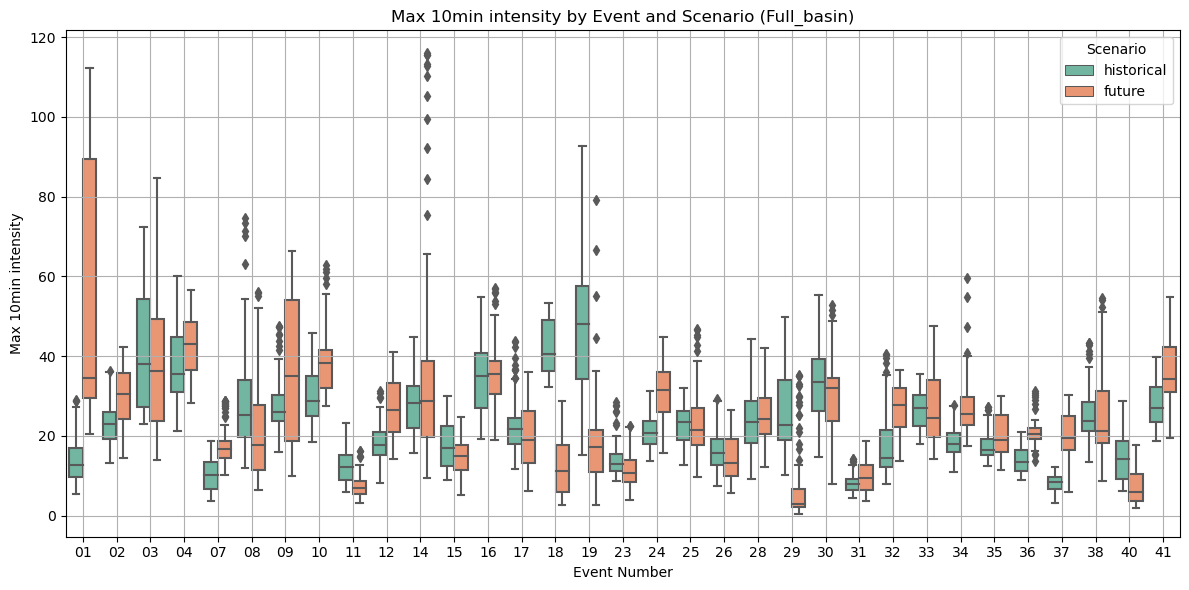

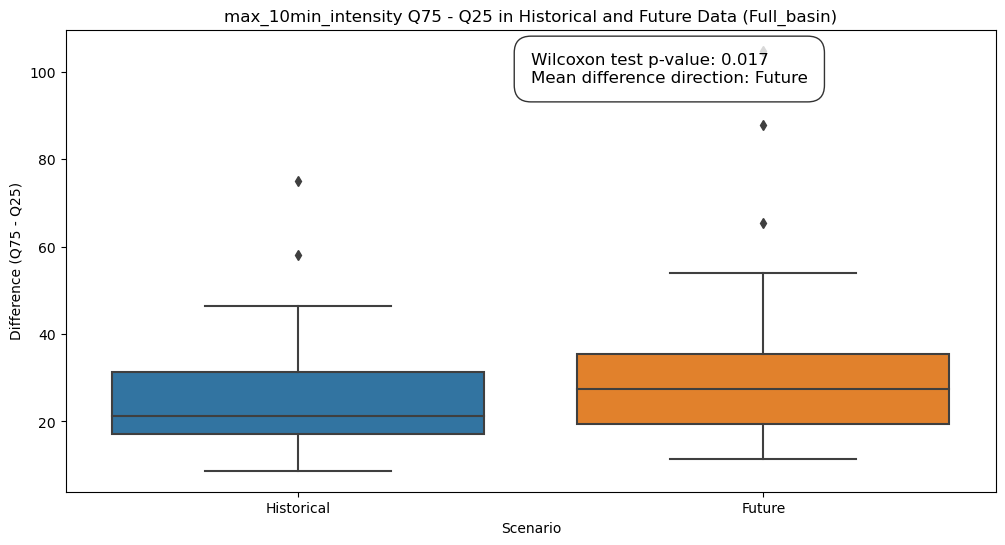

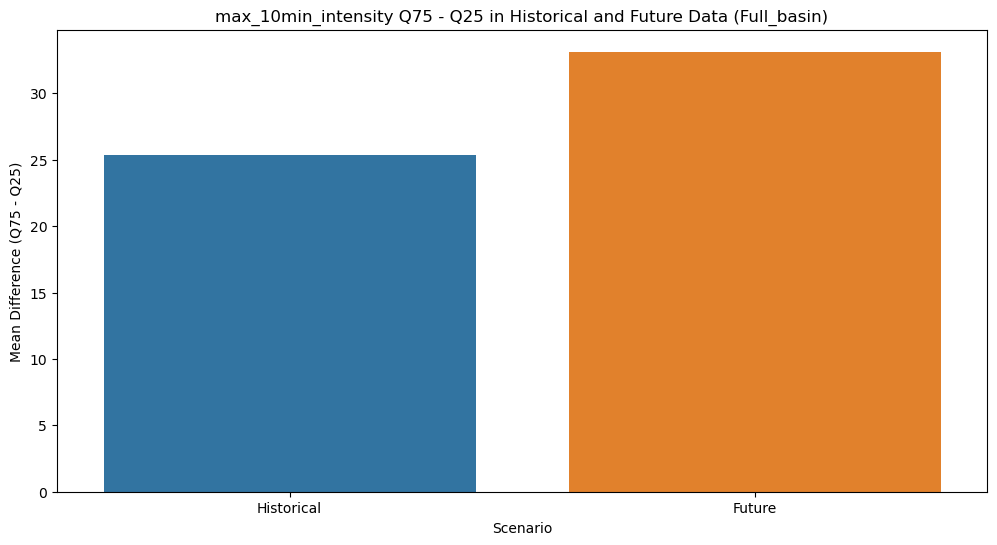

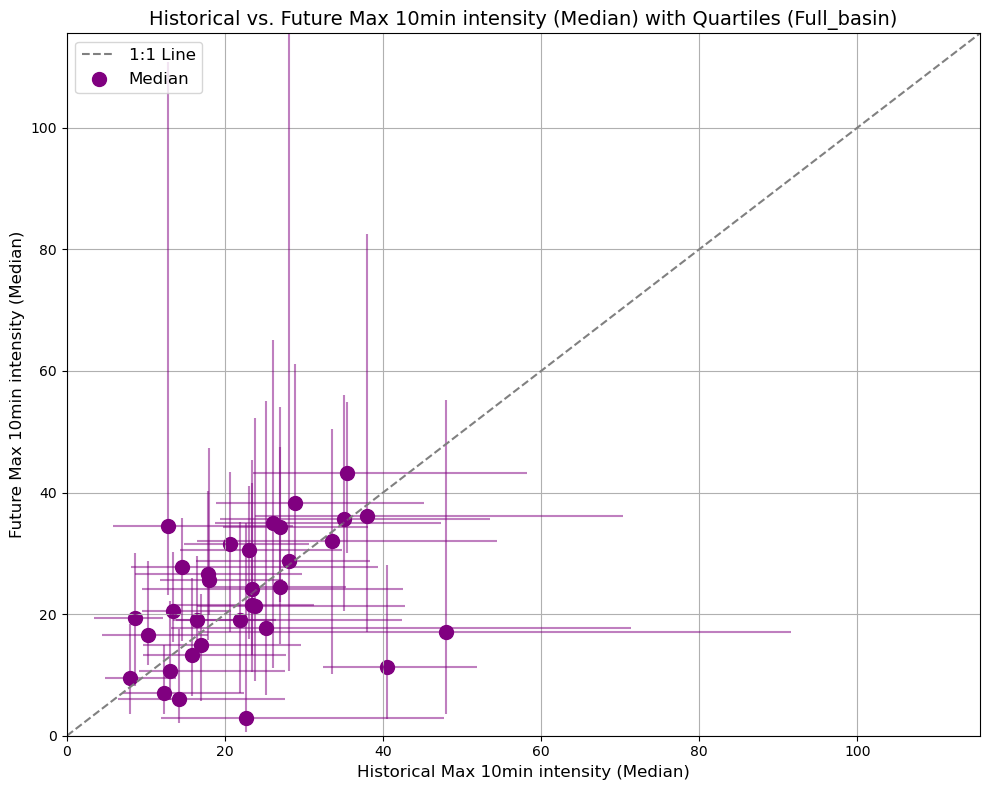

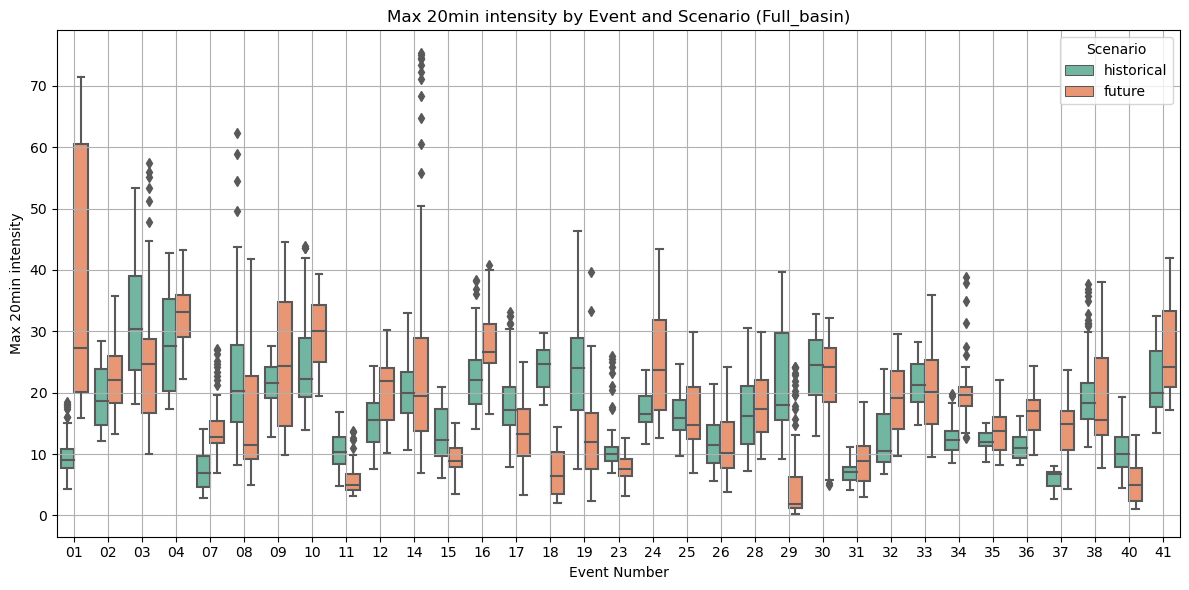

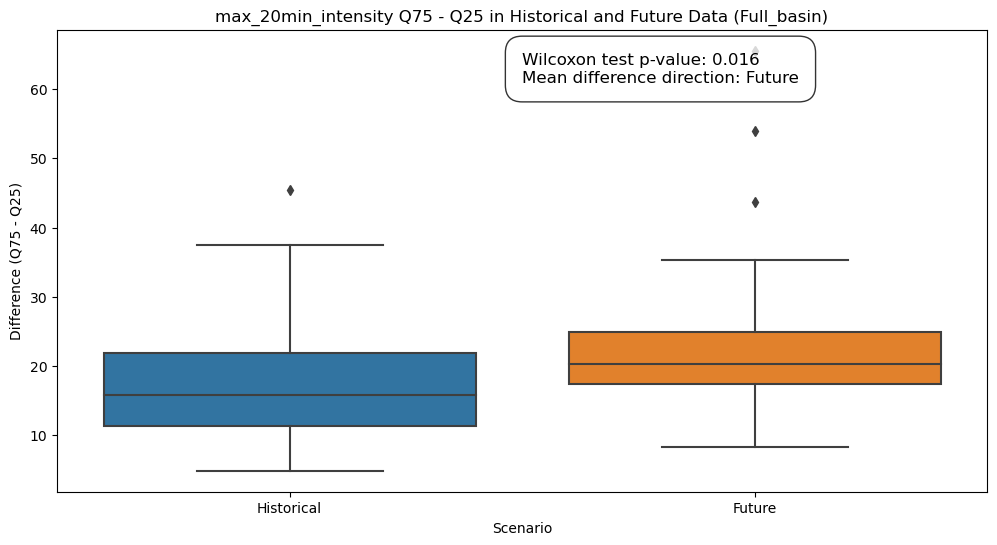

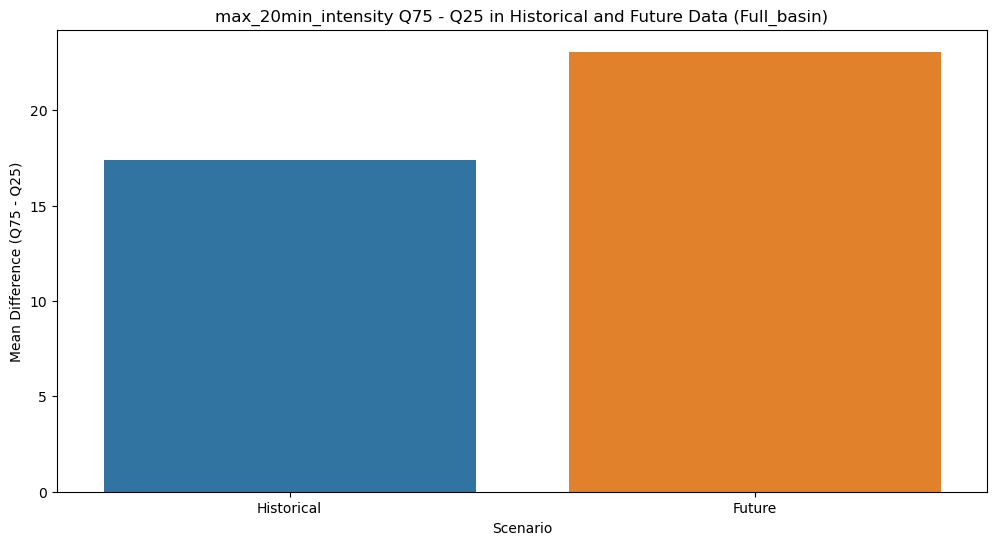

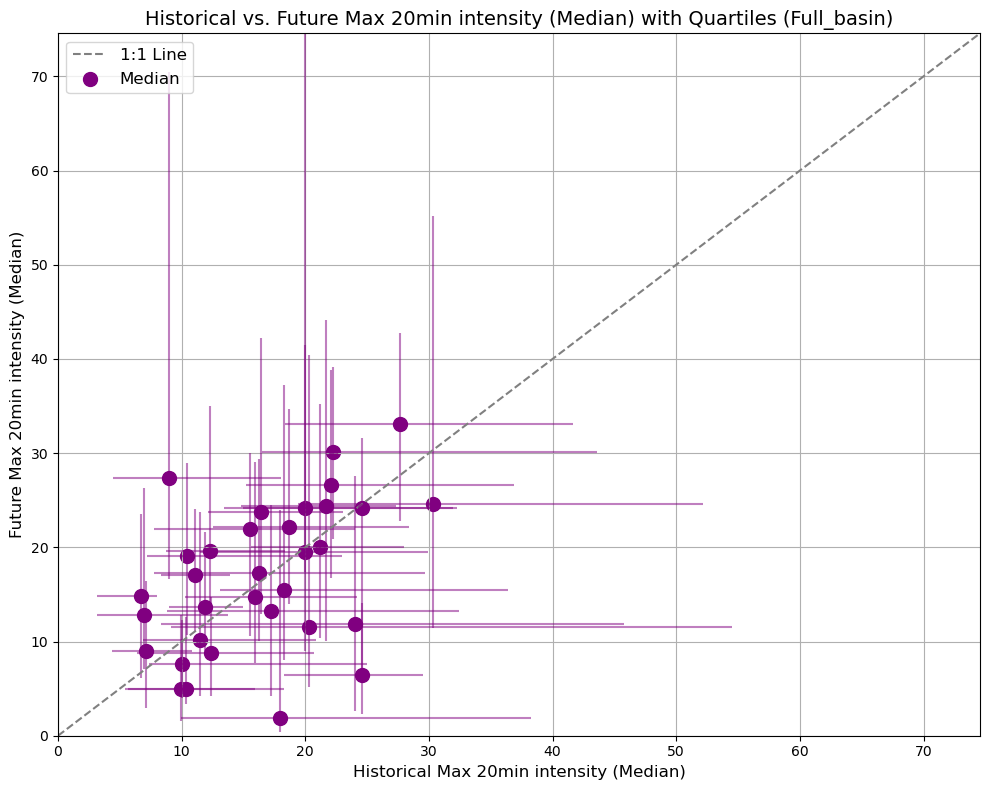

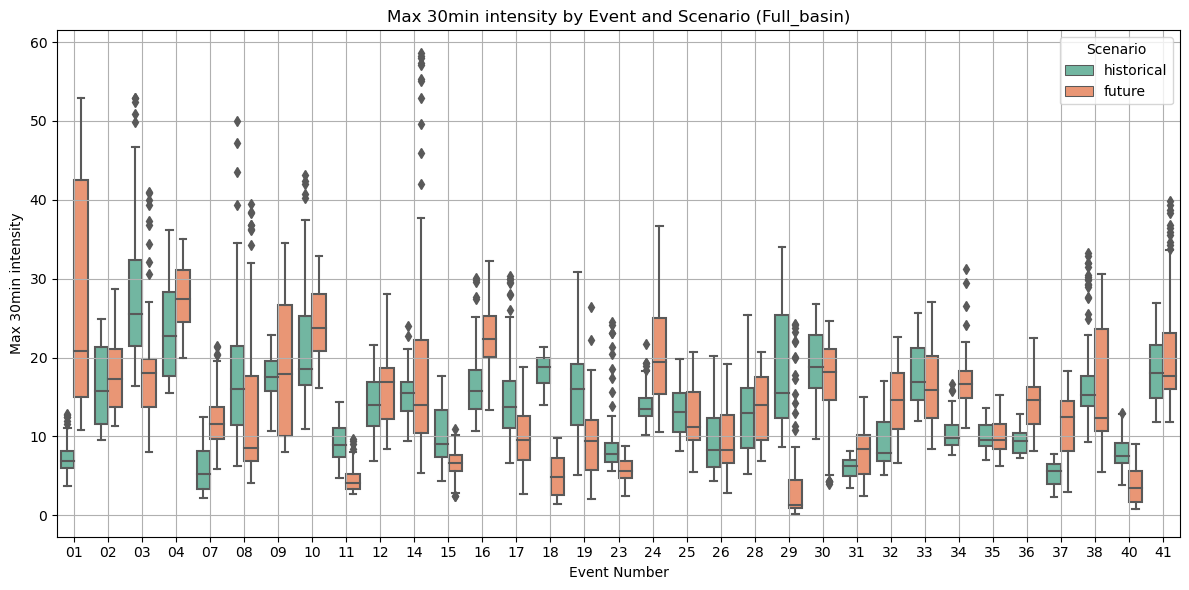

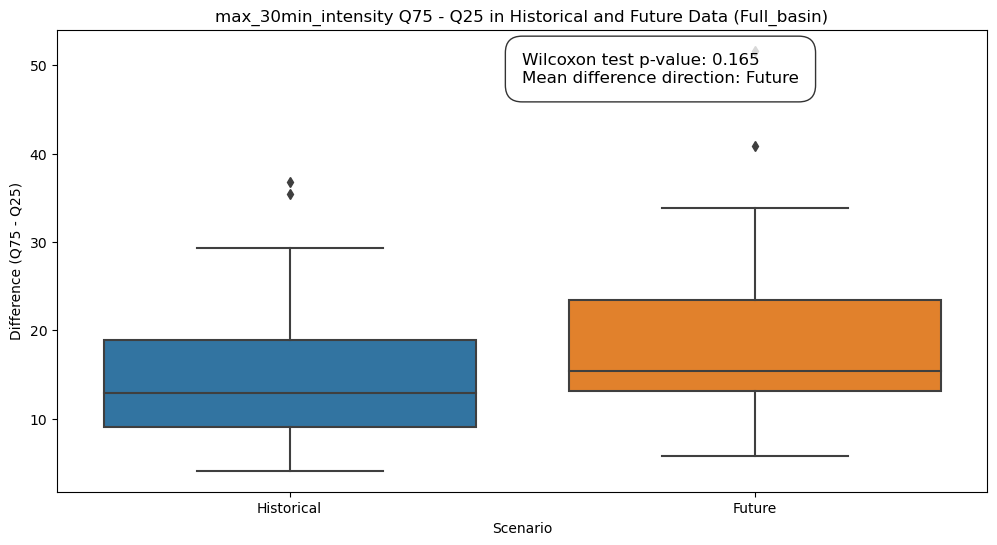

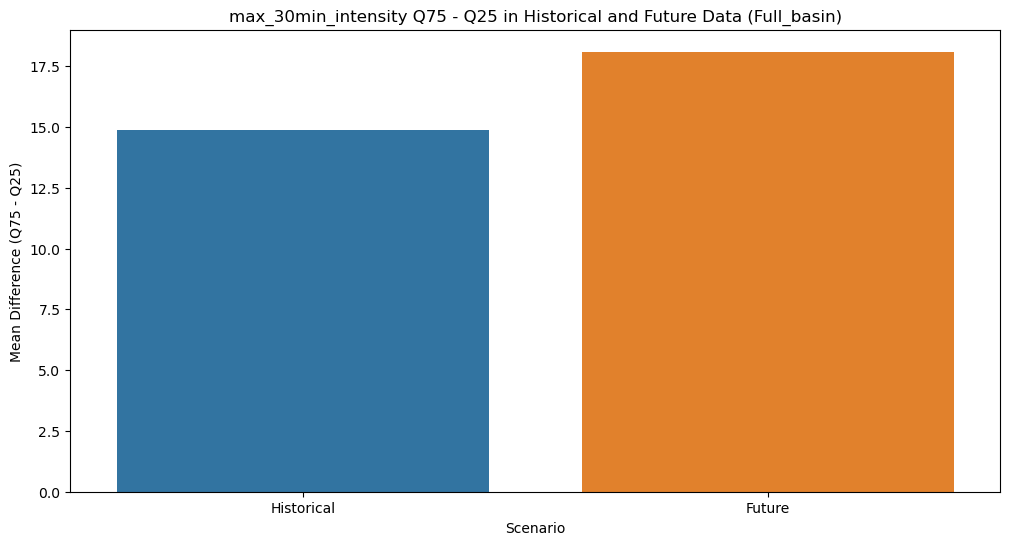

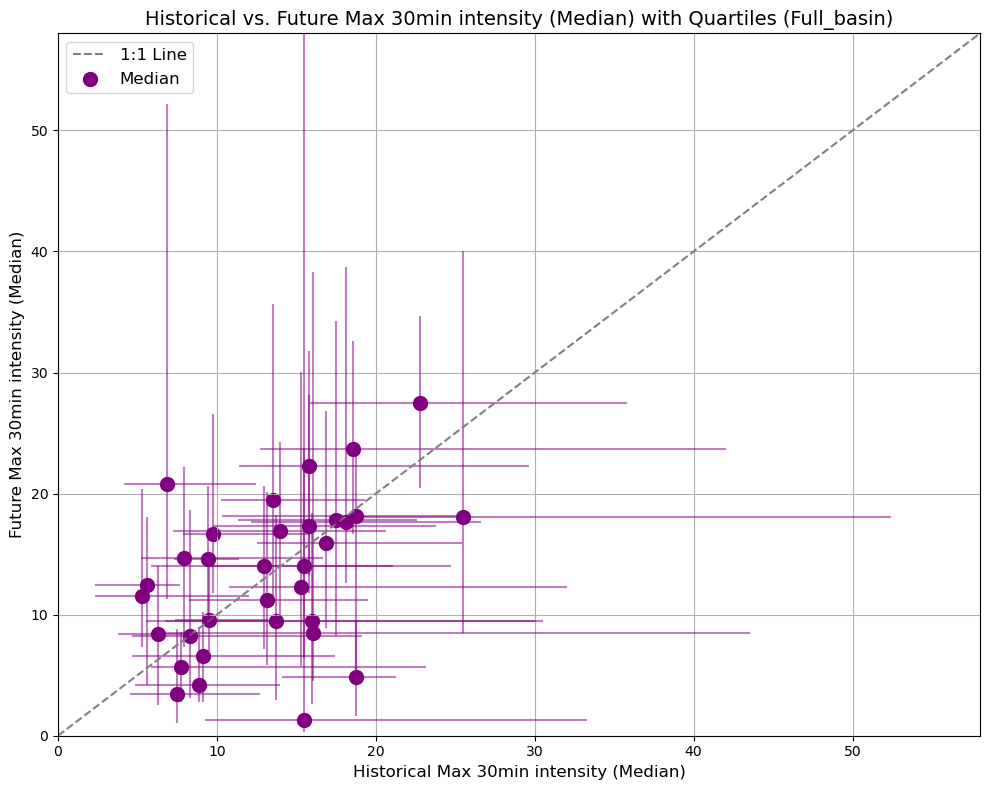

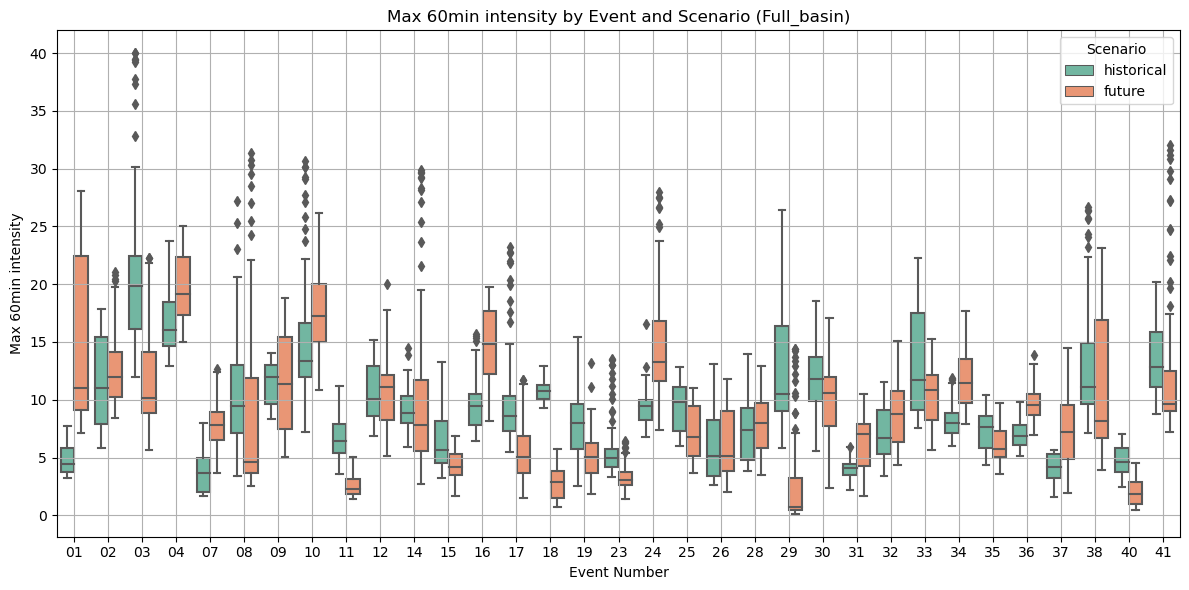

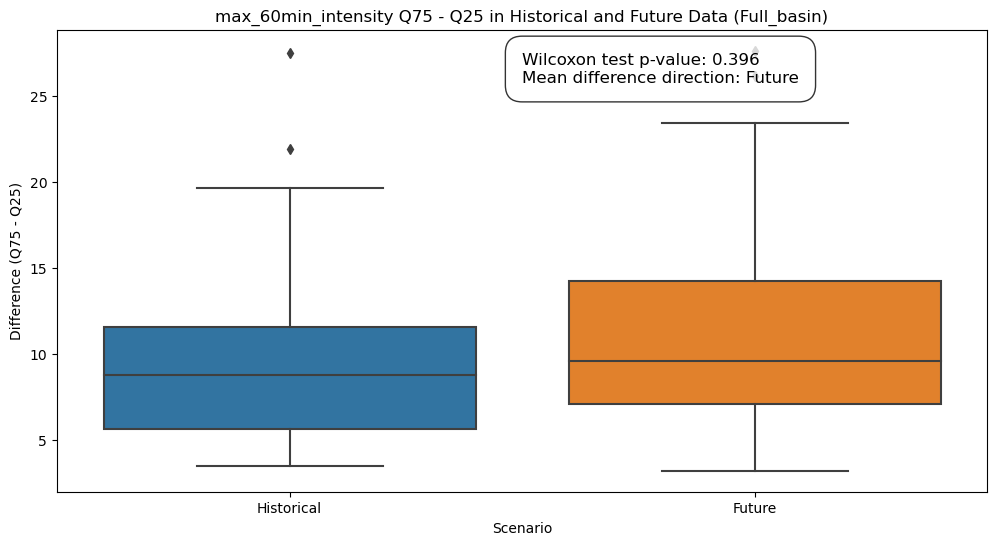

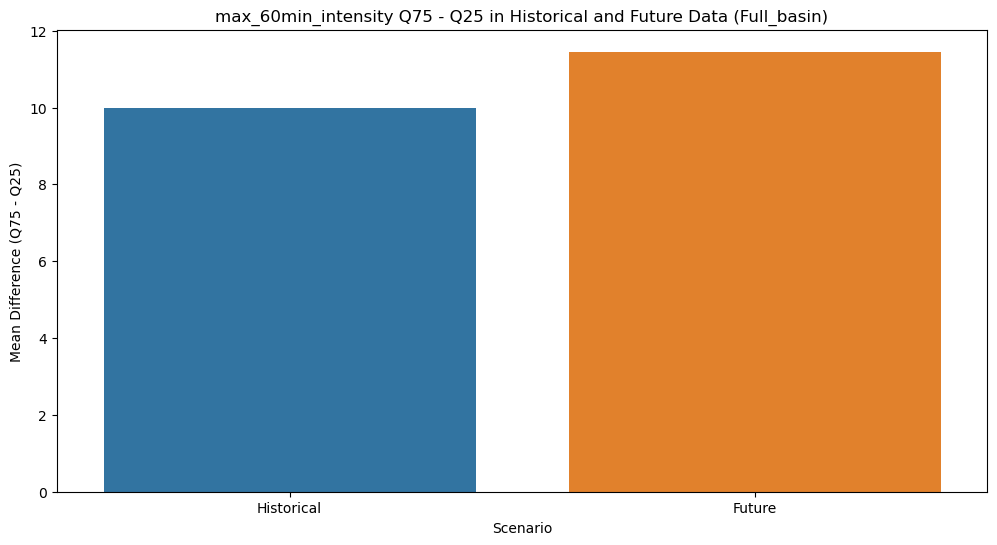

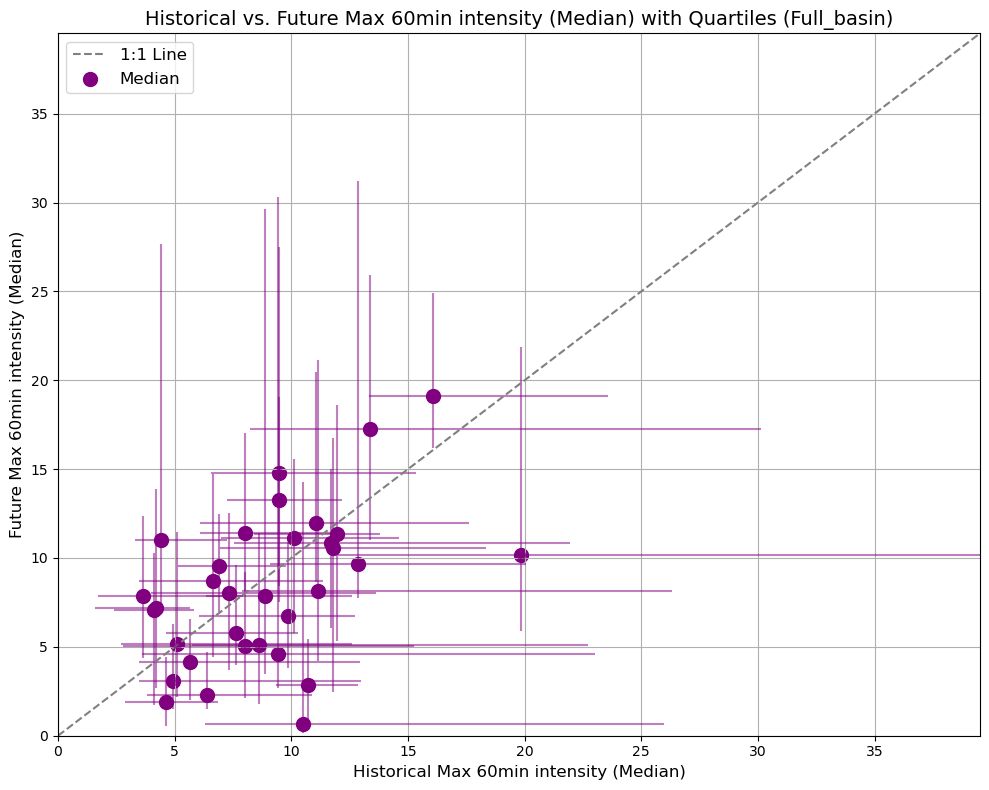

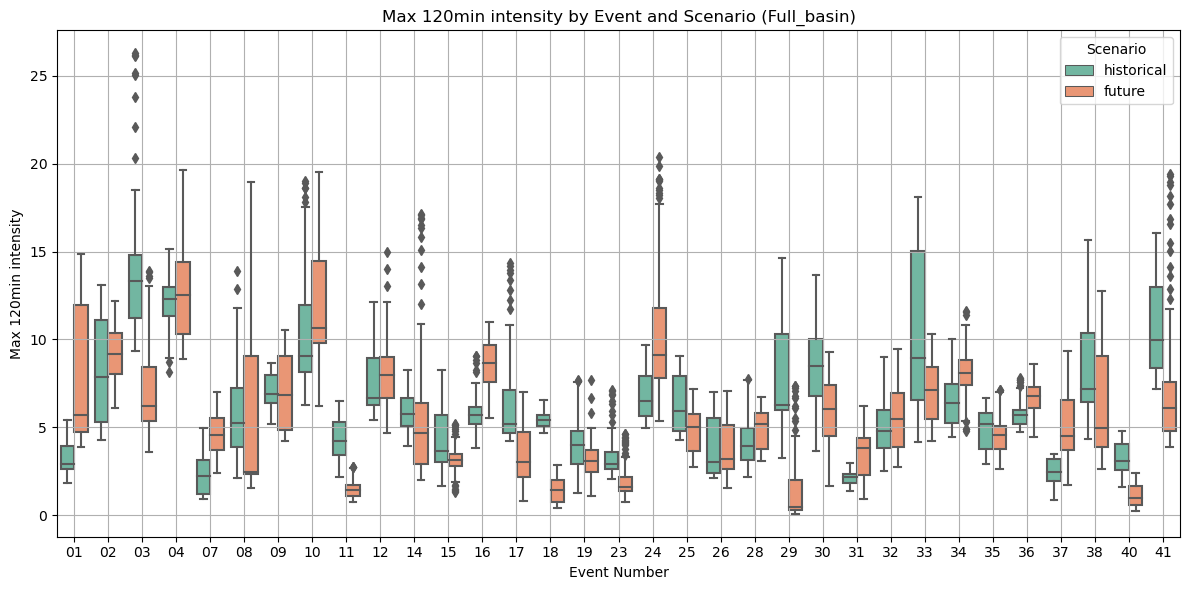

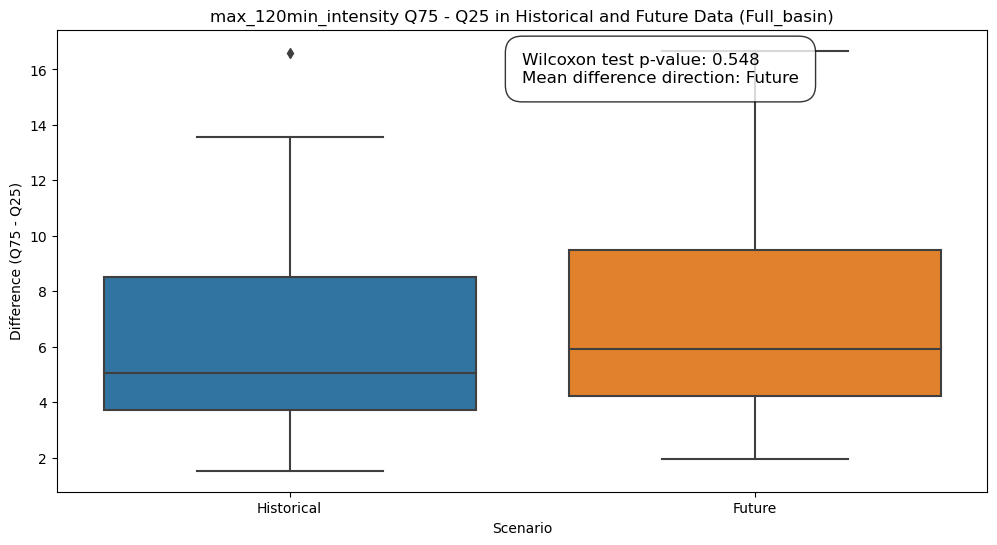

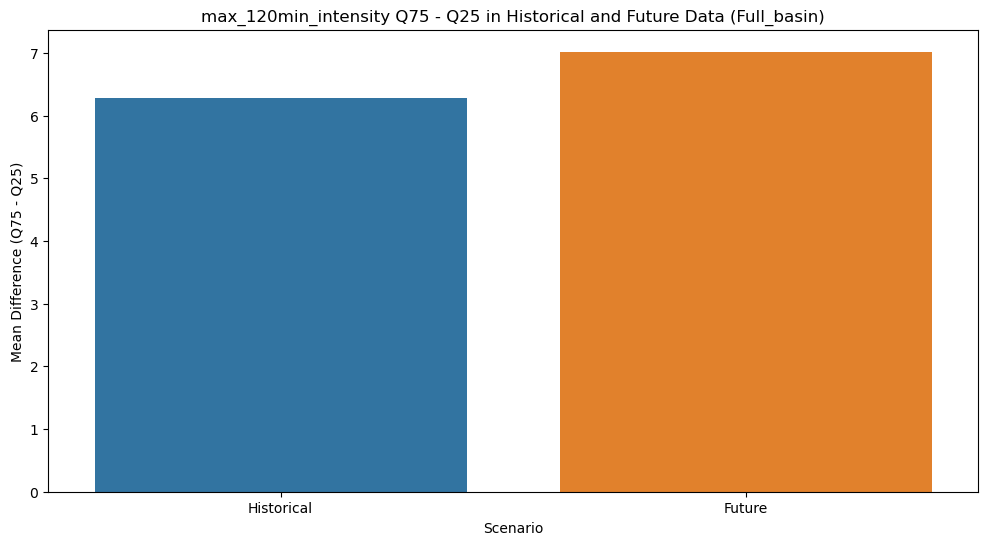

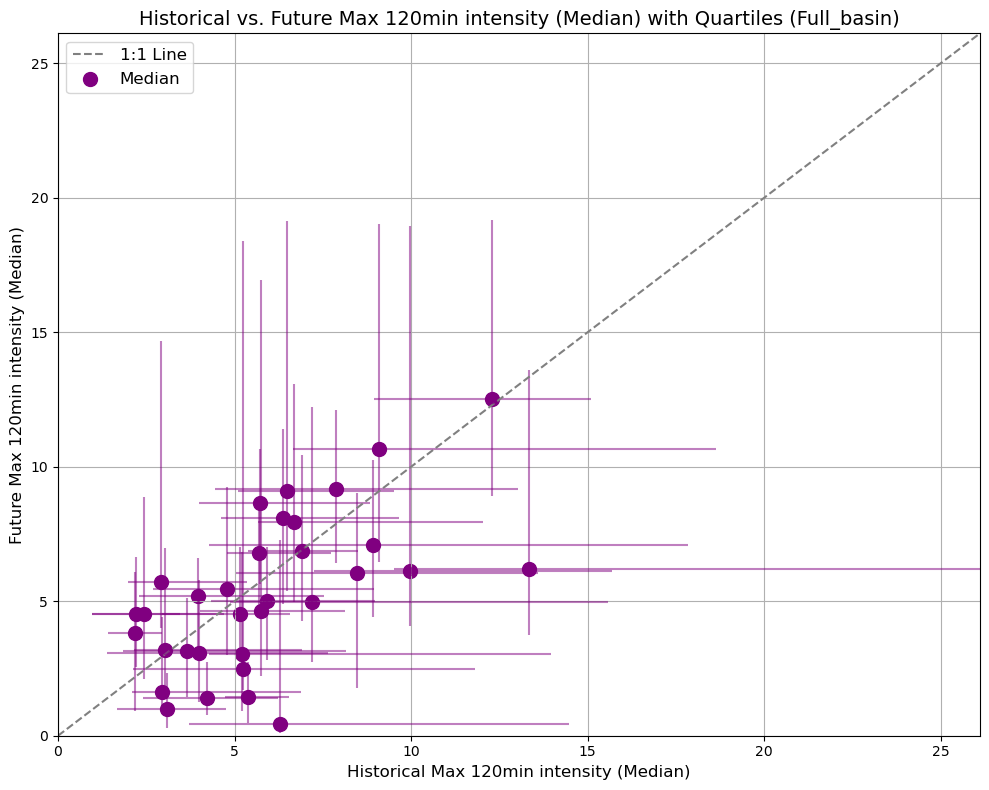

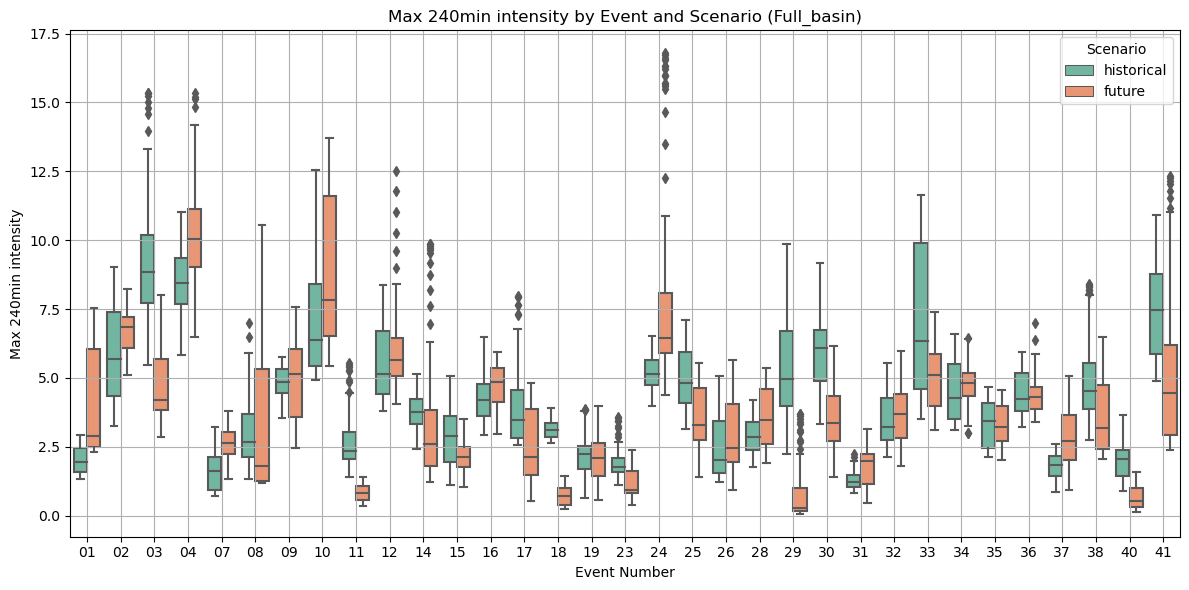

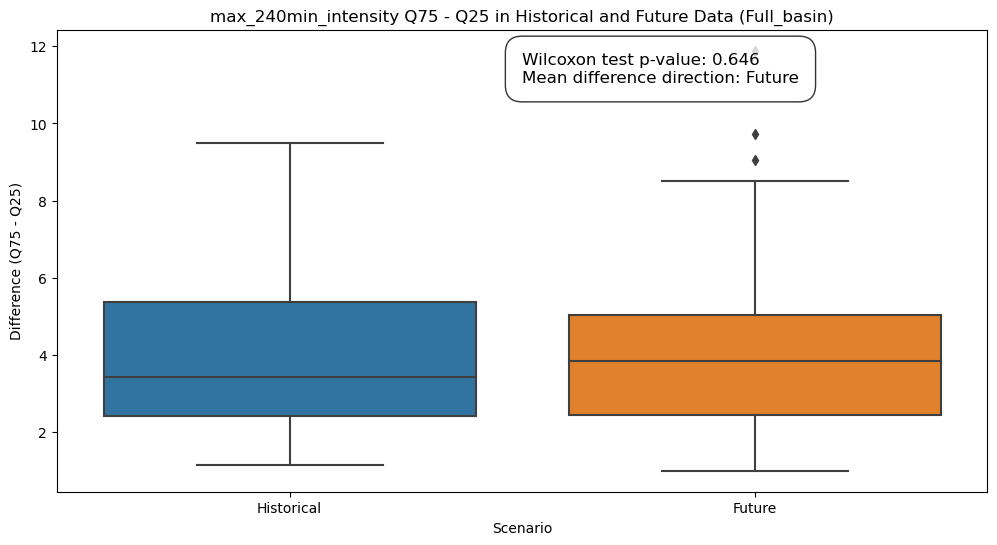

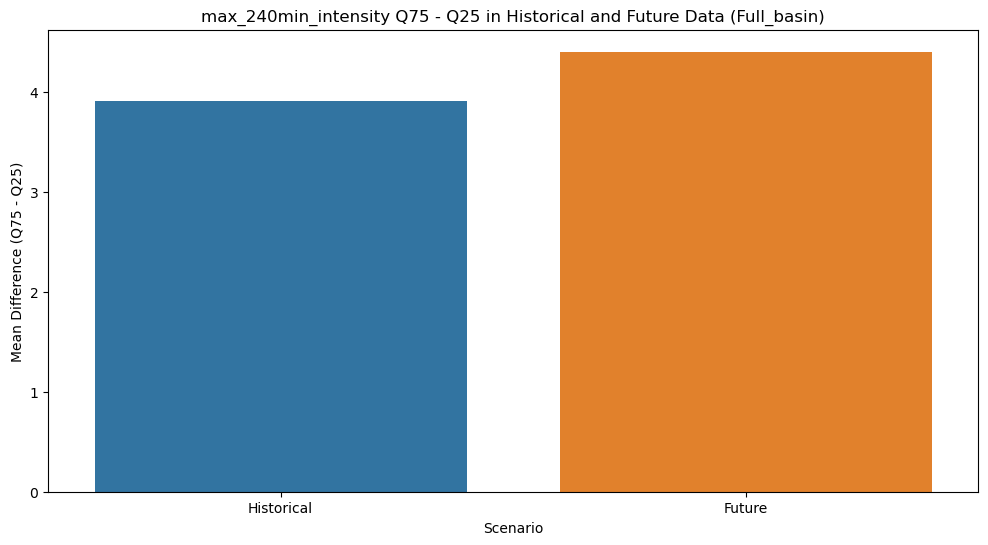

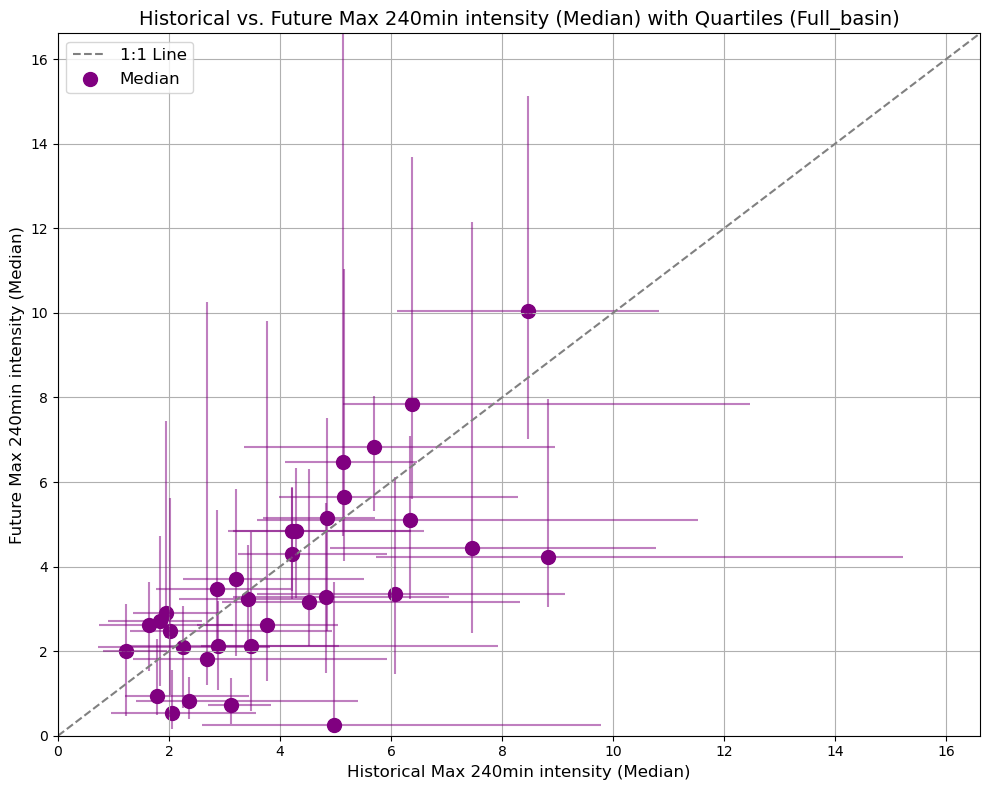

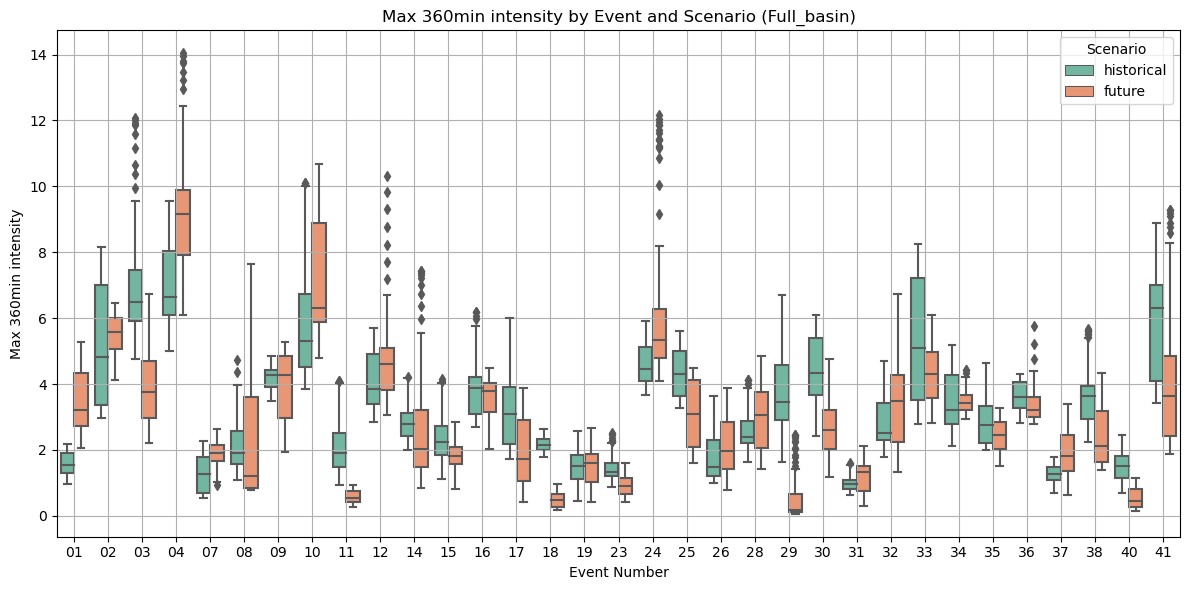

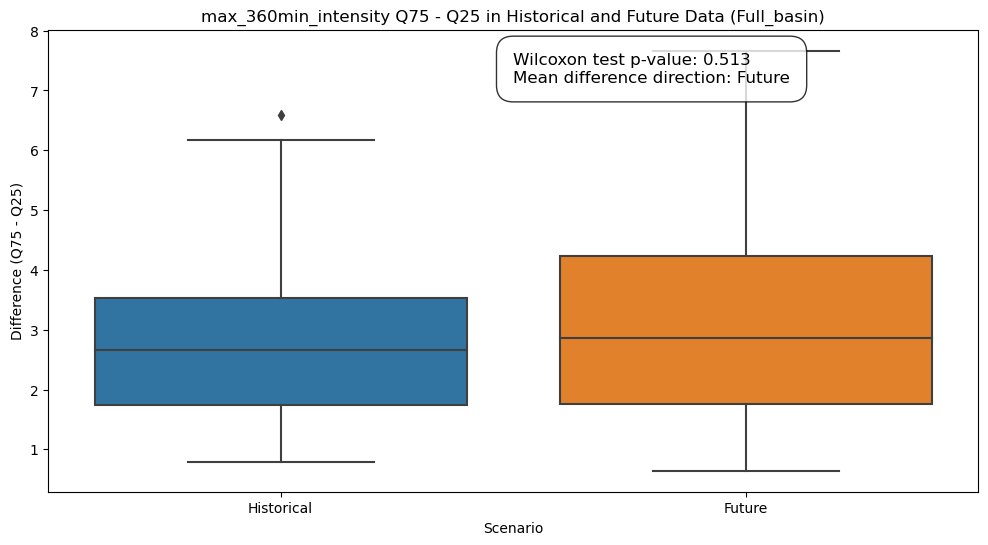

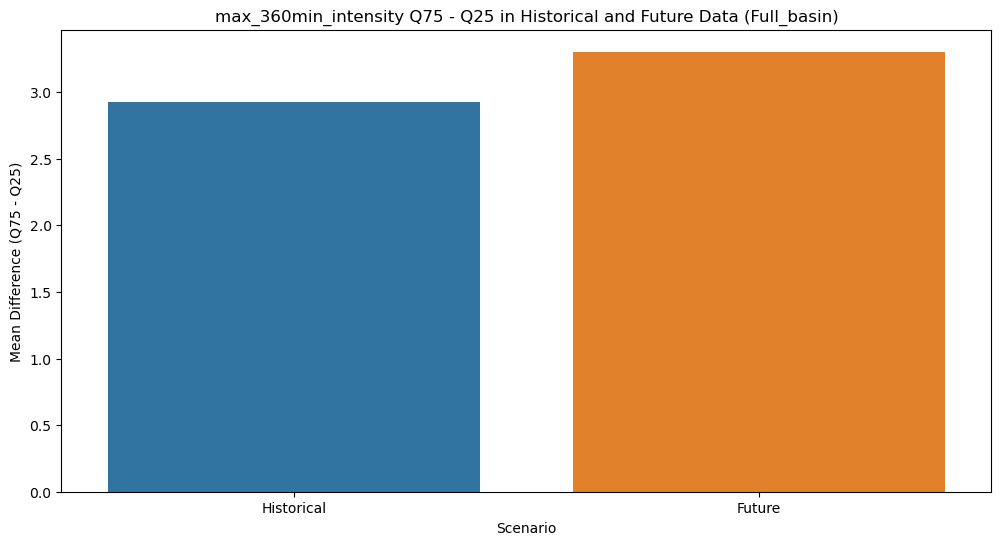

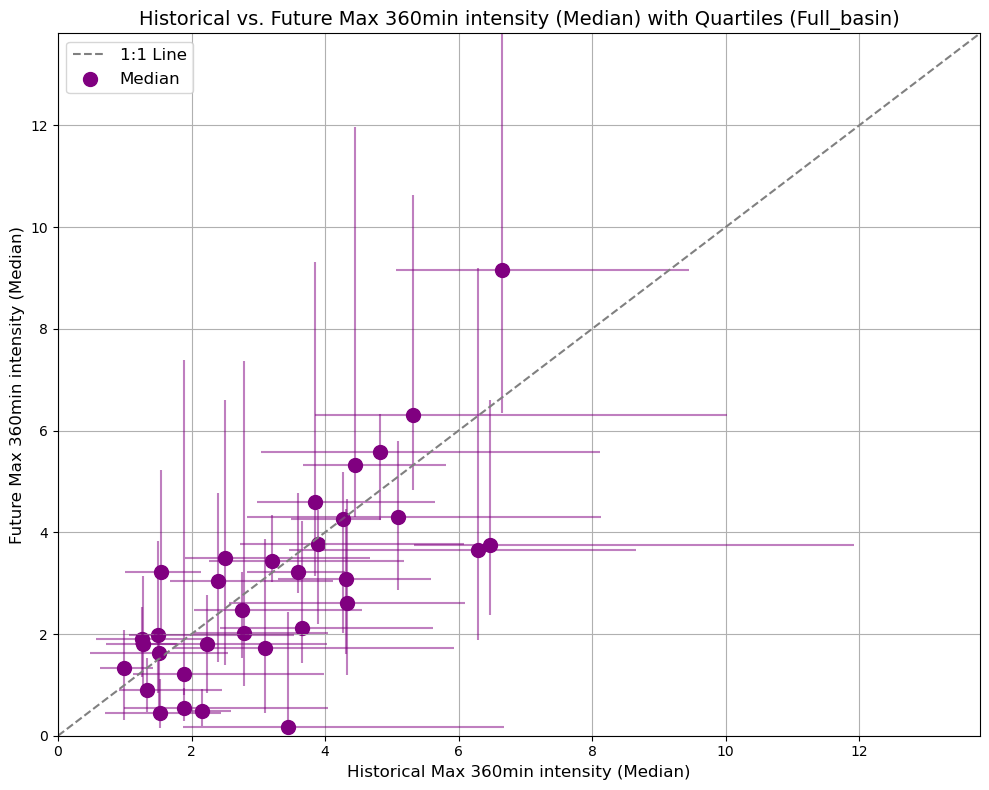

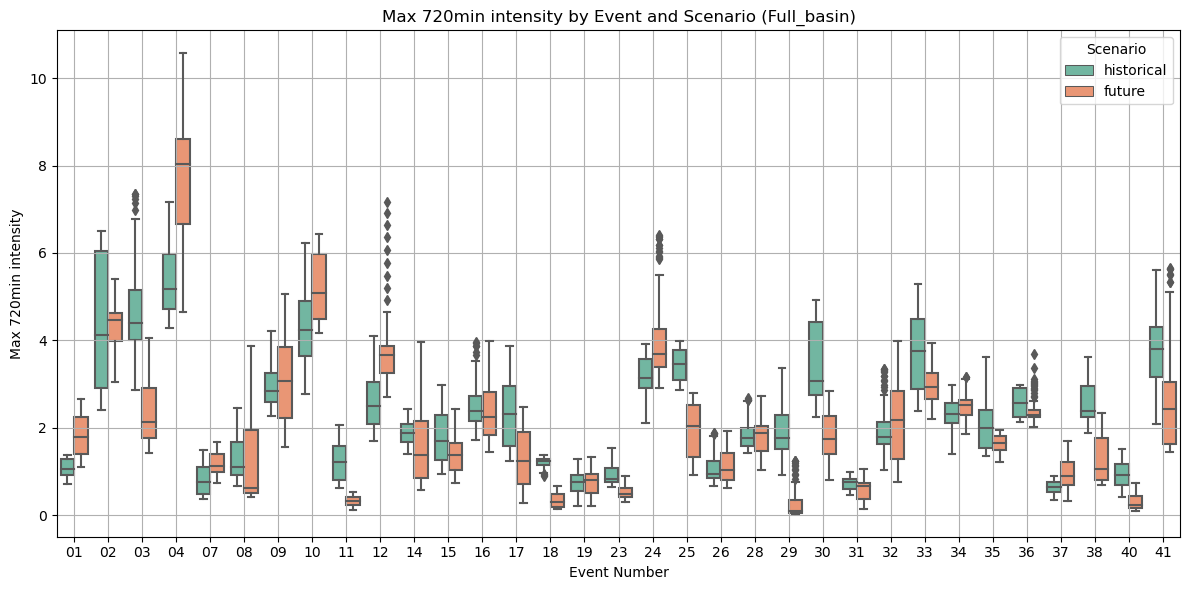

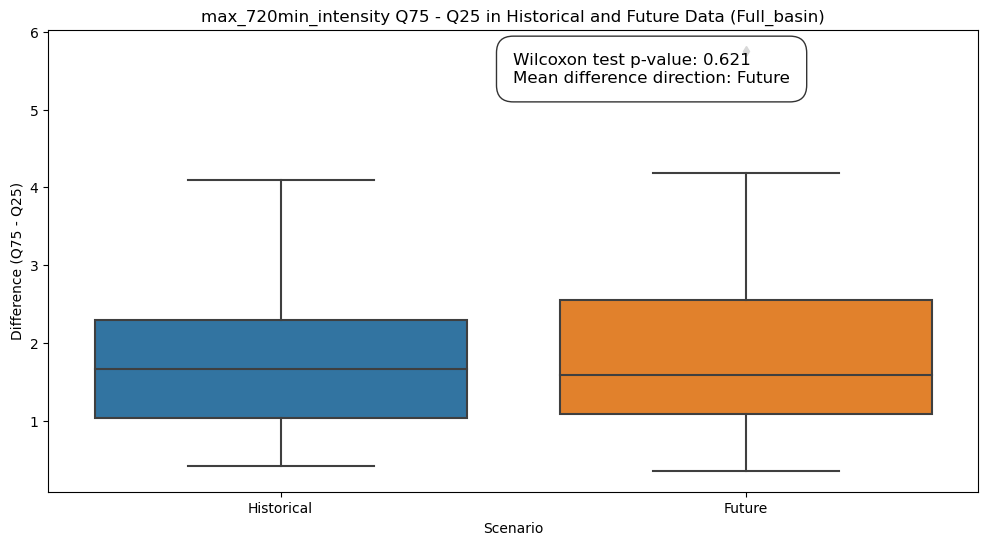

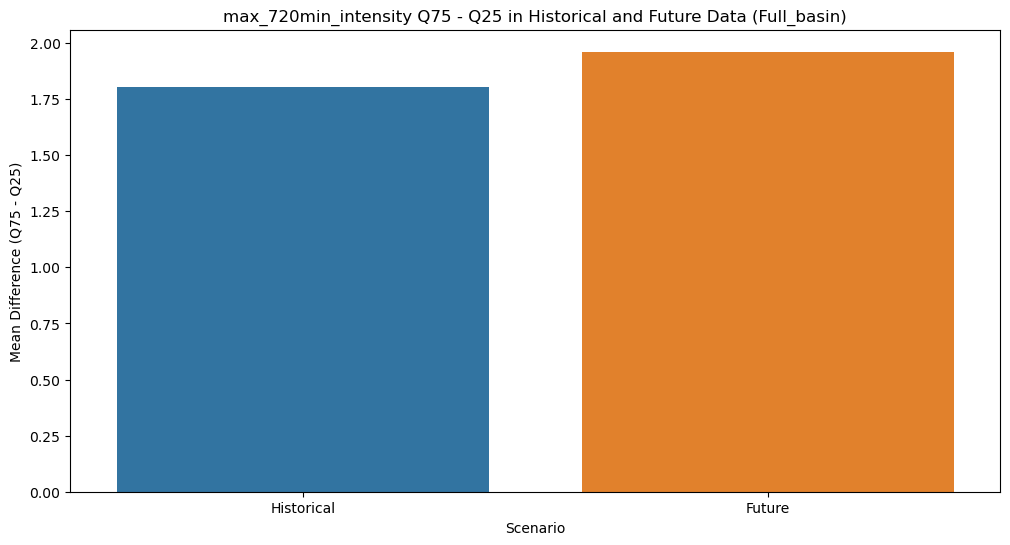

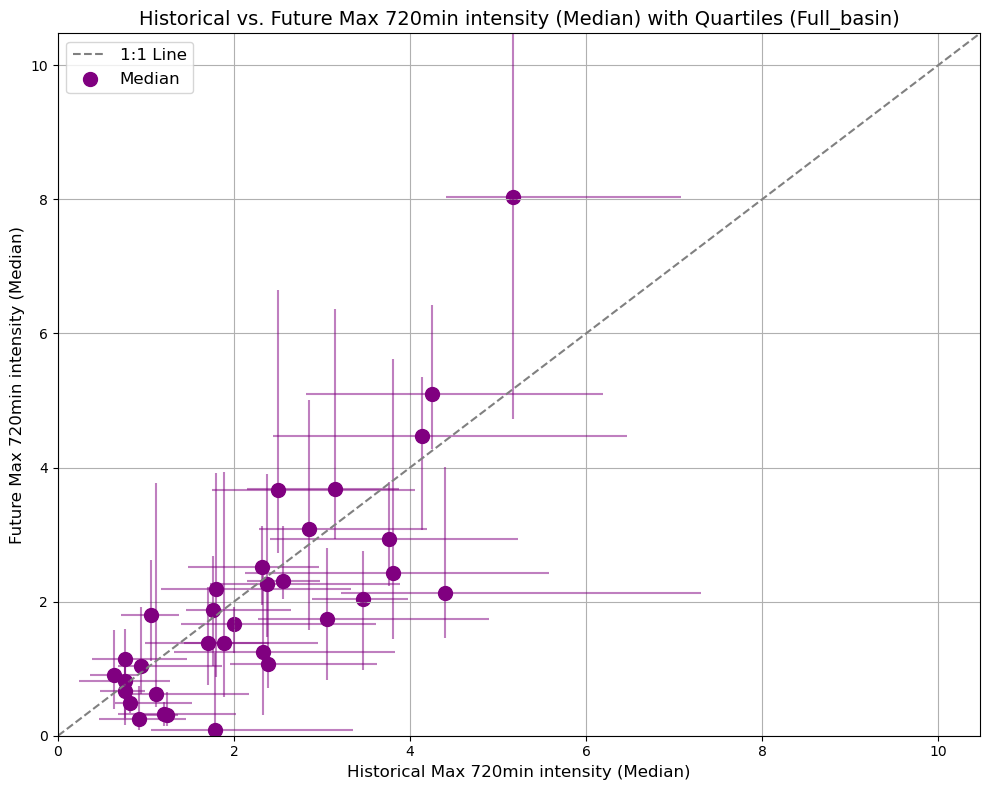

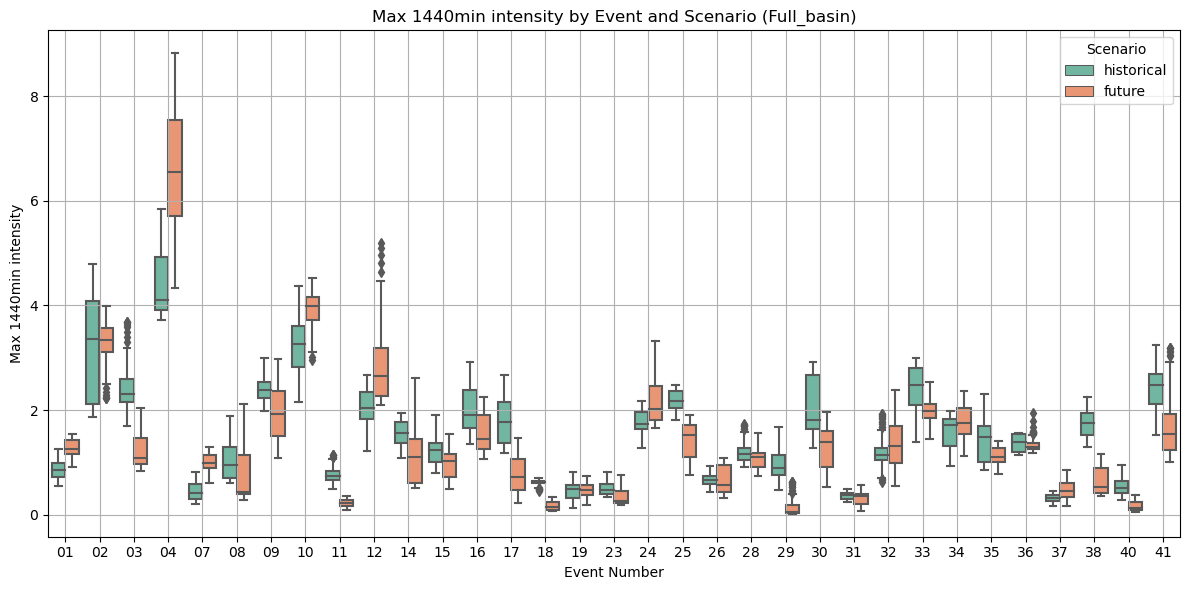

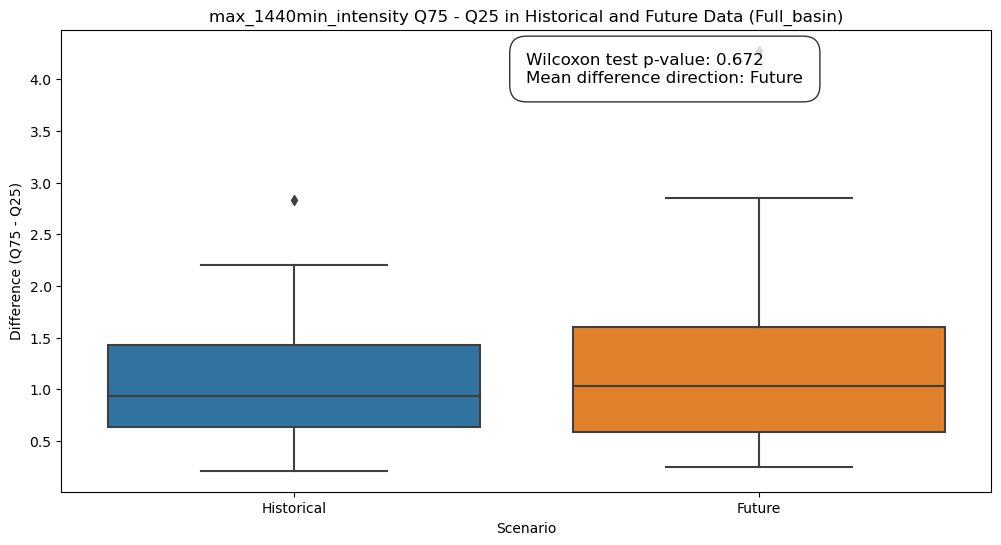

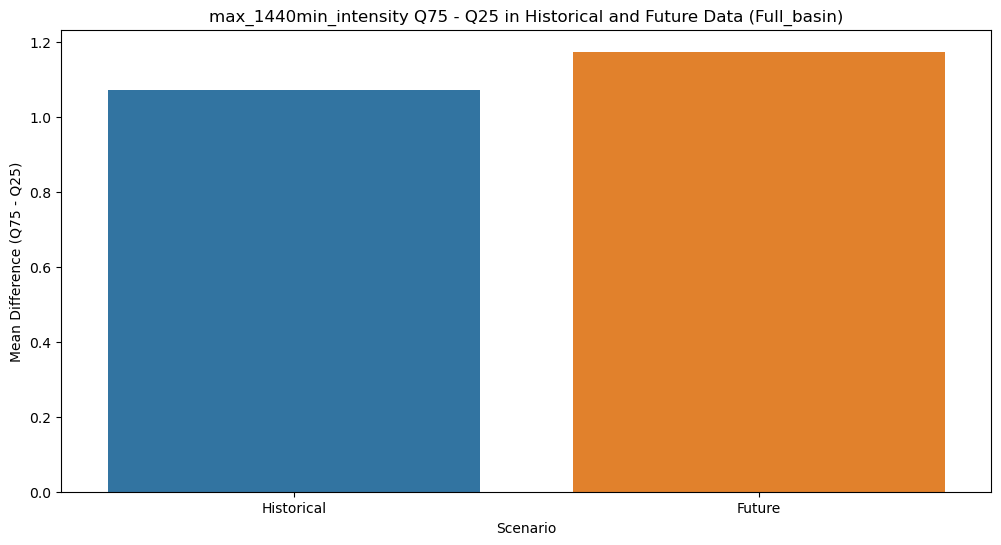

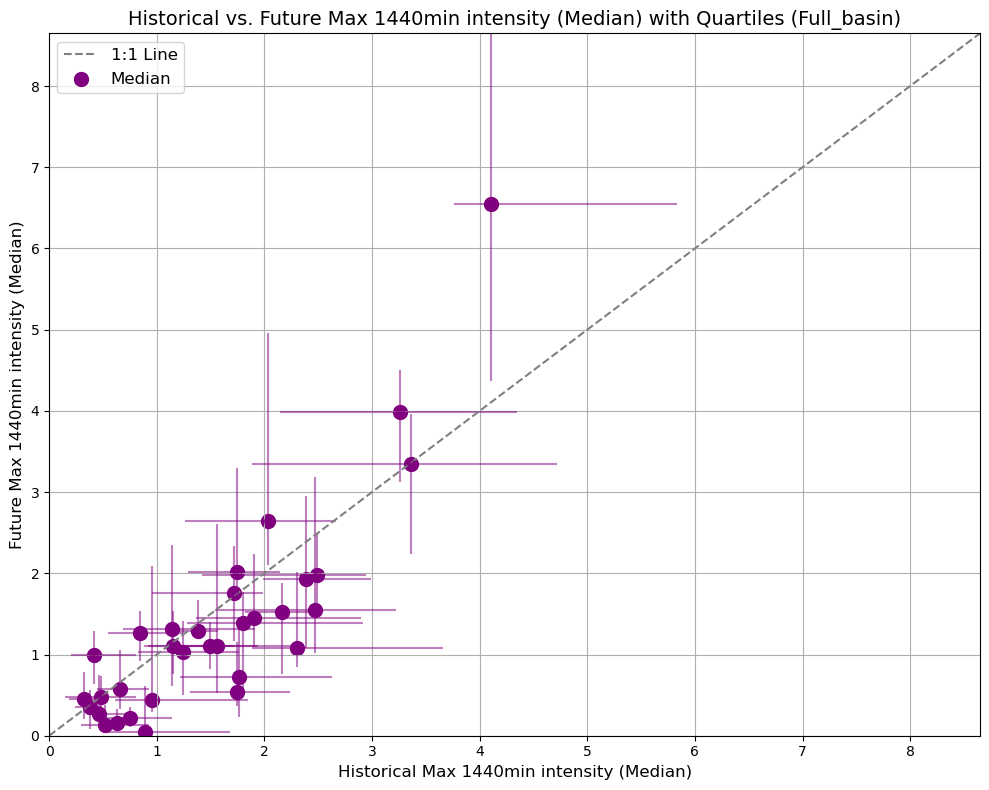

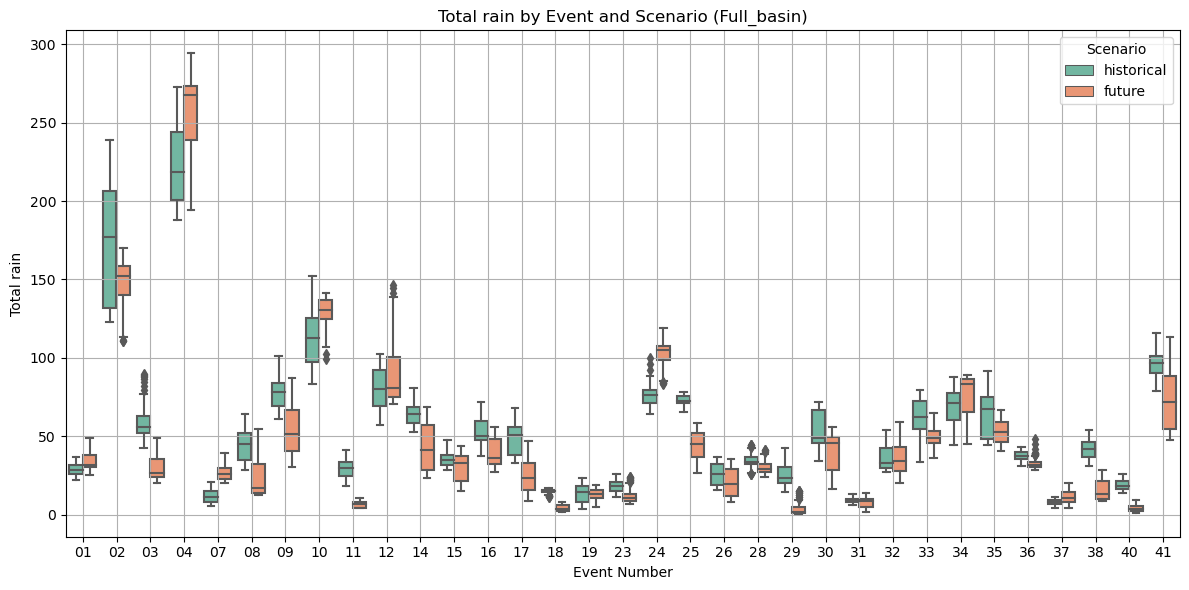

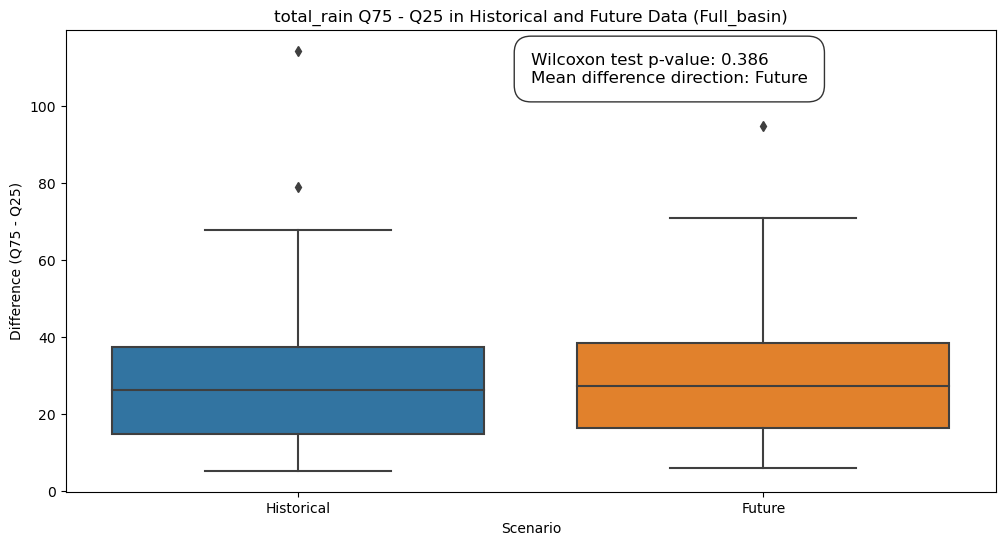

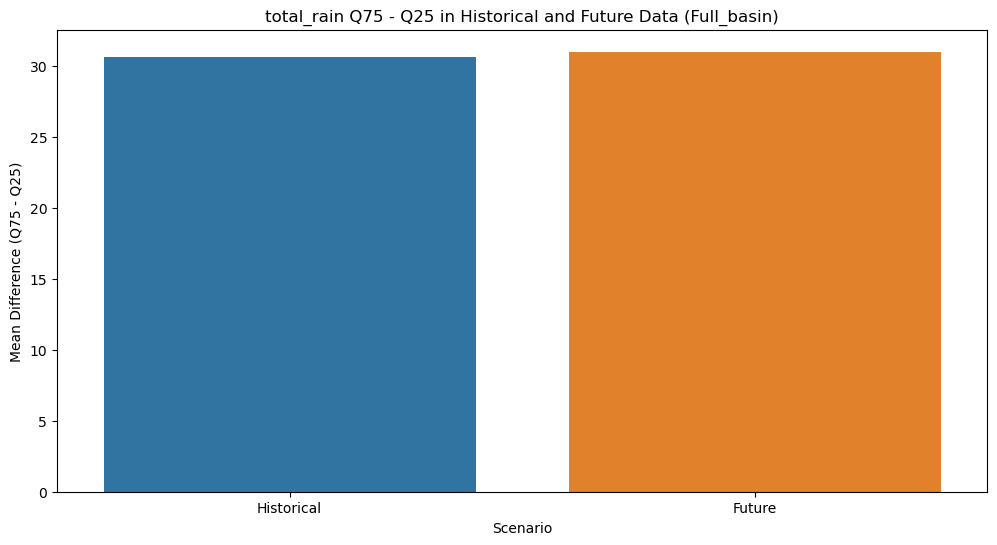

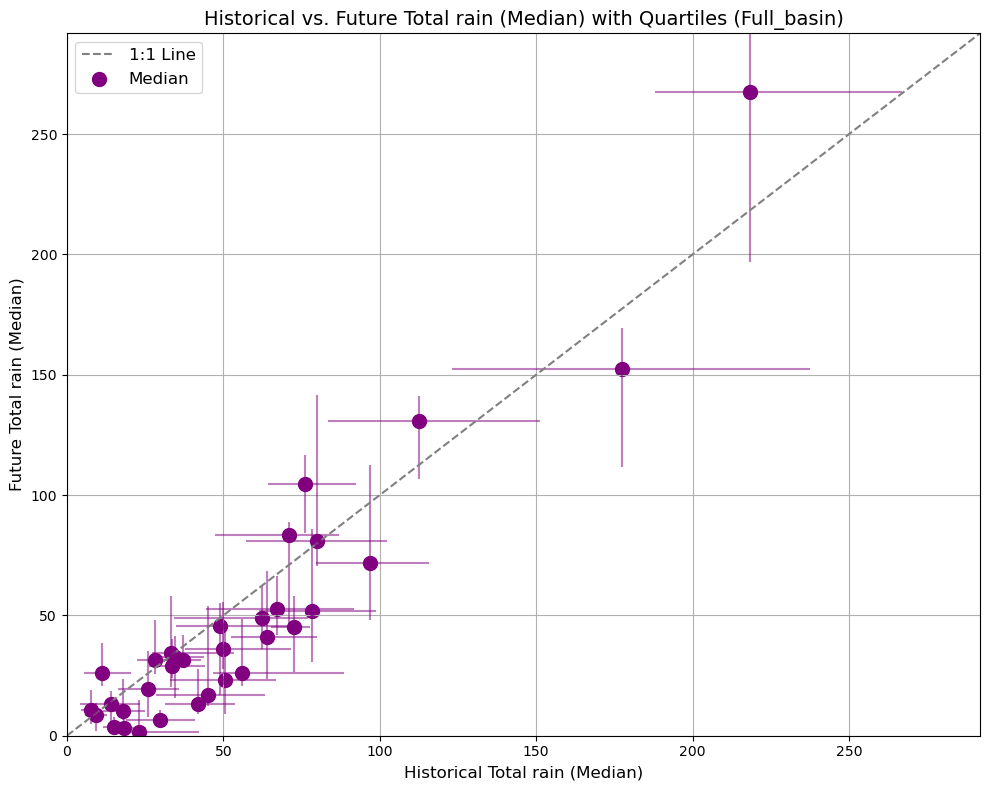

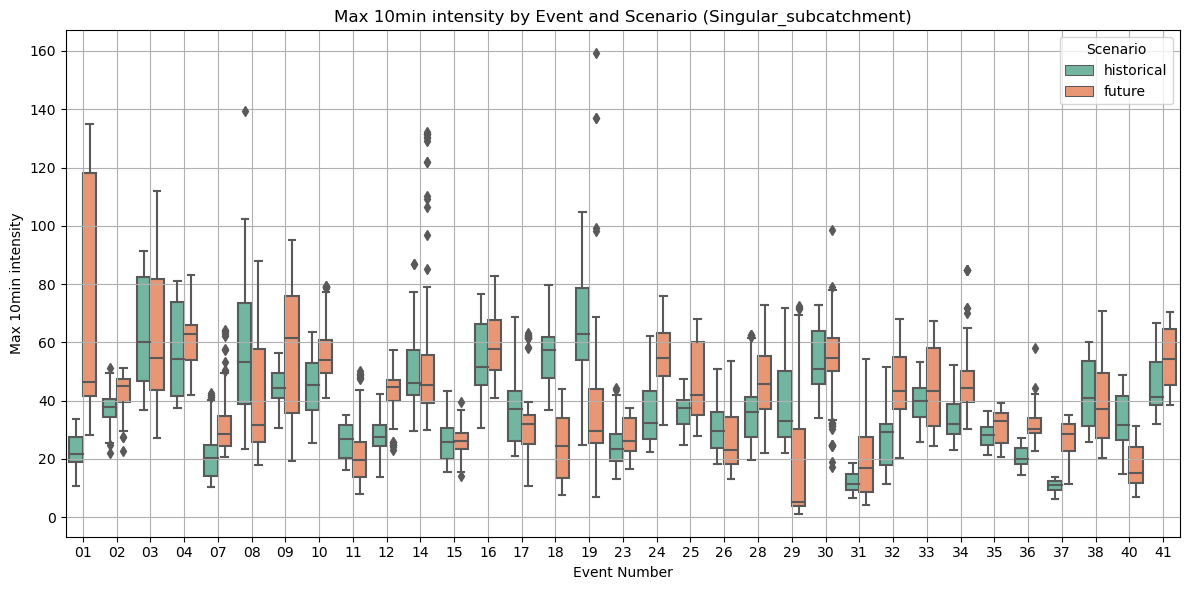

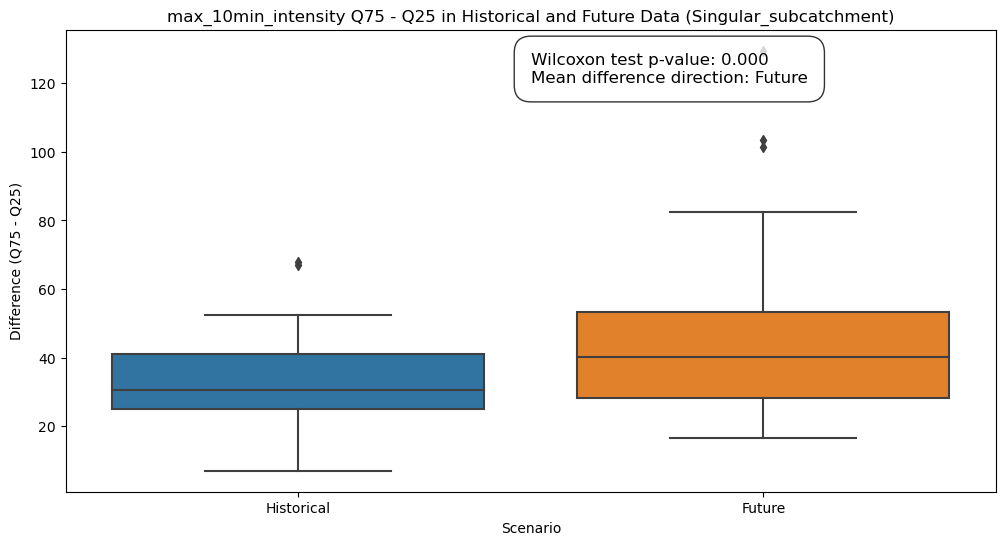

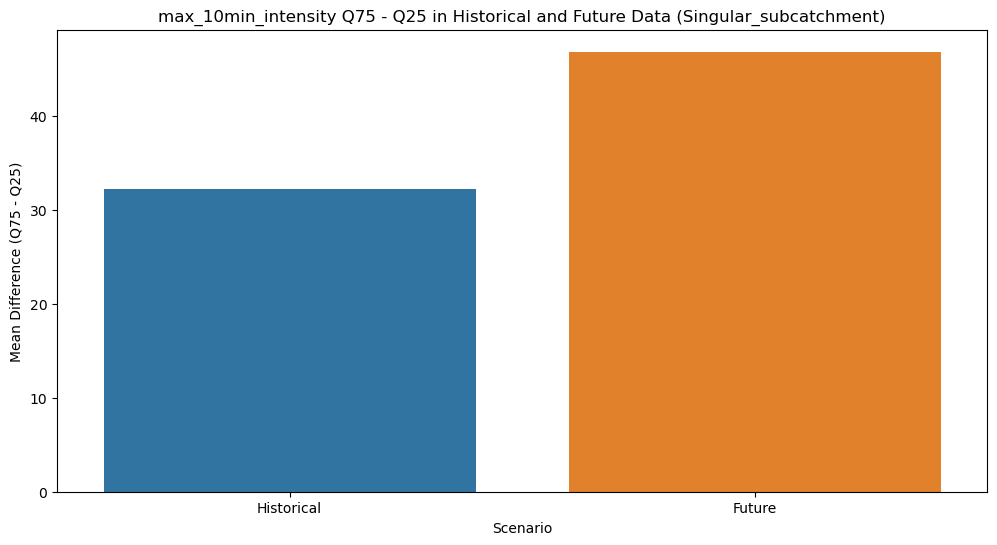

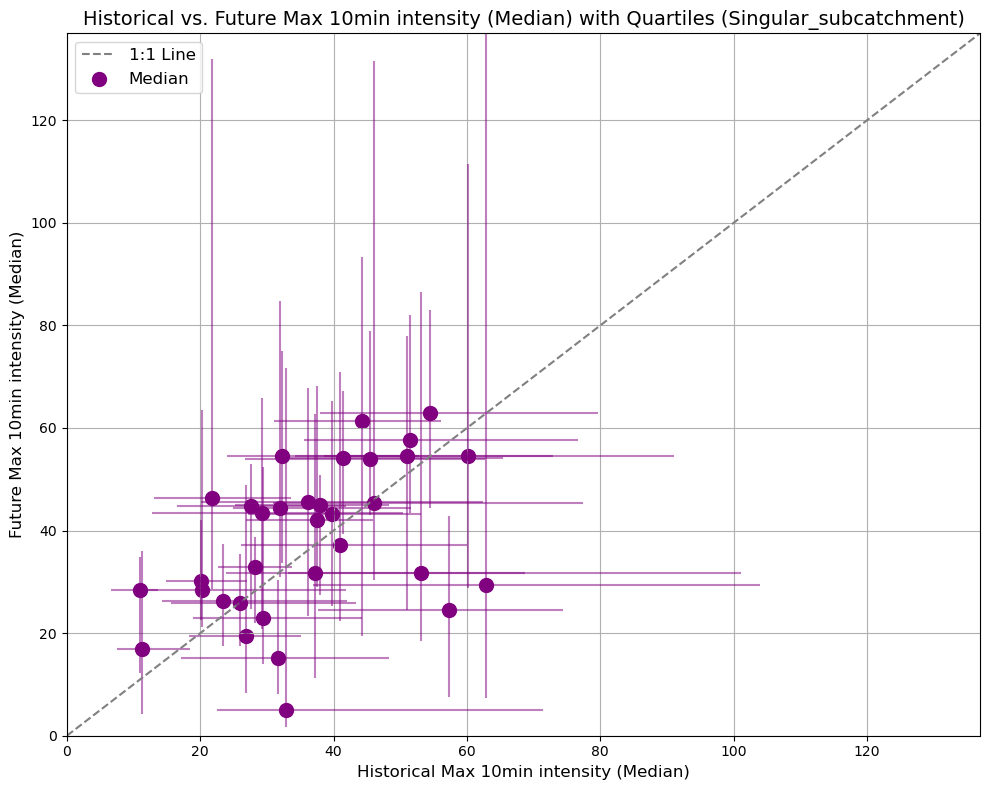

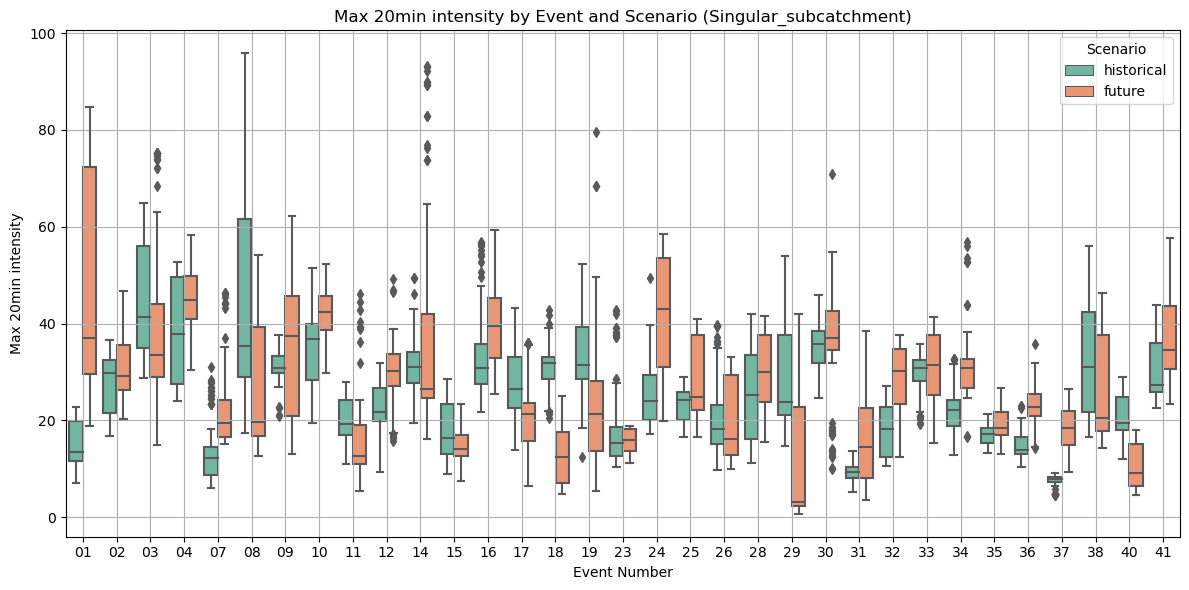

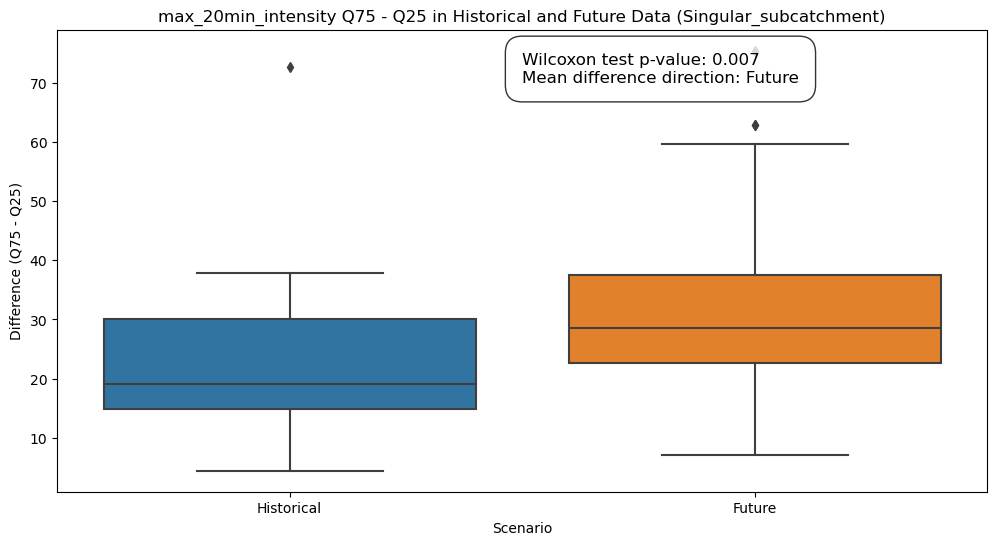

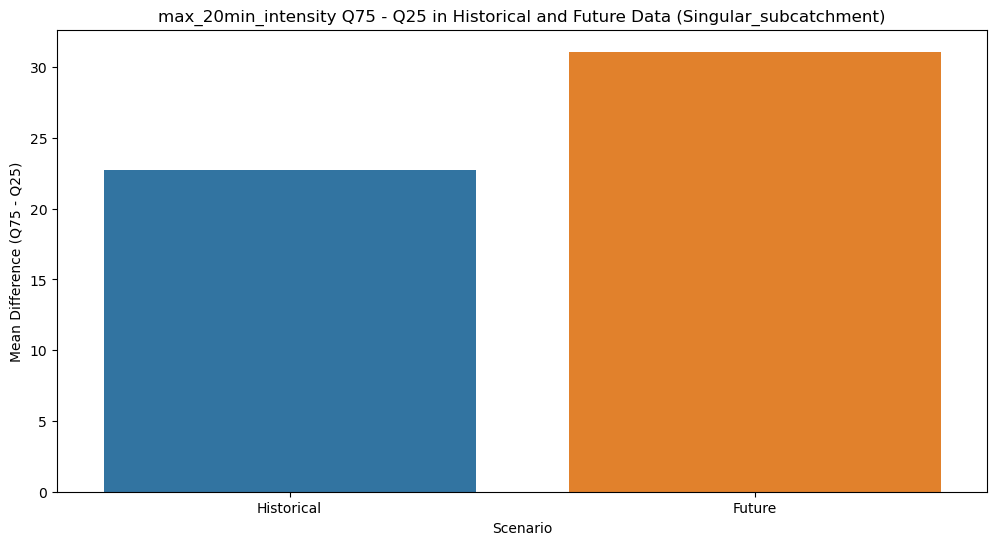

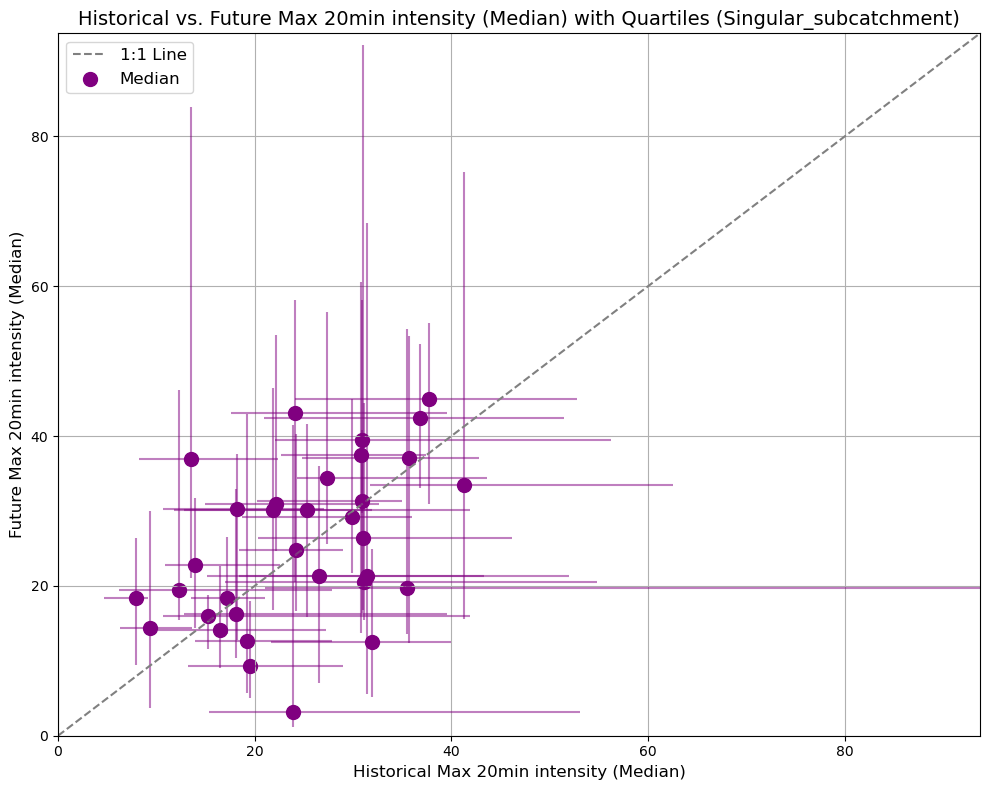

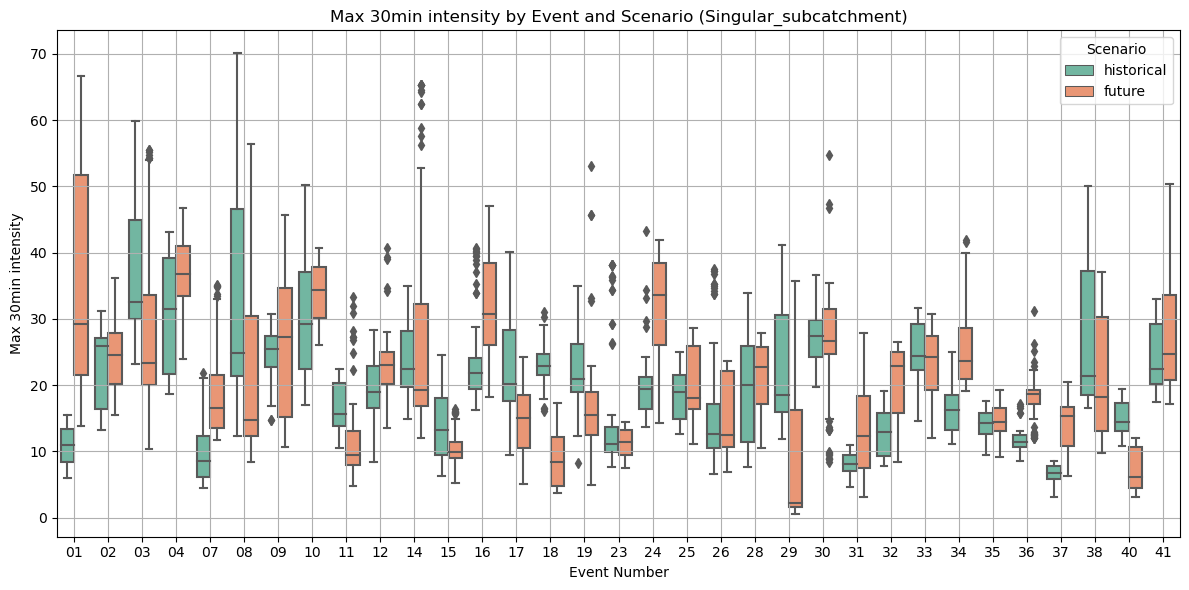

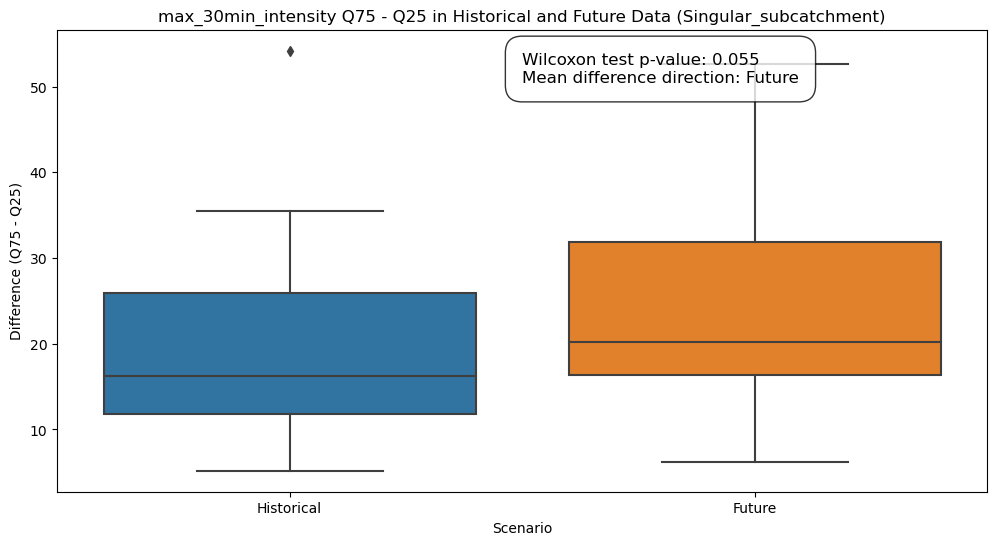

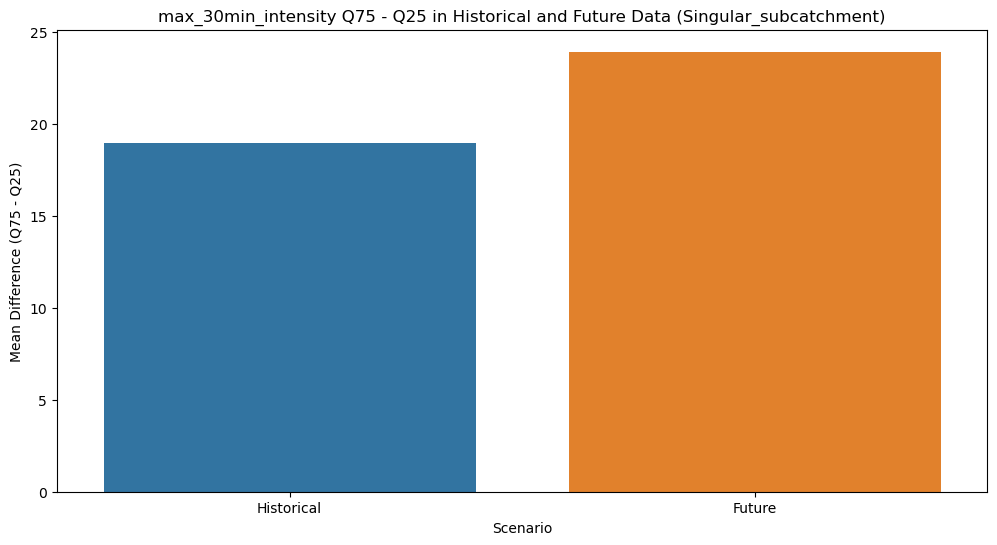

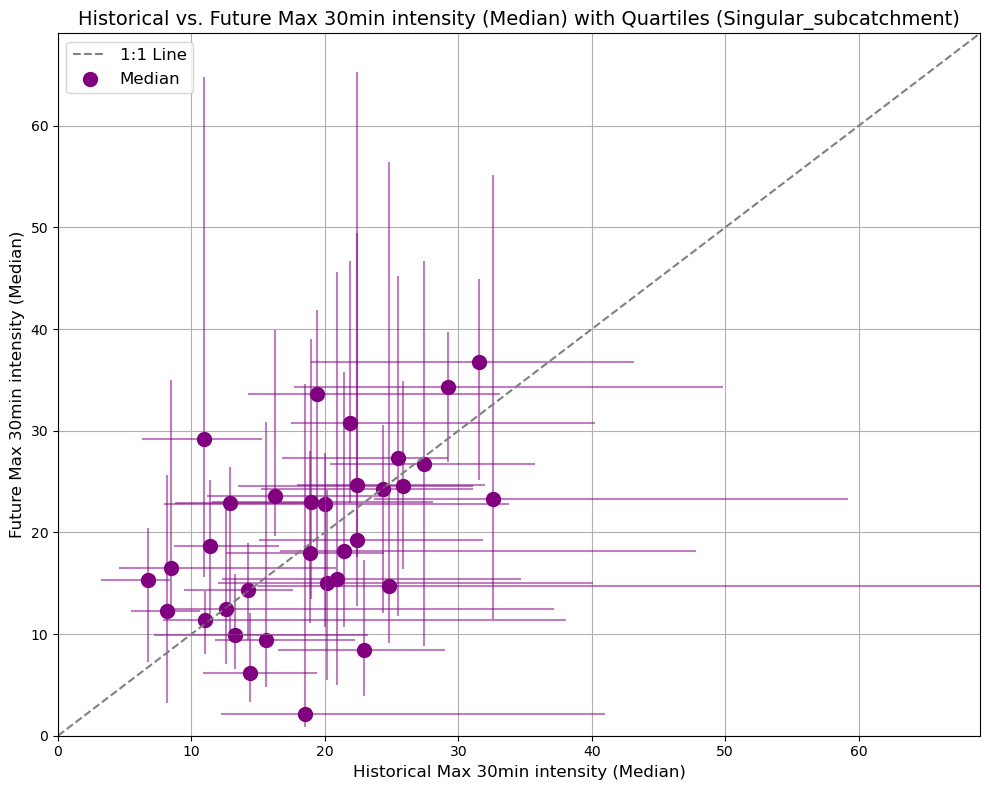

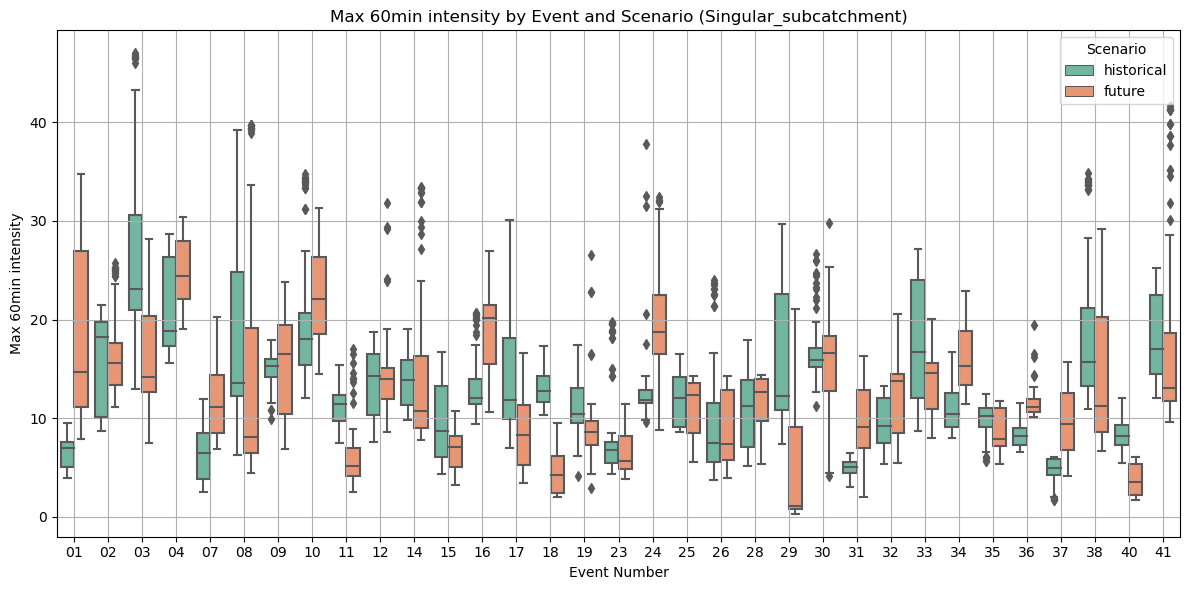

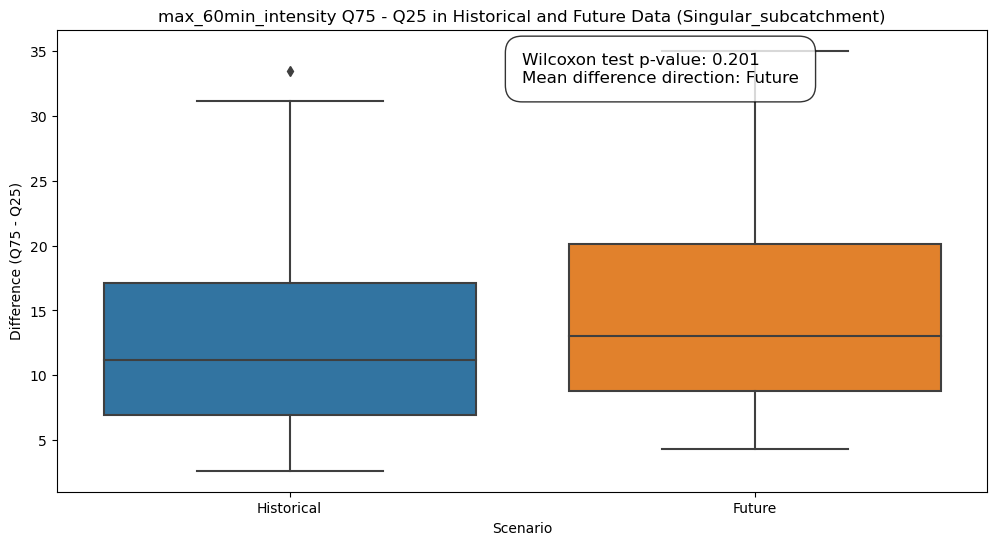

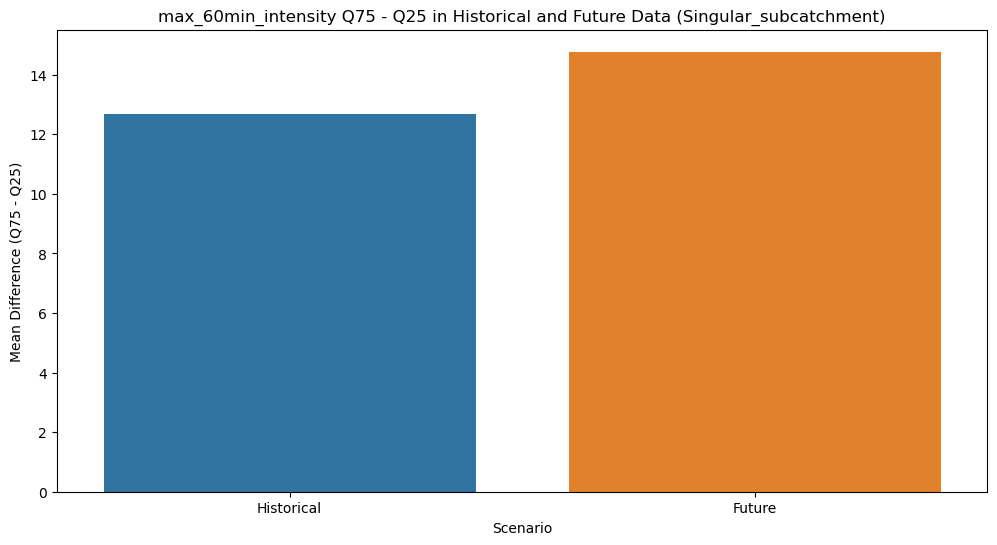

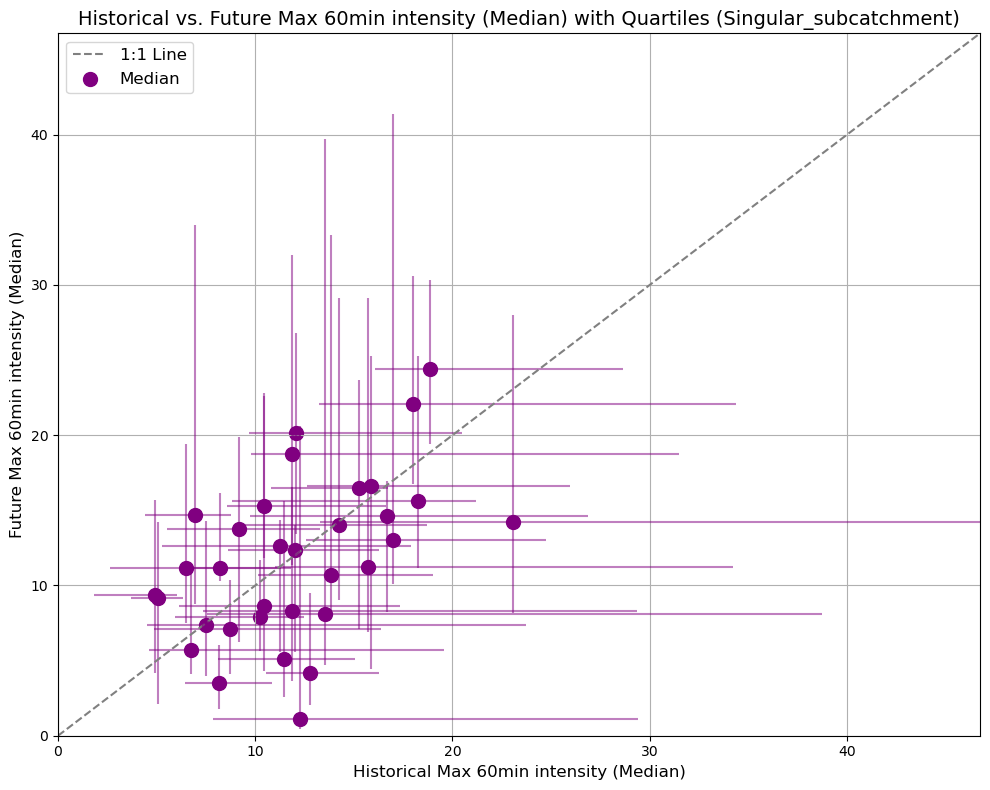

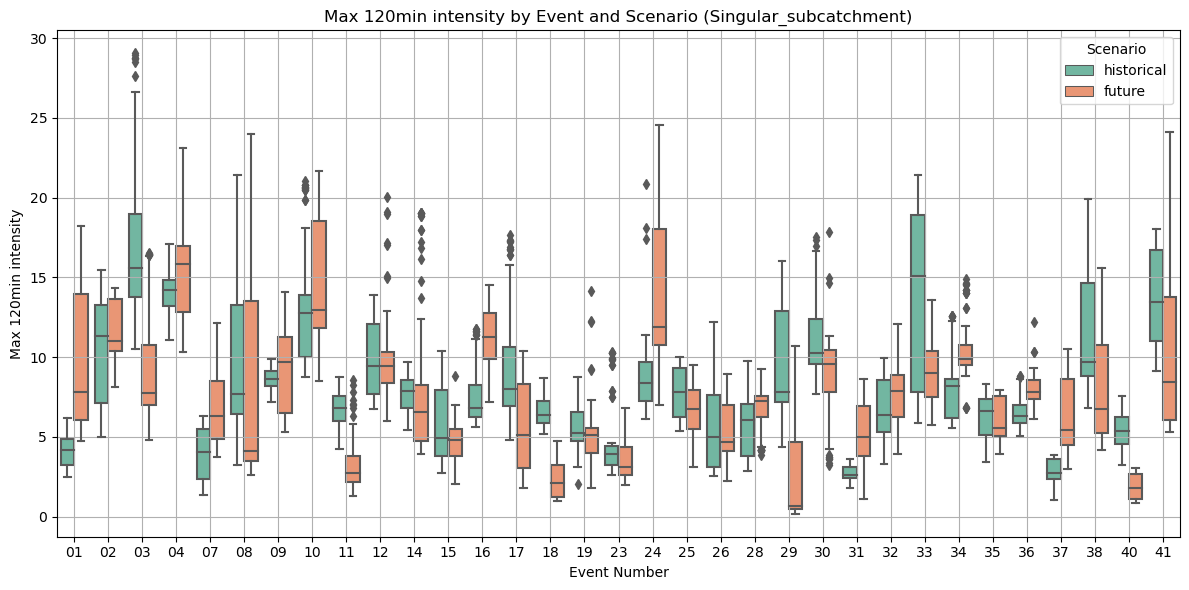

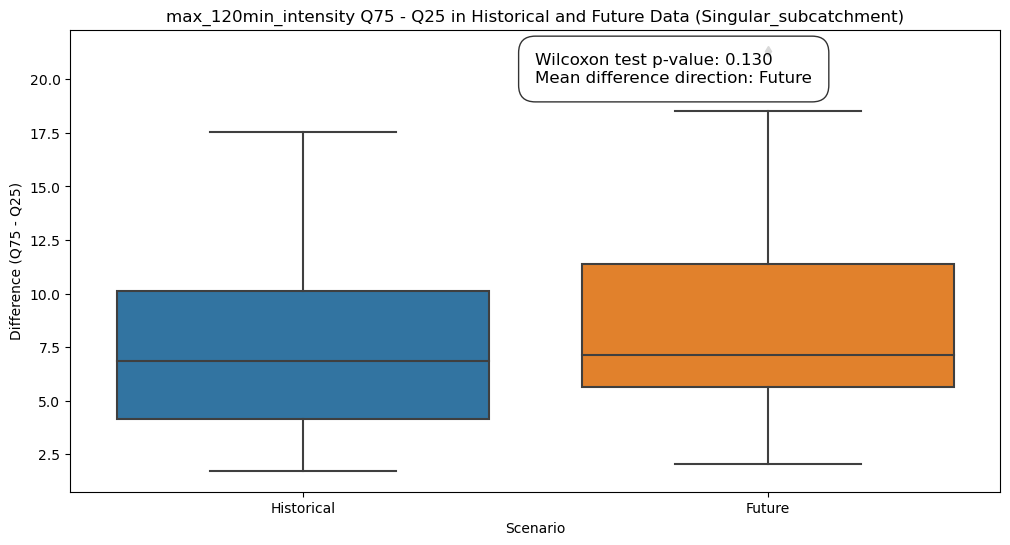

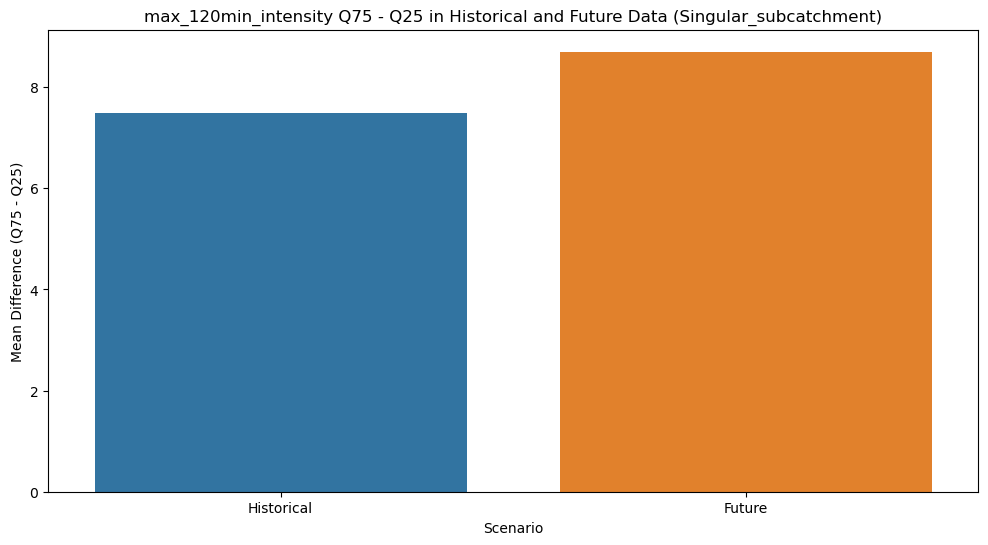

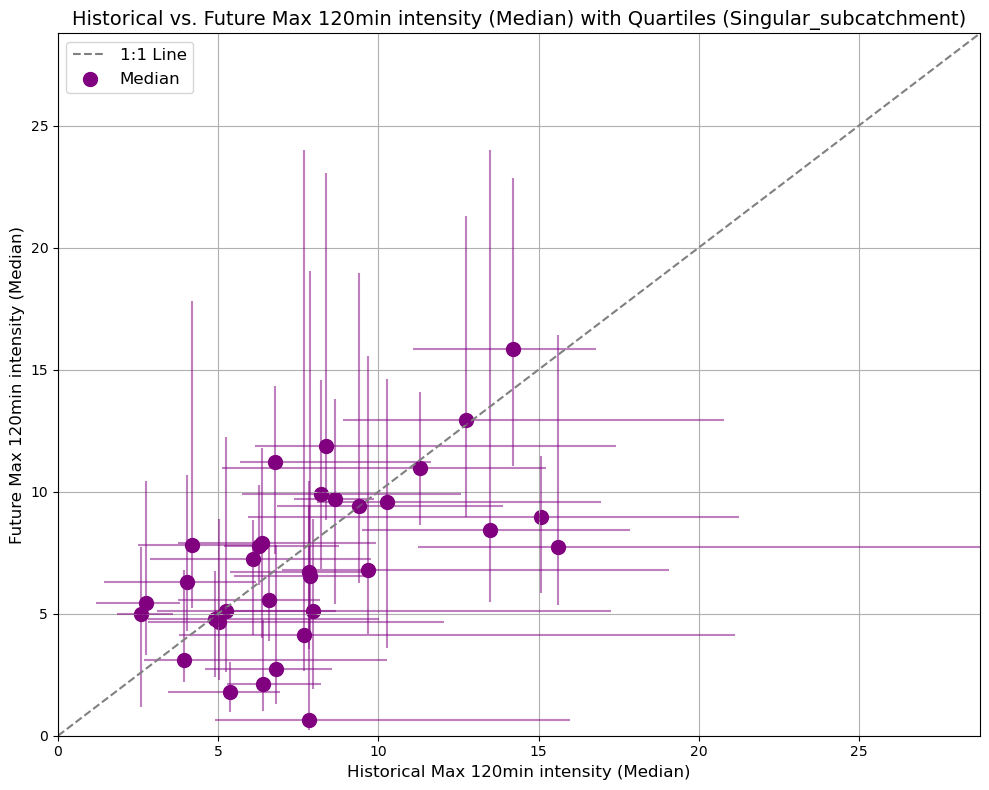

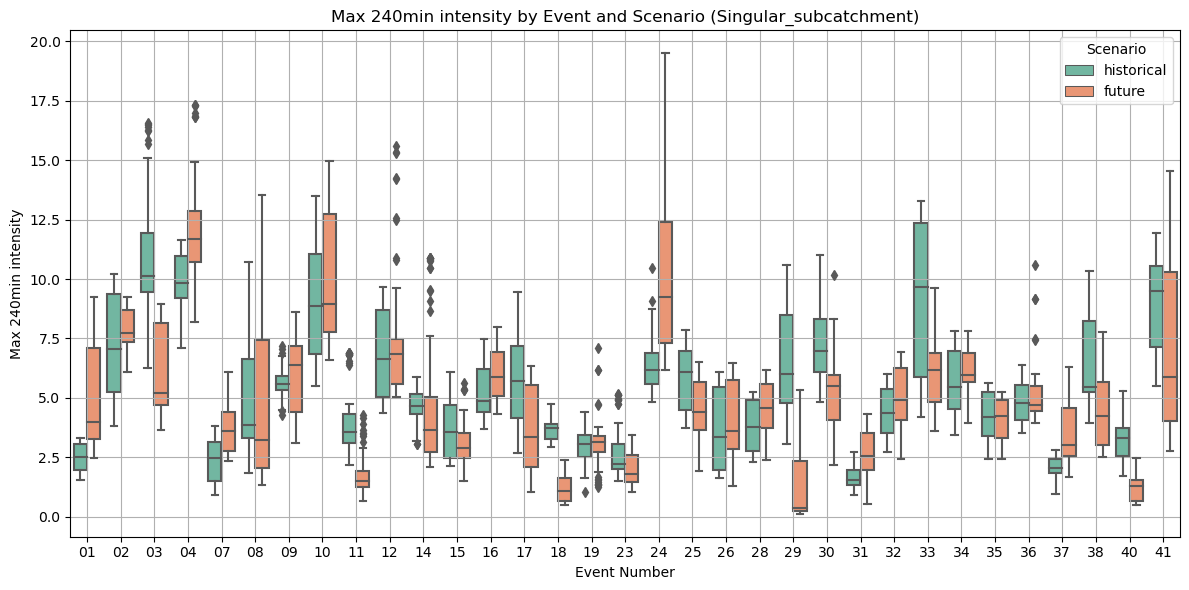

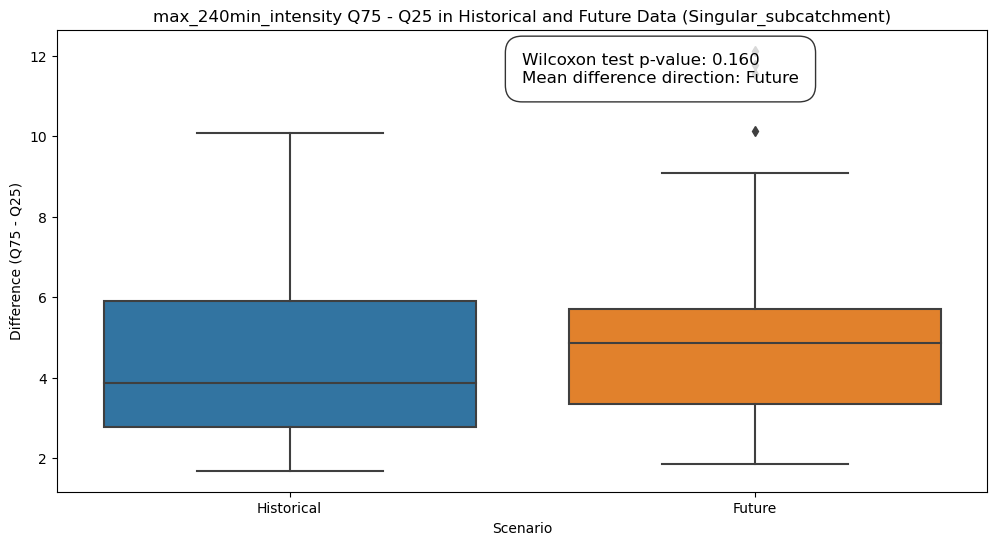

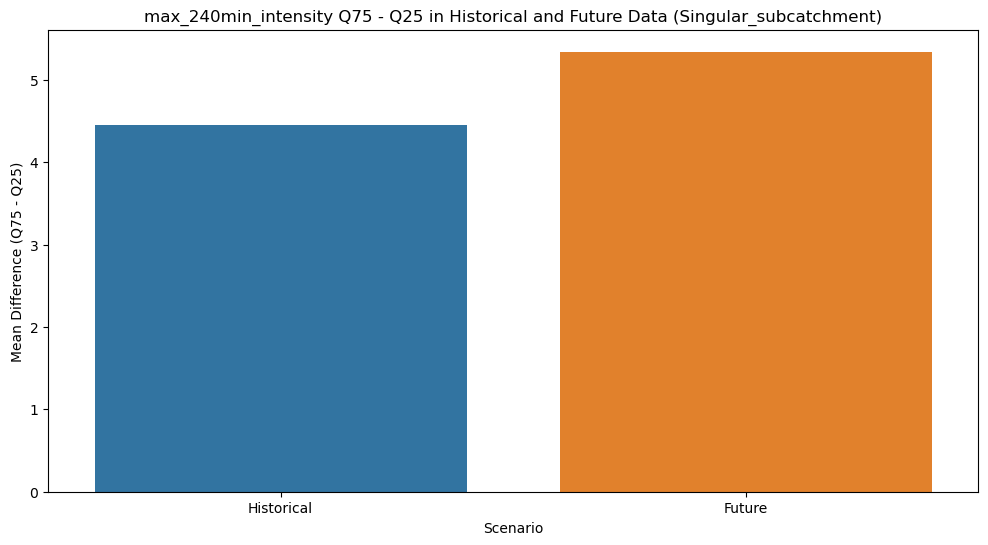

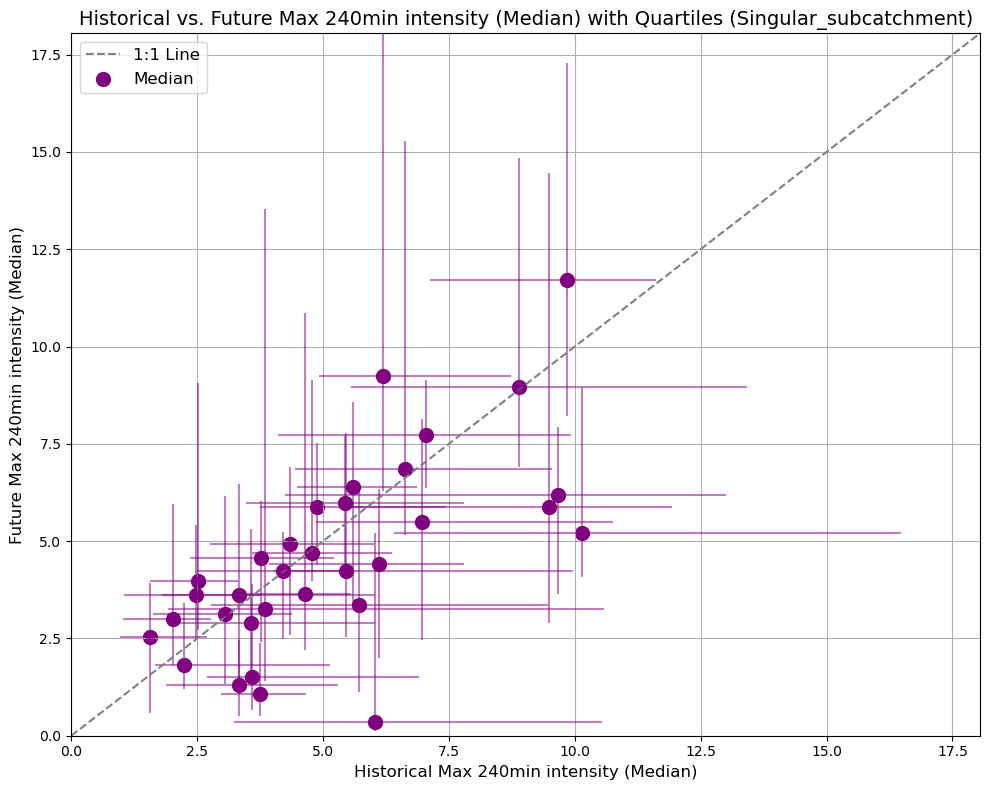

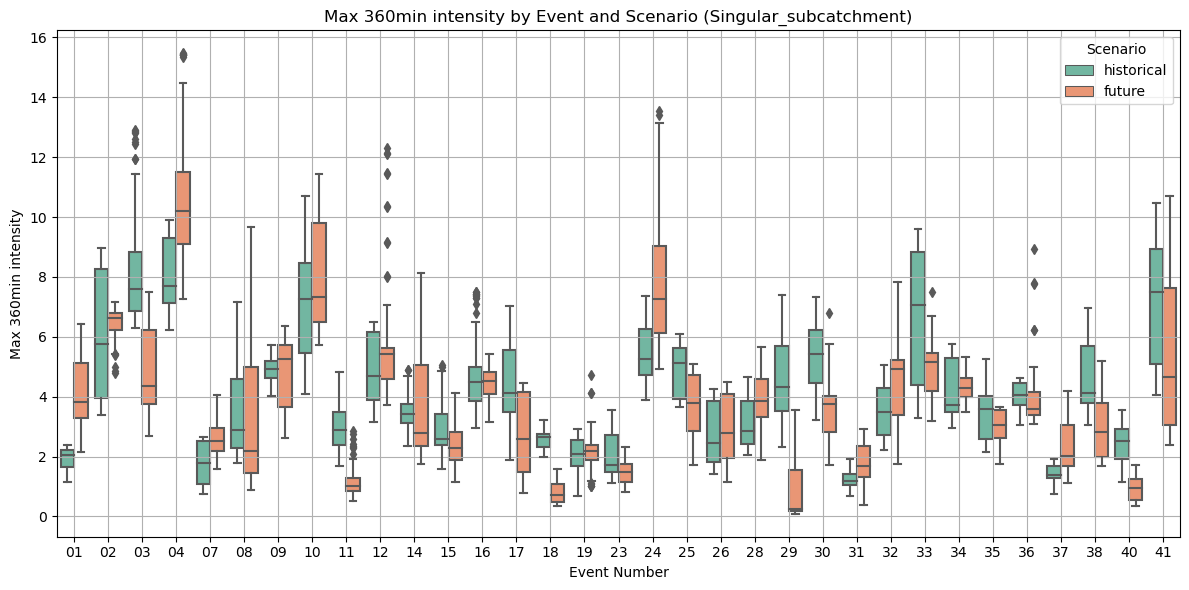

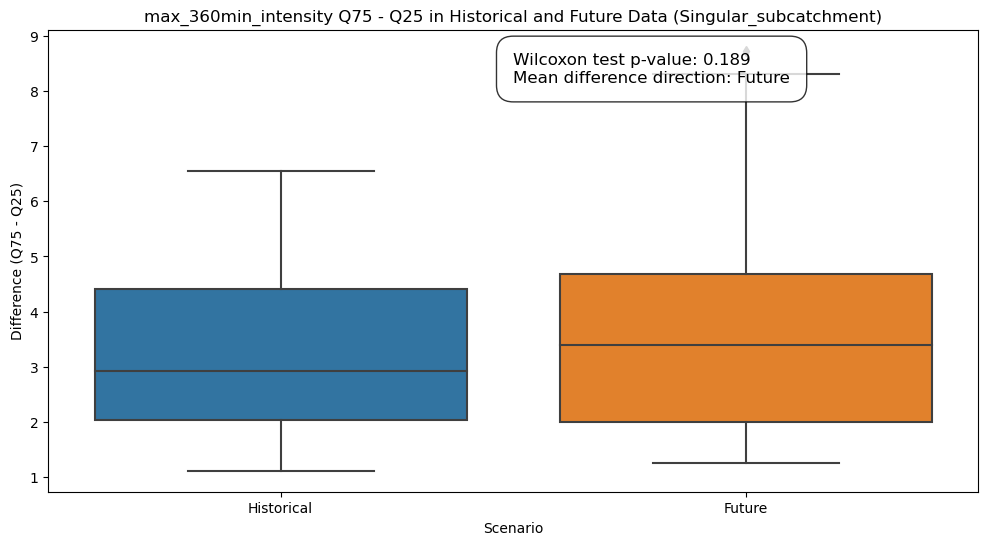

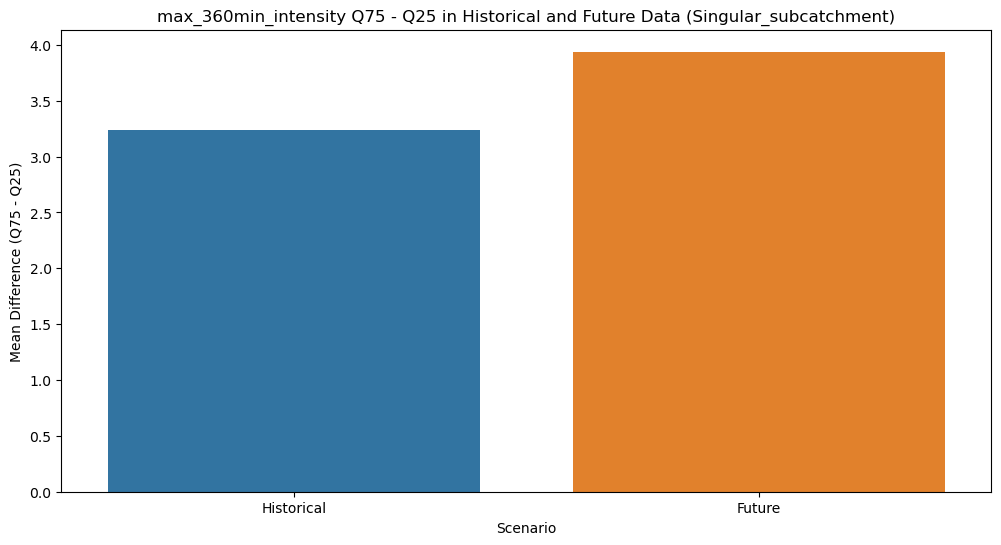

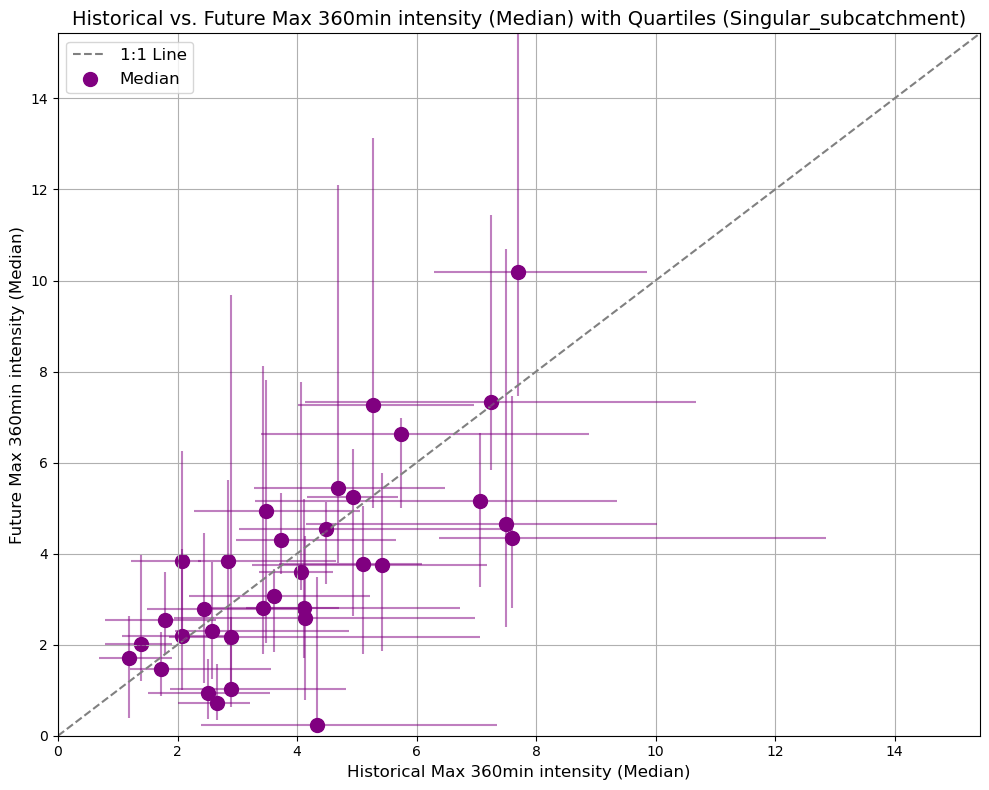

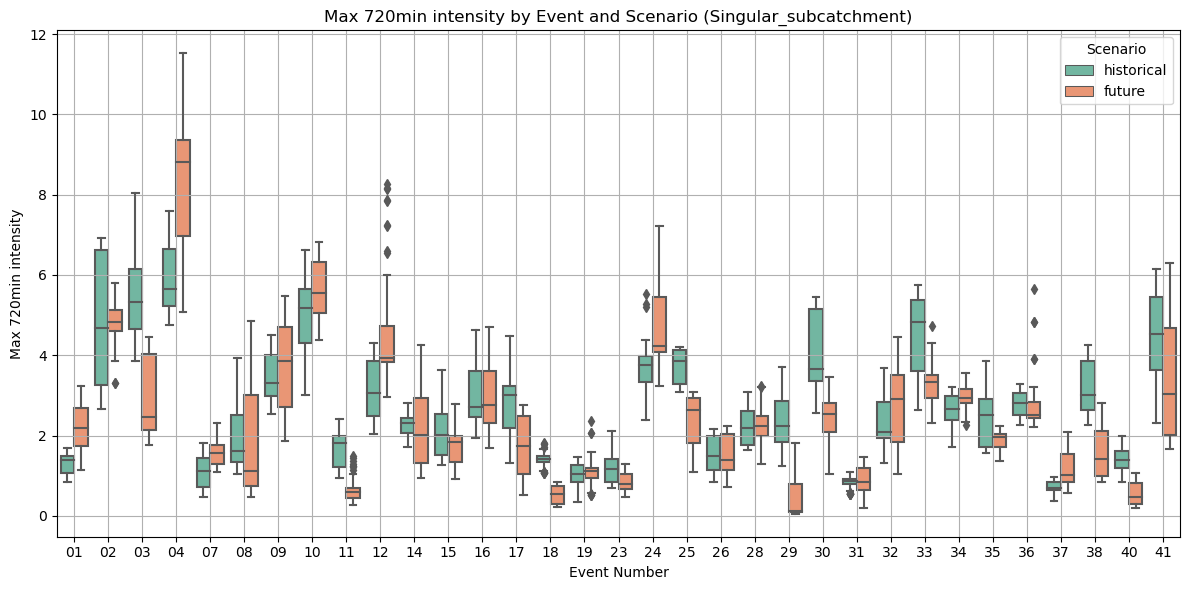

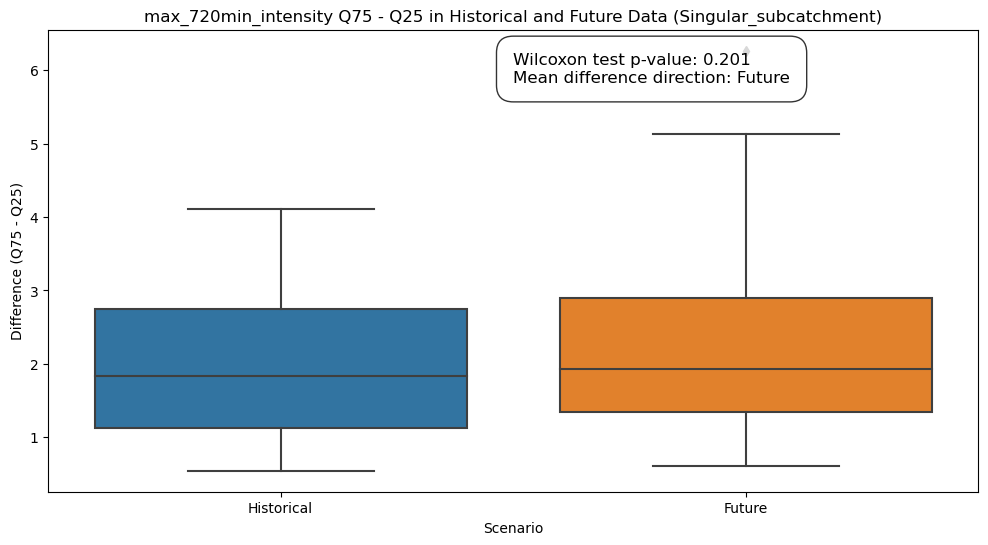

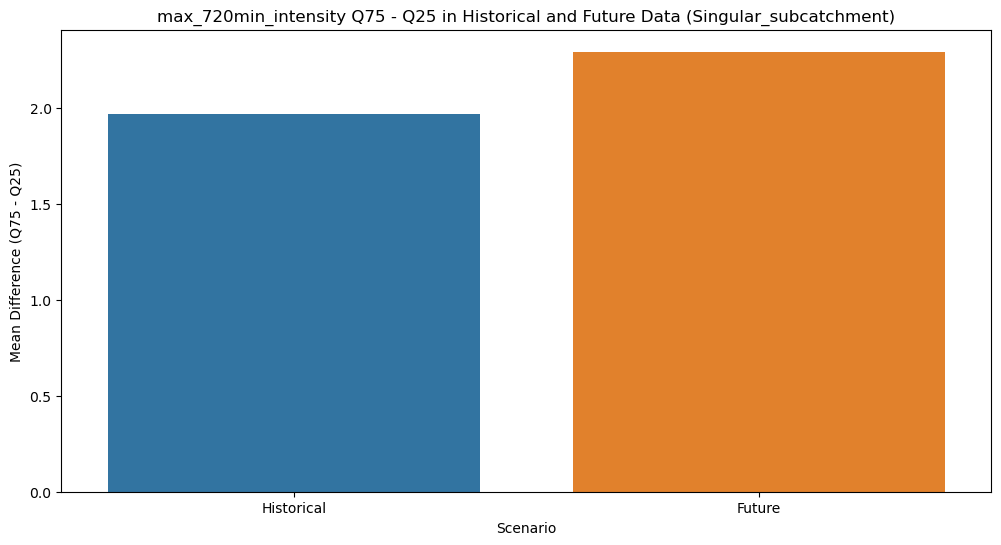

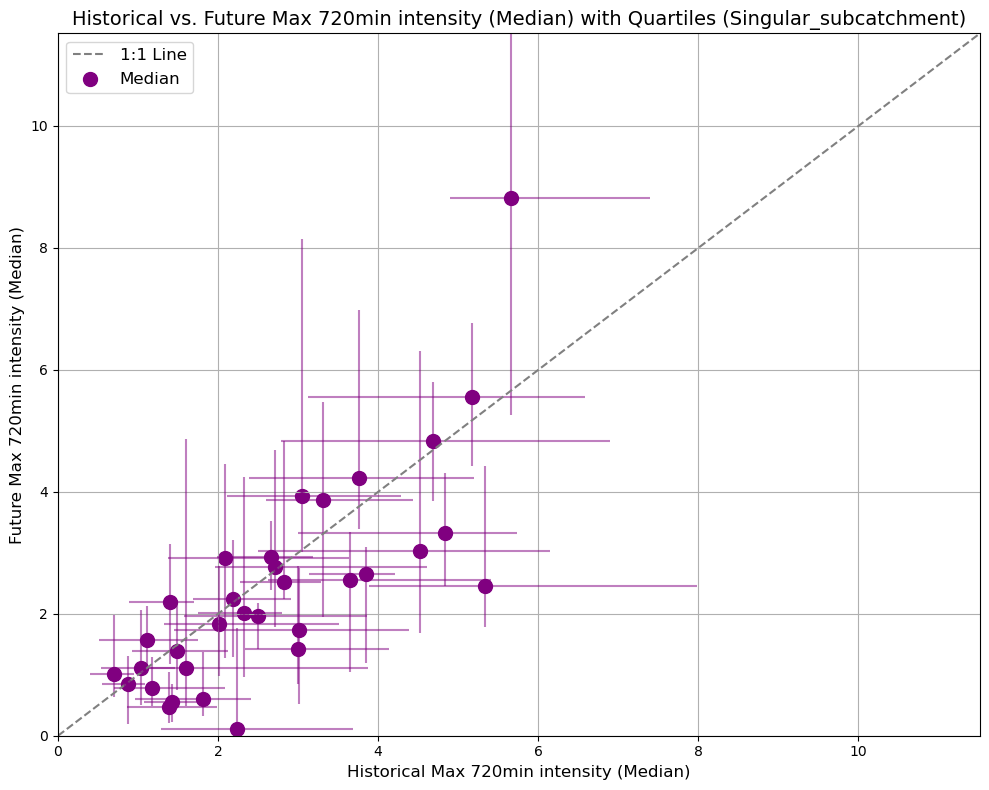

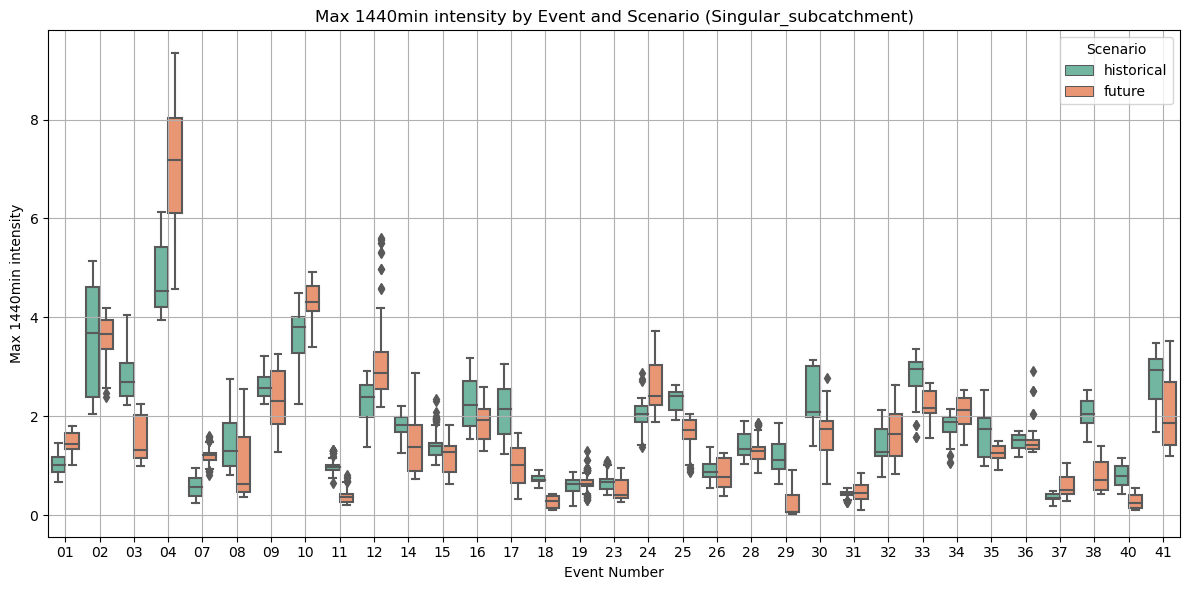

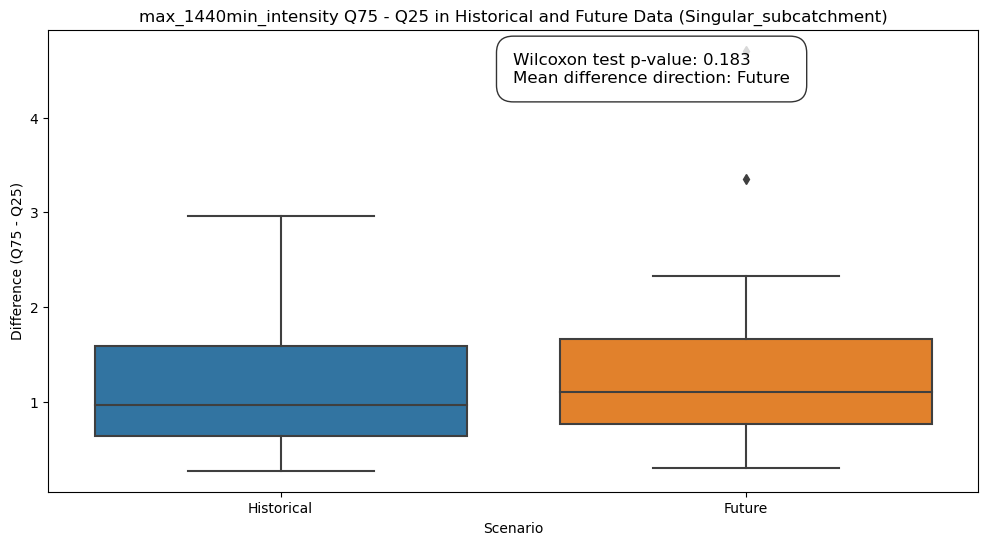

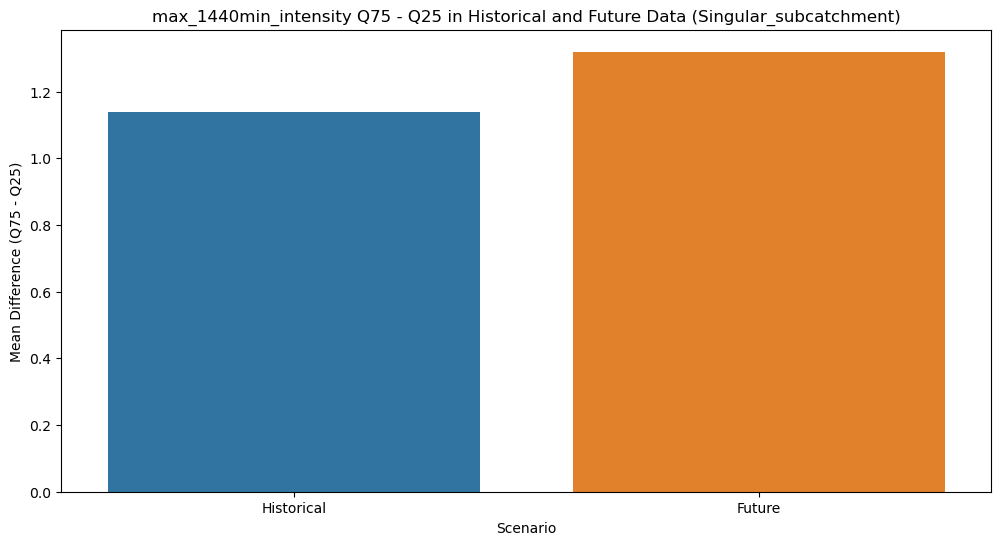

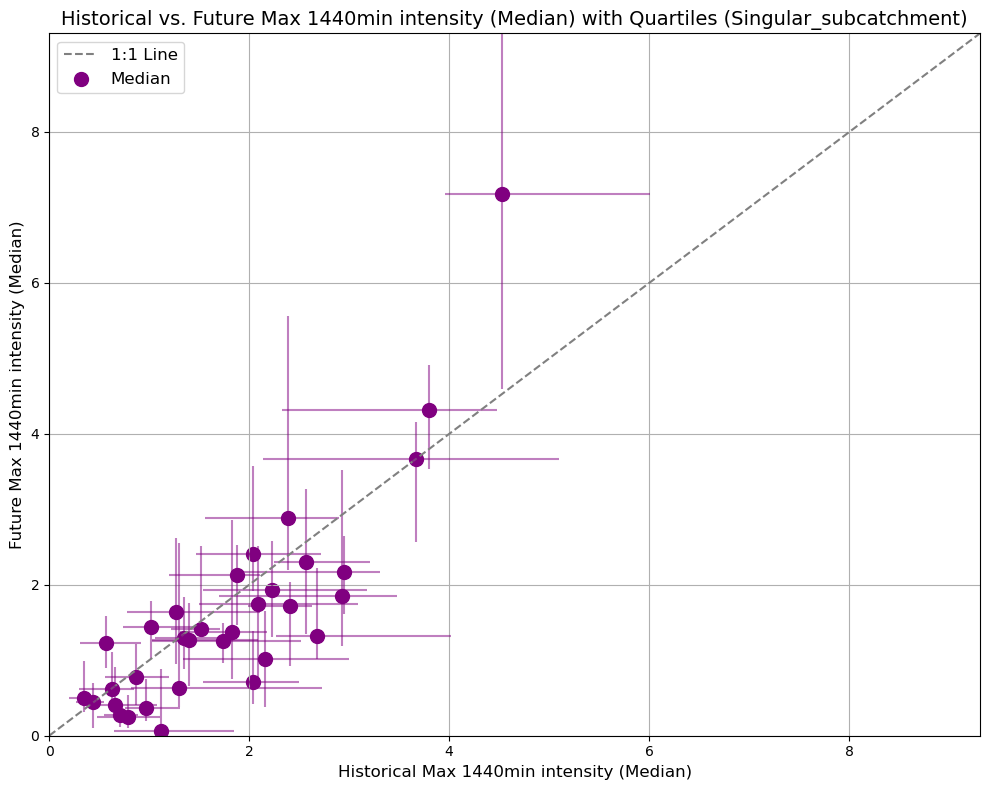

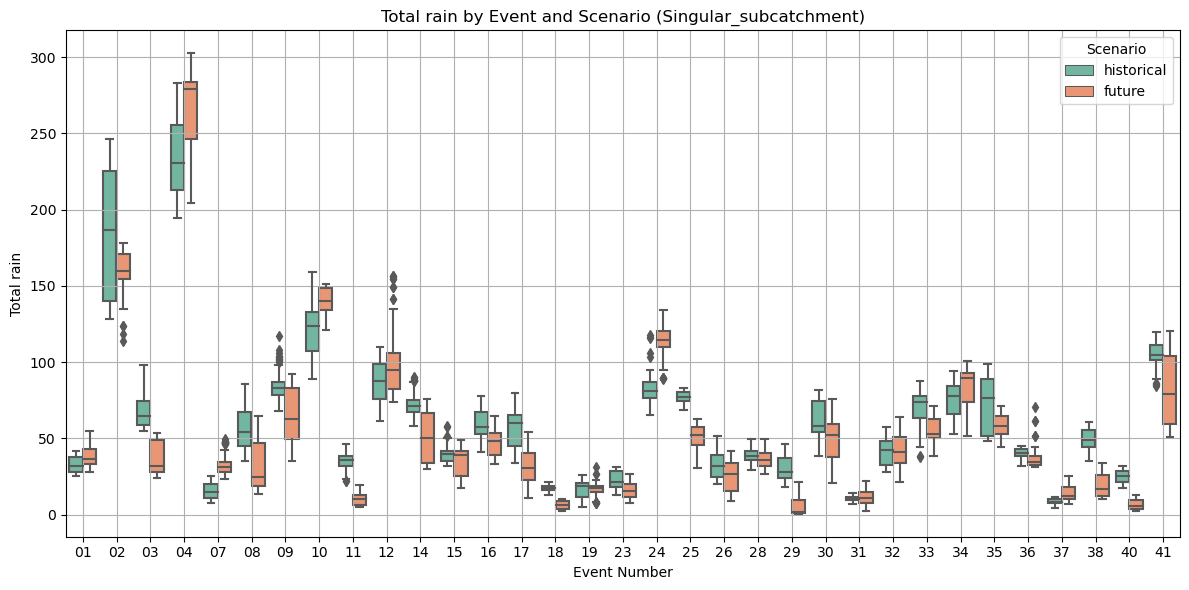

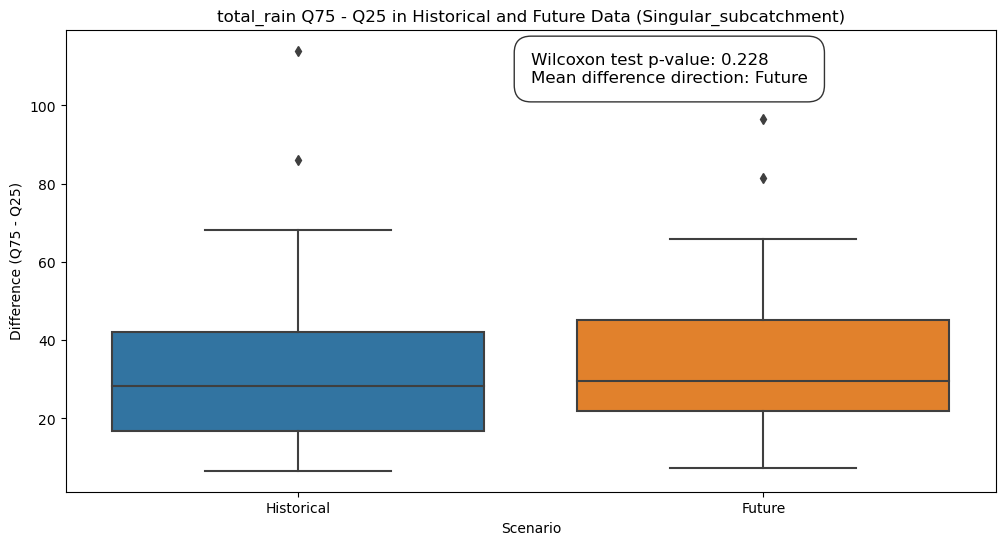

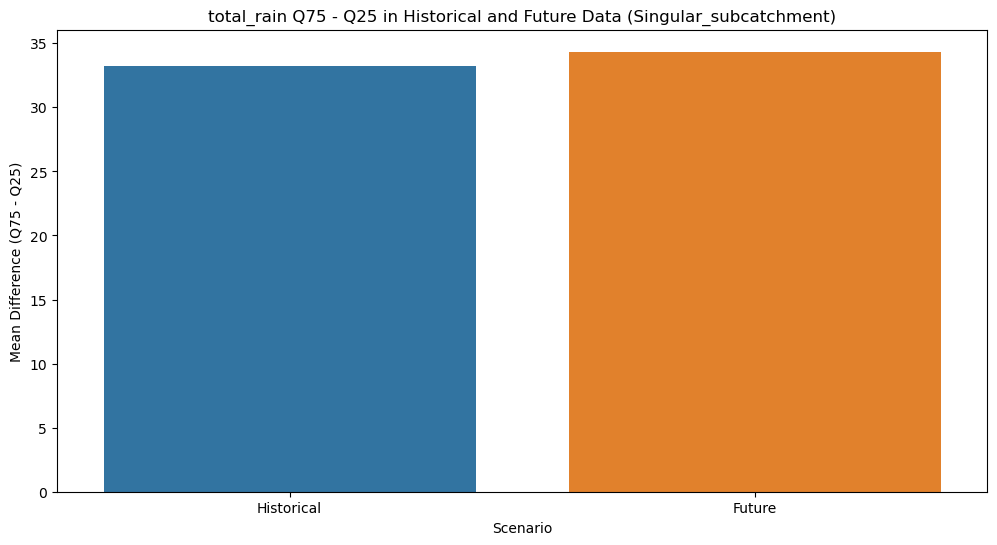

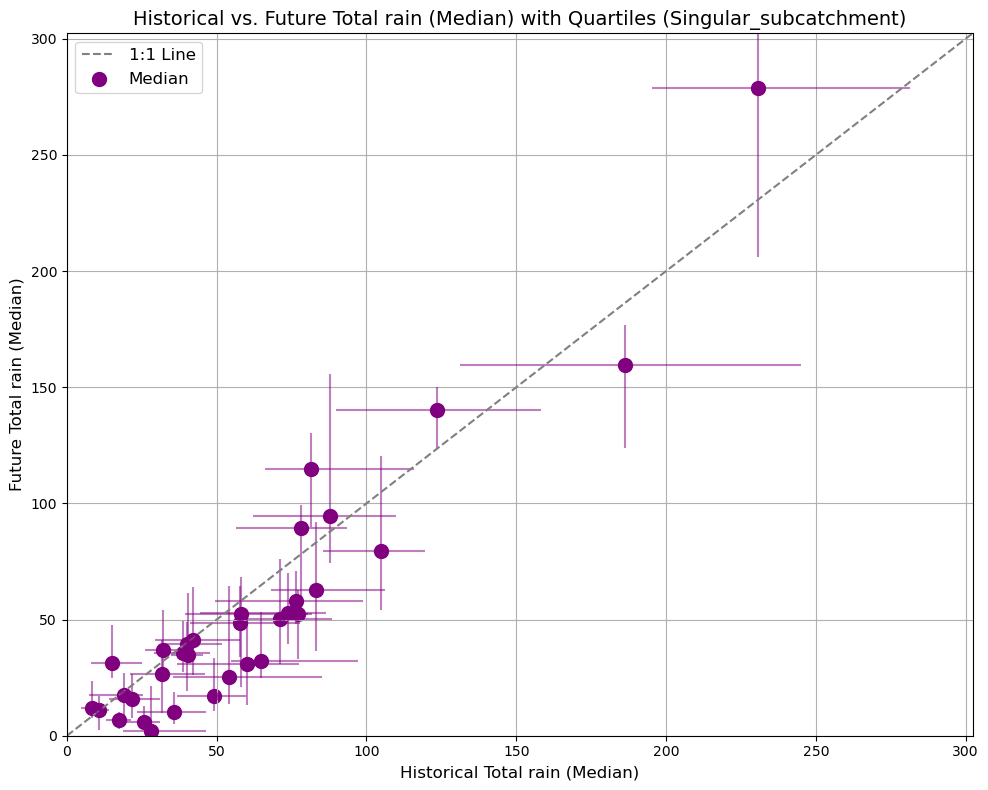

In [5]:
# Define the groups and common rain parameters
groups = ['full_basin',  'singular_subcatchment']
rain_parameters = [
    'max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
    'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
    'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 
    'total_rain'
]

# Loop through each group and parameter
for group in groups:
    group_save_dir = os.path.join(save_dir, group)
    os.makedirs(group_save_dir, exist_ok=True)
    for measure in rain_parameters:
        # Melt the DataFrame for the specific group and measure
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )

        # Flatten column names for seaborn compatibility
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']

        # Plot the boxplot using seaborn
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=melted_df, x='event_num', y='value', hue='scenario', palette='Set2')
        
        # Set labels and title
        plt.xlabel('Event Number')
        plt.ylabel(measure.capitalize().replace('_', ' '))
        plt.title(f'{measure.capitalize().replace("_", " ")} by Event and Scenario ({group.capitalize()})')
        plt.legend(title='Scenario')
        plt.grid(True)
        plt.tight_layout()

        # Save the boxplot
        boxplot_path = os.path.join(group_save_dir, f'boxplot_{measure}.png')
        plt.savefig(boxplot_path)
#         plt.close()

        # Compute the median, 25th, and 75th percentiles for each event and scenario
        percentiles_df = melted_df.groupby(['event_num', 'scenario'])['value'].agg(
            median='median',
            q25=lambda x: np.percentile(x, 2.5),
            q75=lambda x: np.percentile(x, 97.5)
        ).reset_index()

        # Pivot the DataFrame to get historical and future percentiles in separate columns
        pivot_df = percentiles_df.pivot(index='event_num', columns='scenario')
        pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]

        # Compute differences
        q_historical_diff = pivot_df['q75_historical'] - pivot_df['q25_historical']
        q_future_diff = pivot_df['q75_future'] - pivot_df['q25_future']

        # Perform Wilcoxon test
        stat, p_value = wilcoxon(q_historical_diff, q_future_diff)

        # Prepare data for visualization
        diff_df = pd.DataFrame({
            'Historical': q_historical_diff,
            'Future': q_future_diff
        })

        # Calculate mean differences
        mean_diff = diff_df.mean()

        # Boxplot for differences
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=diff_df)
        plt.title(f'{measure} Q75 - Q25 in Historical and Future Data ({group.capitalize()})')
        plt.ylabel('Difference (Q75 - Q25)')
        plt.xlabel('Scenario')
        # Add text box with p-value and direction
        plt.text(0.5, 0.95, f'Wilcoxon test p-value: {p_value:.3f}\n'
                            f'Mean difference direction: {"Historical" if mean_diff["Historical"] > mean_diff["Future"] else "Future"}',
                 transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))
        plt.savefig(f'{group_save_dir}/boxplot_diff_Q75_Q25_{measure}.png')
#         plt.close()

        # Bar plot of mean differences
        plt.figure(figsize=(12, 6))
        sns.barplot(x=mean_diff.index, y=mean_diff.values)
        plt.title(f'{measure} Q75 - Q25 in Historical and Future Data ({group.capitalize()})')
        plt.ylabel('Mean Difference (Q75 - Q25)')
        plt.xlabel('Scenario')
        plt.savefig(f'{group_save_dir}/barplot_mean_diff_Q75_Q25_{measure}.png')
#         plt.close()

        # Plot historical median vs future median
        plt.figure(figsize=(10, 8))
        plt.scatter(pivot_df['median_historical'], pivot_df['median_future'], color='purple', label='Median', s=100)

        # Add error bars for the 25th and 75th percentiles
        for _, row in pivot_df.iterrows():
            plt.errorbar(row['median_historical'], row['median_future'],
                         xerr=[[row['median_historical'] - row['q25_historical']],
                               [row['q75_historical'] - row['median_historical']]],
                         yerr=[[row['median_future'] - row['q25_future']],
                               [row['q75_future'] - row['median_future']]],
                         fmt='o', color='purple', alpha=0.5)

        # Add a diagonal line for reference
        max_75_value = pivot_df[['q75_historical', 'q75_future']].values.max()
        plt.plot([0, max_75_value * 1.075], [0, max_75_value * 1.075], linestyle='--', color='grey', label='1:1 Line')

        plt.xlim(0, max_75_value)
        plt.ylim(0, max_75_value)

        # Set labels and title
        plt.xlabel(f'Historical {measure.capitalize().replace("_", " ")} (Median)', fontsize=12)
        plt.ylabel(f'Future {measure.capitalize().replace("_", " ")} (Median)', fontsize=12)
        plt.title(f'Historical vs. Future {measure.capitalize().replace("_", " ")} (Median) with Quartiles ({group.capitalize()})', fontsize=14)
        plt.grid(True)

        # Add legend
        plt.legend(loc='upper left', fontsize=12)

        # Adjust layout
        plt.tight_layout()

        # Save the scatter plot
        scatterplot_path = os.path.join(group_save_dir, f'scatterplot_{measure}.png')
        plt.savefig(scatterplot_path)
#         plt.close()


## Dive into rain intensity in different duration

**3 groups of intensity data:**
1. full subcatchment
2. full subcatchment before peak discharge
3. singular subcatchment - the subcatchment with the highest value.

In [6]:
# relevent columns to plot
rain_parameters = [
    'max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
    'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
    'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 'total_rain']

groups = ['full_basin',  'singular_subcatchment']

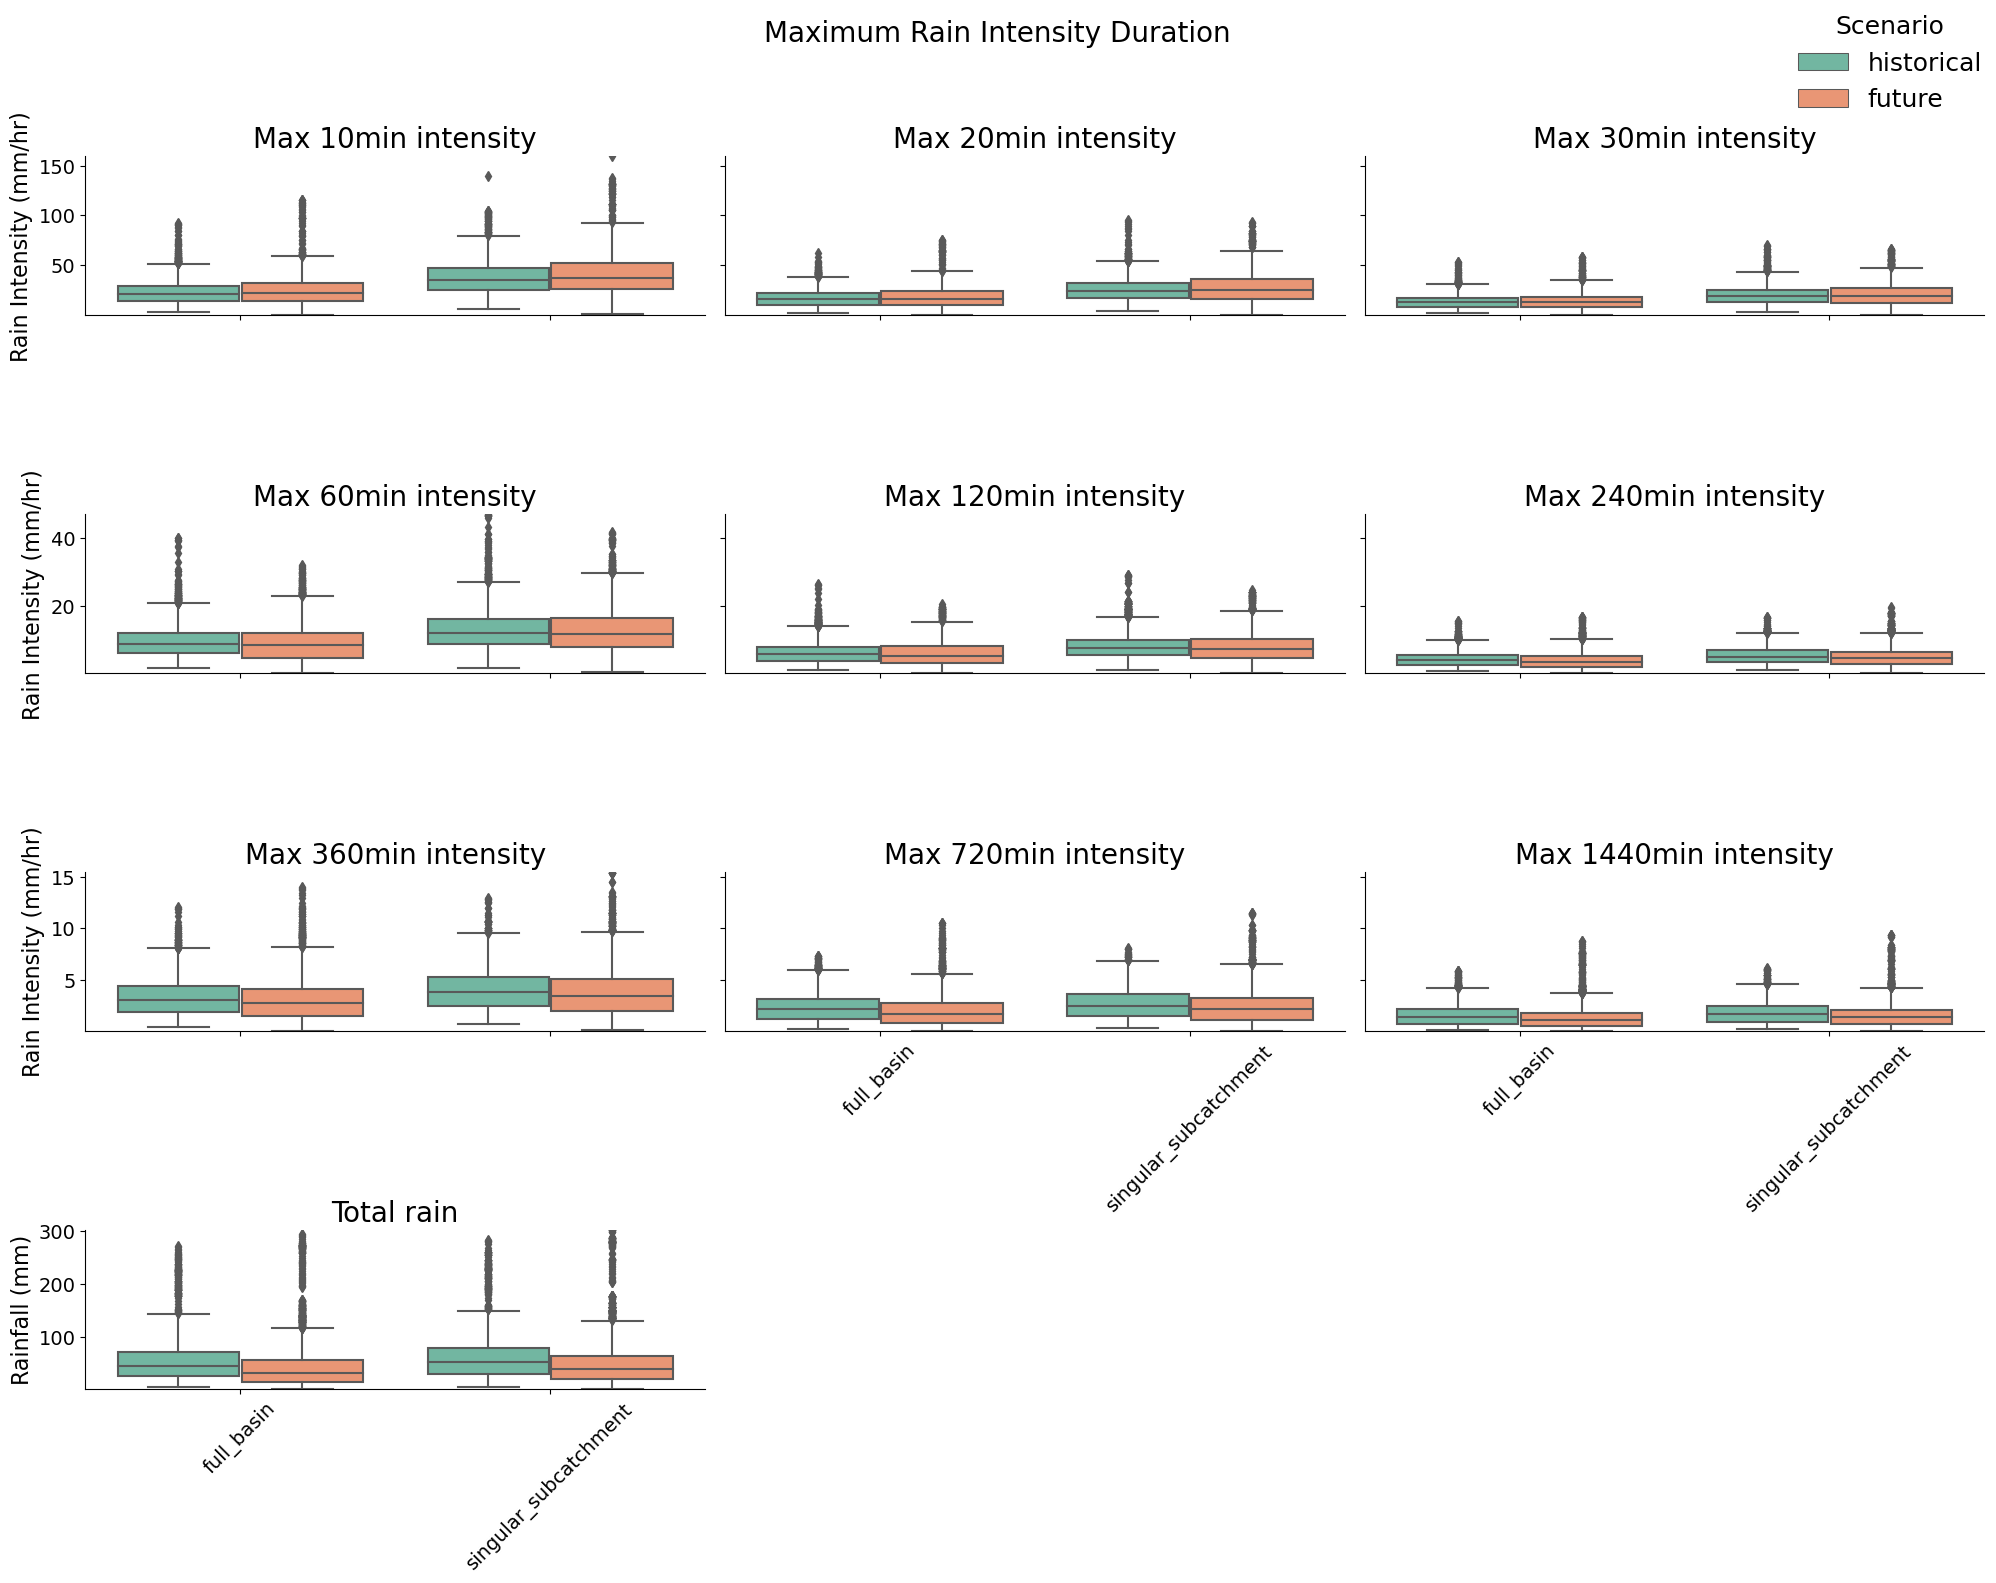

In [7]:
# Prepare the combined data as before
combined_data = []

for group in groups:
    for measure in rain_parameters:
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )
        melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']
        melted_df['group_label'] = group
        melted_df['intensity'] = measure
        combined_data.append(melted_df)

# Combine all data
combined_df = pd.concat(combined_data, ignore_index=True)


# Create a FacetGrid plot
g = sns.FacetGrid(combined_df, col="measure", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(sns.boxplot, x="group_label", y="value", hue="scenario", palette="Set2")

# Main title centered and spaced properly
plt.subplots_adjust(top=0.88, hspace=0.5)  # Add vertical space between subplots
g.fig.suptitle("Maximum Rain Intensity Duration", fontsize=20)

# Adjust y-axis labels dynamically
for ax, measure in zip(g.axes.flat, combined_df['measure'].unique()):
    if "total_rain" in measure:
        ax.set_ylabel("Rainfall (mm)", fontsize=16)  # Last subplot
    else:
        ax.set_ylabel("Rain Intensity (mm/hr)", fontsize=16)

# Adjust y-axis ranges dynamically for each row
unique_measures = list(combined_df['measure'].unique())
num_cols = 3  # Number of columns in the grid
for i in range(0, len(unique_measures), num_cols):
    row_axes = g.axes.flat[i:i + num_cols]  # Get all axes in the row
    row_measures = unique_measures[i:i + num_cols]  # Get measures for the row

    # Compute the shared y-axis range for the row
    y_min = min(combined_df[combined_df['measure'].isin(row_measures)]['value'])
    y_max = max(combined_df[combined_df['measure'].isin(row_measures)]['value'])

    # Set the y-axis range for all axes in the row
    for ax in row_axes:
        ax.set_ylim(y_min, y_max)

        # Show y-axis labels only for the leftmost subplot
        if ax != row_axes[0]:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)  # Hide tick labels

# Rotate x-axis labels to avoid overlap and remove x-axis labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', which='major', labelsize=14)
    ax.tick_params(axis='y', which='major', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_rotation(45)  # Rotate x-axis labels

    # Remove x-axis label
    ax.set_xlabel('')

# Customize subplot titles
for ax, measure in zip(g.axes.flat, combined_df['measure'].unique()):
    ax.set_title(measure.replace("_", " ").capitalize(), fontsize=20)

# Move the legend to a better position and enlarge it
g.add_legend(title="Scenario", fontsize=18, title_fontsize=18)  # Increase legend font size
g.legend.set_title("Scenario", prop={'size': 18})  # Explicitly set legend title font size
g.legend.set_bbox_to_anchor([1, 0.95])  # Place legend outside the plots

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit legend and title

# Save the plot
facet_grid_path = os.path.join(save_dir, "facet_grid_intensities_final_adjusted.png")
plt.savefig(facet_grid_path, bbox_inches="tight")  # Ensure all elements fit in the saved file
plt.show()


In [8]:
# Prepare data for grouped subplots
grouped_data = []

for group in groups:
    for measure in rain_parameters:
        melted_df = final_results_df.melt(
            id_vars=[('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')],
            value_vars=[
                ('historical', group, measure),
                ('future', group, measure)
            ],
            var_name=['scenario', 'group', 'measure'],
            value_name='value'
        )
                
        # Dynamically assign column names based on the structure of melted_df
        if len(melted_df.columns) == 7:  # If there are 7 columns, assign the correct names
            melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'measure', 'value']
        elif len(melted_df.columns) == 8:  # If there are 8 columns, assign the correct names
            melted_df.columns = ['event_num', 'x', 'y', 'd', 'scenario', 'group', 'measure', 'value']
        else:
            raise ValueError("Unexpected number of columns in melted_df. Please verify the structure of final_results_df.")

        melted_df['group_label'] = group
        melted_df['intensity'] = measure
        grouped_data.append(melted_df)

# Combine all data
grouped_df = pd.concat(grouped_data, ignore_index=True)


In [9]:
# Prepare median difference data
median_diff_data = []

for group in groups:
    for measure in rain_parameters:
        # Filter data for the current group and measure
        group_data = grouped_df[(grouped_df['group_label'] == group) & (grouped_df['measure'] == measure)]
        
        # Calculate medians for historical and future scenarios
        historical_median = group_data[group_data['scenario'] == 'historical']['value'].median()
        future_median = group_data[group_data['scenario'] == 'future']['value'].median()
        
        # Compute the difference (future - historical)
        diff = future_median - historical_median
        
        # Store the result
        median_diff_data.append({
            'measure': measure,
            'group_label': group,
            'median_diff': diff
        })

# Convert to DataFrame
median_diff_df = pd.DataFrame(median_diff_data)

# Shorten intensity names for better readability
short_labels = [label.replace("_intensity", "").replace("_", " ").capitalize() for label in rain_parameters]
median_diff_df['measure'] = median_diff_df['measure'].map(dict(zip(rain_parameters, short_labels)))



## Plot Normalization

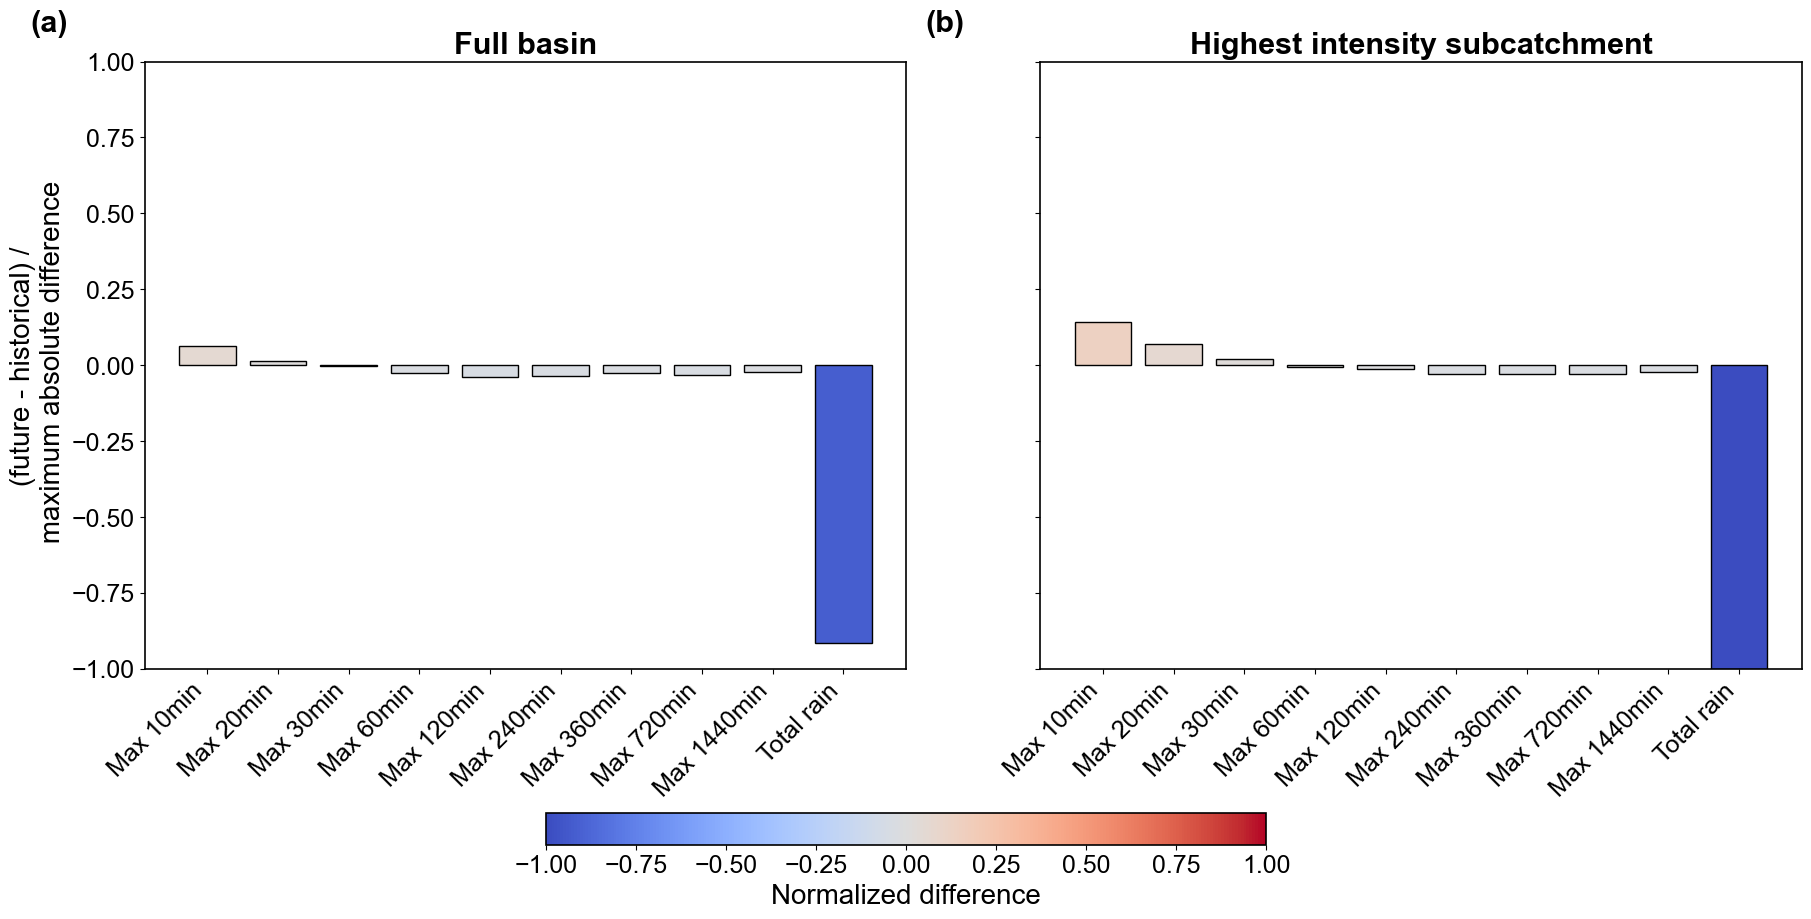

In [10]:
# Define font properties
TITLE_FONT = {'fontsize': 22, 'fontweight': 'bold'}
LABEL_FONT = {'fontsize': 20}
TICK_FONT = {'labelsize': 18}
LEGEND_FONT = {'fontsize': 18}
SUBPLOT_LABEL_FONT = {'fontsize': 22, 'fontweight': 'bold'}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2

# Normalize to absolute max value
median_diff_data = []
for group in groups:
    for measure in rain_parameters:
        group_data = grouped_df[(grouped_df['group_label'] == group) & (grouped_df['measure'] == measure)]
        
        historical_median = group_data[group_data['scenario'] == 'historical']['value'].median()
        future_median = group_data[group_data['scenario'] == 'future']['value'].median()
        
        diff = future_median - historical_median
        median_diff_data.append({'measure': measure, 'group_label': group, 'median_diff': diff})

# Convert to DataFrame
median_diff_df = pd.DataFrame(median_diff_data)

# Normalize by maximum absolute difference
max_abs_diff = abs(median_diff_df['median_diff']).max()
median_diff_df['normalized_diff'] = median_diff_df['median_diff'] / max_abs_diff

# Shorten intensity names
median_diff_df['measure'] = median_diff_df['measure'].map(dict(zip(rain_parameters, short_labels)))

# Color normalization
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = plt.cm.coolwarm

# Plot
fig, axes = plt.subplots(1, len(groups), figsize=(18, 8), sharey=True, constrained_layout=True)

for ax, group, subplot_label in zip(axes, groups, ['(a)', '(b)', '(c)']):
    group_data = median_diff_df[median_diff_df['group_label'] == group]
    colors = cmap(norm(group_data['normalized_diff']))
    
    bars = ax.bar(
        group_data['measure'], 
        group_data['normalized_diff'], 
        color=colors, 
        edgecolor='black'
    )
    
    ax.set_title(group.replace('_', ' ').replace('singular subcatchment', 'highest intensity subcatchment').capitalize(), **TITLE_FONT)
    
    if ax == axes[0]:
        ax.set_ylabel("(future - historical) /\n maximum absolute difference", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    
    ax.set_ylim(-1, 1)
#     ax.set_xlabel("Rainfall intensity measures", **LABEL_FONT)
    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    # Subplot label
    ax.text(-0.15, 1.05, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

# Add colorbar
cbar_ax = fig.add_axes([0.3, -0.05, 0.4, 0.04])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Normalized difference", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)

plt.savefig("rainfall_differences_publication.png", dpi=600, bbox_inches='tight', format='png')
plt.show()


### With shifts *pooled* analysis

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\159818860.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(group_data['measure'], rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\159818860.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


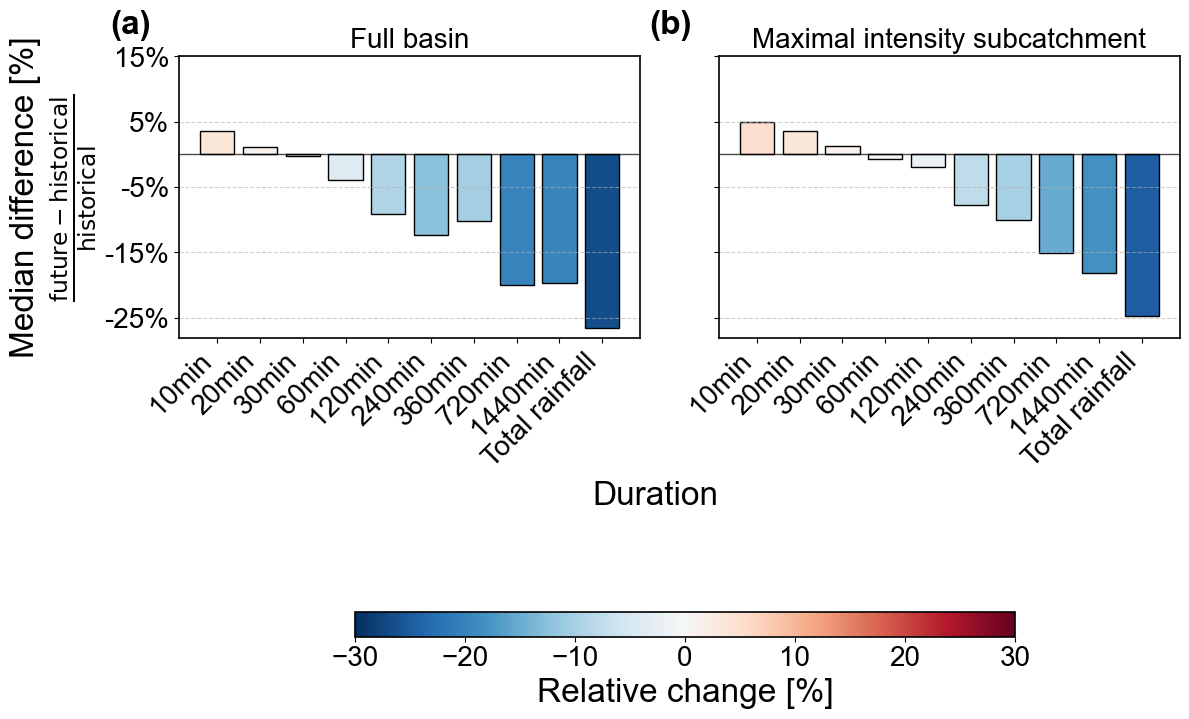

In [11]:
# Define font properties according to journal standards
TITLE_FONT = {'fontsize': 20}
LABEL_FONT = {'fontsize': 24}
TICK_FONT = {'labelsize': 20}
LEGEND_FONT = {'fontsize': 20}
SUBPLOT_LABEL_FONT = {'fontsize': 24, 'fontweight': 'bold'}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2  # Slightly thicker axis lines for visibility

# Prepare normalized difference data (relative to historical median)
normalized_diff_data = []

for group in groups:
    for measure in rain_parameters:
        # Filter data for the current group and measure
        group_data = grouped_df[(grouped_df['group_label'] == group) & (grouped_df['measure'] == measure)]
        
        # Calculate medians for historical and future scenarios
        historical_median = group_data[group_data['scenario'] == 'historical']['value'].median()
        future_median = group_data[group_data['scenario'] == 'future']['value'].median()
        
        # Compute the normalized difference in percentage
        diff = ((future_median - historical_median) / historical_median) * 100 if historical_median != 0 else None
        
        # Store the result
        normalized_diff_data.append({'measure': measure, 'group_label': group, 'normalized_diff': diff})

# Convert to DataFrame
normalized_diff_df = pd.DataFrame(normalized_diff_data)

# Shorten intensity names for readability
short_labels = [
    "Total rainfall" 
    if label.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize() == "Total rain"
    else label.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize()
    for label in rain_parameters
]
normalized_diff_df['measure'] = normalized_diff_df['measure'].map(dict(zip(rain_parameters, short_labels)))

# Determine color normalization
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
max_abs_diff = 30  # Adjust color scale to match extreme changes
norm = mcolors.TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0, vmax=max_abs_diff)
cmap = plt.cm.RdBu_r  # Adjusted for better contrast

# Adjust figure size for publication
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)

for ax, group, subplot_label in zip(axes, groups, ['(a)', '(b)', '(c)']):
    group_data = normalized_diff_df[normalized_diff_df['group_label'] == group]
    colors = cmap(norm(group_data['normalized_diff']))
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    
    # Plot bars
    bars = ax.bar(group_data['measure'], group_data['normalized_diff'], color=colors, edgecolor='black')
    
    # Add horizontal line at Y=0 (solid line)
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    
    # Subplot title
    ax.set_title(group.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize(), **TITLE_FONT)
    
    # Set Y-axis label for the first subplot only
    if ax == axes[0]:
        ax.set_ylabel("Median difference [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    
    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    
    # Format X-axis labels
    ax.set_xticklabels(group_data['measure'], rotation=45, ha='right')
    
    # Format Y-axis as percentages
    ax.set_yticks(np.arange(-25, 25, 10))
    ax.set_yticklabels([f"{int(tick)}%" for tick in ax.get_yticks()])
    
    # Add subplot labels (a), (b), (c)
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

# Add shared X-axis label
fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)

# Add colorbar
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])  # Adjusted position for smaller figure
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)

# Improve layout
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


### With shifts *conditional* analysis

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\2615272012.py:98: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\2615272012.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


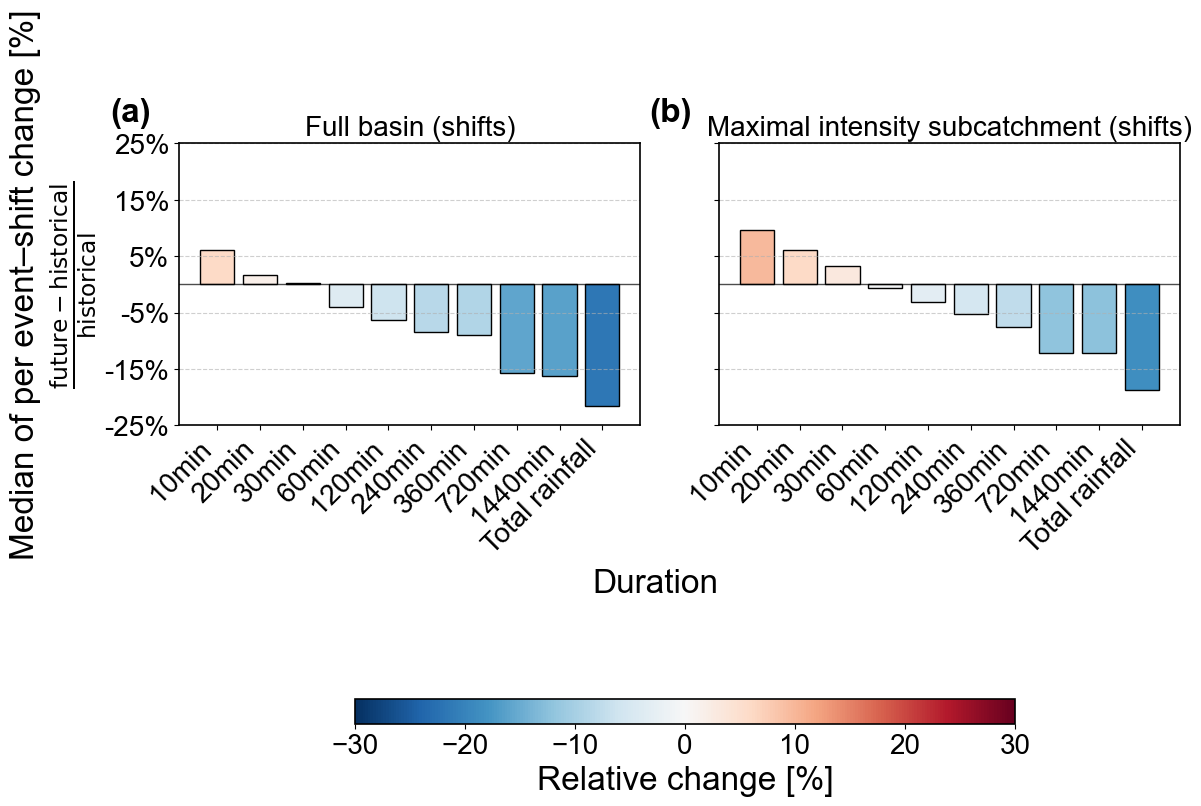

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\2615272012.py:139: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\2615272012.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


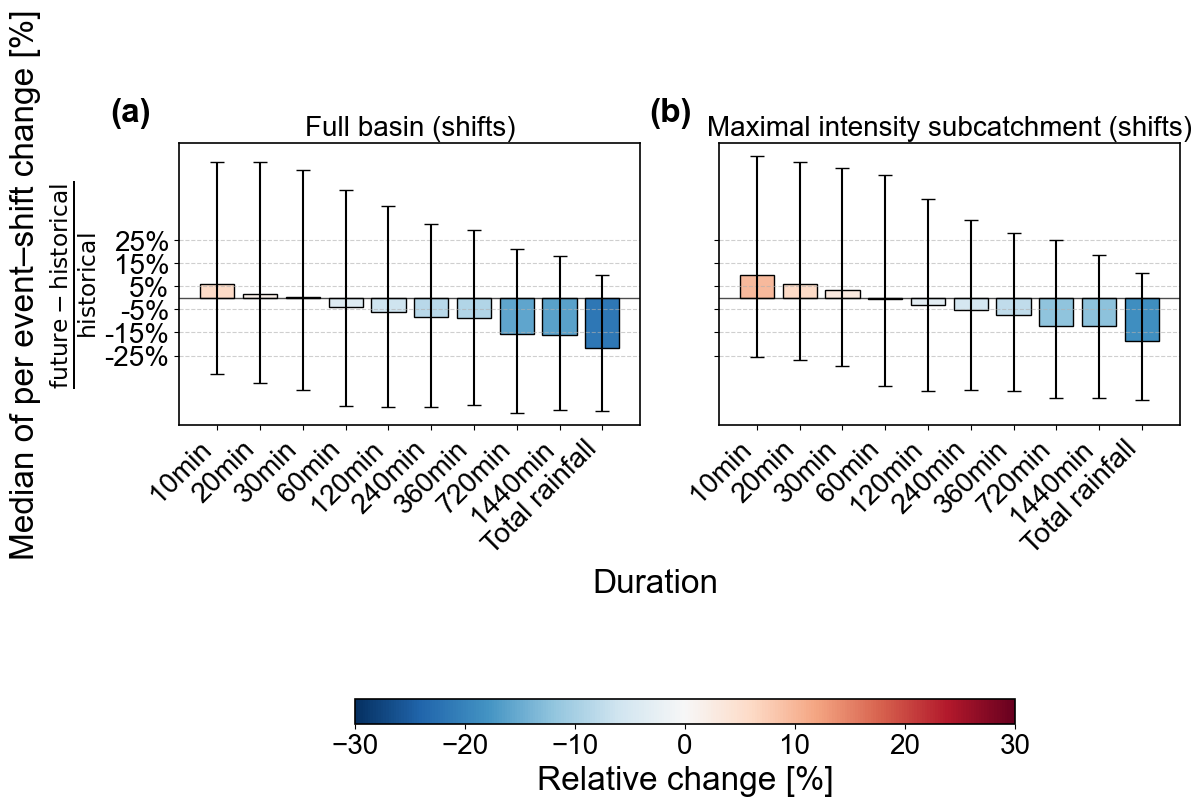

In [12]:
# 1) keep shifted rows only
shifts_df = grouped_df[(grouped_df['x'] != 0) | (grouped_df['y'] != 0)].copy()
if shifts_df.empty:
    raise ValueError("No shifted rows found (x!=0 or y!=0).")

def percent_change_per_unit_xy(df, group_label, measure):
    """
    Compute Δ% per unit where unit = (event_num, x, y) for a given group and measure.
    Δ% = (median_future - median_historical) / median_historical * 100
    """
    sel = df[(df['group_label'] == group_label) & (df['measure'] == measure)].copy()
    if sel.empty:
        return pd.Series(dtype=float)

    required_cols = {'event_num','x','y','scenario','value'}
    missing = required_cols - set(sel.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # median per scenario for each unit (event_num, x, y)
    pivot = (sel.groupby(['event_num', 'x', 'y', 'scenario'])['value']
               .median()
               .unstack())  # columns should be 'historical' and 'future'

    if pivot is None or 'historical' not in pivot.columns or 'future' not in pivot.columns:
        return pd.Series(dtype=float)

    hist = pivot['historical']
    fut  = pivot['future']
    delta_pct = np.where(hist != 0, (fut - hist) / hist * 100.0, np.nan)
    delta_pct = pd.Series(delta_pct, index=pivot.index).replace([np.inf, -np.inf], np.nan).dropna()
    return delta_pct

# 2) aggregate to plotting data by group and duration
plot_data = {g: {'labels': [], 'med': [], 'err_low': [], 'err_up': []} for g in groups}

for g in groups:
    for m in rain_parameters:
        pct = percent_change_per_unit_xy(shifts_df, g, m)
        if pct.empty:
            med = np.nan; q25 = np.nan; q75 = np.nan
        else:
            med = float(np.nanmedian(pct))
            q25 = float(np.nanpercentile(pct, 25))
            q75 = float(np.nanpercentile(pct, 75))

        # short label formatting like your other cell
        lbl = ("Total rainfall"
               if m.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize() == "Total rain"
               else m.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize())

        plot_data[g]['labels'].append(lbl)
        plot_data[g]['med'].append(med)
        # IQR around median as asymmetric error bars
        plot_data[g]['err_low'].append(max(0, med - q25) if np.isfinite(med) and np.isfinite(q25) else 0.0)
        plot_data[g]['err_up'].append(max(0, q75 - med) if np.isfinite(med) and np.isfinite(q75) else 0.0)

# 3) plotting

TITLE_FONT = {'fontsize': 20}
LABEL_FONT = {'fontsize': 24}
TICK_FONT = {'labelsize': 20}
SUBPLOT_LABEL_FONT = {'fontsize': 24, 'fontweight': 'bold'}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2

max_abs_diff = 30
norm = mcolors.TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0, vmax=max_abs_diff)
cmap = plt.cm.RdBu_r

subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)'][:len(groups)]

# 3.1 bars without error bars
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)
if len(groups) == 1:
    axes = [axes]

for ax, g, subplot_label in zip(axes, groups, subplot_labels):
    labels = plot_data[g]['labels']
    med = np.array(plot_data[g]['med'], dtype=float)
    colors = cmap(norm(med))

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.bar(labels, med, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    title_txt = g.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize() + " (shifts)"
    ax.set_title(title_txt, **TITLE_FONT)

    if ax is axes[0]:
        ax.set_ylabel("Median of per event–shift change [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(-25, 26, 10))
    ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# 3.2 bars with IQR error bars
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)
if len(groups) == 1:
    axes = [axes]

for ax, g, subplot_label in zip(axes, groups, subplot_labels):
    labels = plot_data[g]['labels']
    med = np.array(plot_data[g]['med'], dtype=float)
    yerr = np.vstack([plot_data[g]['err_low'], plot_data[g]['err_up']])
    colors = cmap(norm(med))

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.bar(labels, med, yerr=yerr, color=colors, edgecolor='black', capsize=5)
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    title_txt = g.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize() + " (shifts)"
    ax.set_title(title_txt, **TITLE_FONT)

    if ax is axes[0]:
        ax.set_ylabel("Median of per event–shift change [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(-25, 26, 10))
    ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


### No shift x,y=0, *pooled* analysis

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\667621787.py:69: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(group_data['measure'], rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\667621787.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


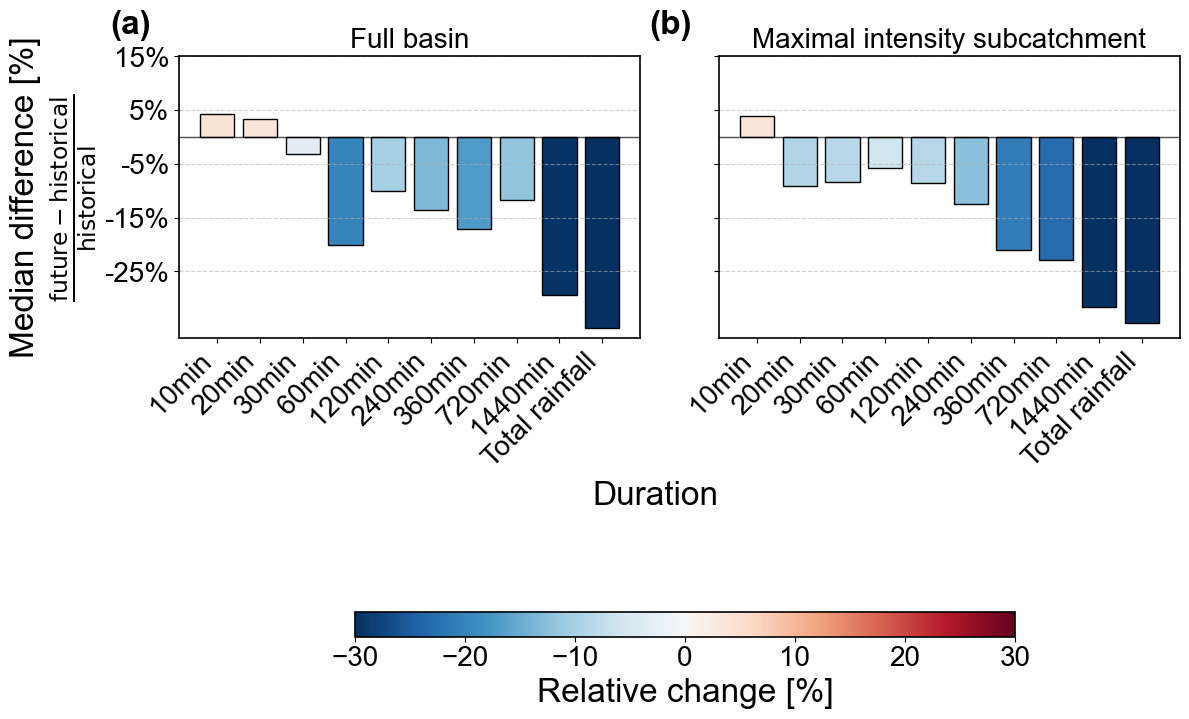

In [13]:
# Filter for no-shift
no_shift_df = grouped_df[(grouped_df['x'] == 0) & (grouped_df['y'] == 0)].copy()

# Define font properties according to journal standards (reuse to be self-contained)
TITLE_FONT = {'fontsize': 20}
LABEL_FONT = {'fontsize': 24}
TICK_FONT = {'labelsize': 20}
LEGEND_FONT = {'fontsize': 20}
SUBPLOT_LABEL_FONT = {'fontsize': 24, 'fontweight': 'bold'}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2

# Prepare normalized difference data (relative to historical median)
normalized_diff_data = []

for group in groups:
    for measure in rain_parameters:
        gd = no_shift_df[(no_shift_df['group_label'] == group) & (no_shift_df['measure'] == measure)]
        historical_median = gd[gd['scenario'] == 'historical']['value'].median()
        future_median = gd[gd['scenario'] == 'future']['value'].median()
        diff = ((future_median - historical_median) / historical_median) * 100 if historical_median != 0 else None
        normalized_diff_data.append({'measure': measure, 'group_label': group, 'normalized_diff': diff})

normalized_diff_df = pd.DataFrame(normalized_diff_data)

# Shorten intensity names for readability
short_labels = [
    "Total rainfall" if label.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize() == "Total rain"
    else label.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize()
    for label in rain_parameters
]
normalized_diff_df['measure'] = normalized_diff_df['measure'].map(dict(zip(rain_parameters, short_labels)))

# Color normalization
import matplotlib.colors as mcolors
max_abs_diff = 30
norm = mcolors.TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0, vmax=max_abs_diff)
cmap = plt.cm.RdBu_r

# Create figure
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)

for ax, group, subplot_label in zip(axes, groups, ['(a)', '(b)', '(c)']):
    group_data = normalized_diff_df[normalized_diff_df['group_label'] == group]
    colors = cmap(norm(group_data['normalized_diff']))
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    # Bars
    ax.bar(group_data['measure'], group_data['normalized_diff'], color=colors, edgecolor='black')

    # Y=0 line
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    # Title
    ax.set_title((group.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize()),
                 **TITLE_FONT)

    # Y label only on first subplot
    if ax == axes[0]:
        ax.set_ylabel("Median difference [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)

    # X labels
    ax.set_xticklabels(group_data['measure'], rotation=45, ha='right')

    # Y ticks as percentages
    ax.set_yticks(np.arange(-25, 25, 10))
    ax.set_yticklabels([f"{int(tick)}%" for tick in ax.get_yticks()])

    # Subplot label
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

# Shared X label
fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)

# Colorbar
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

### No shift x,y=0, pooled analysis

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\4191713375.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\4191713375.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


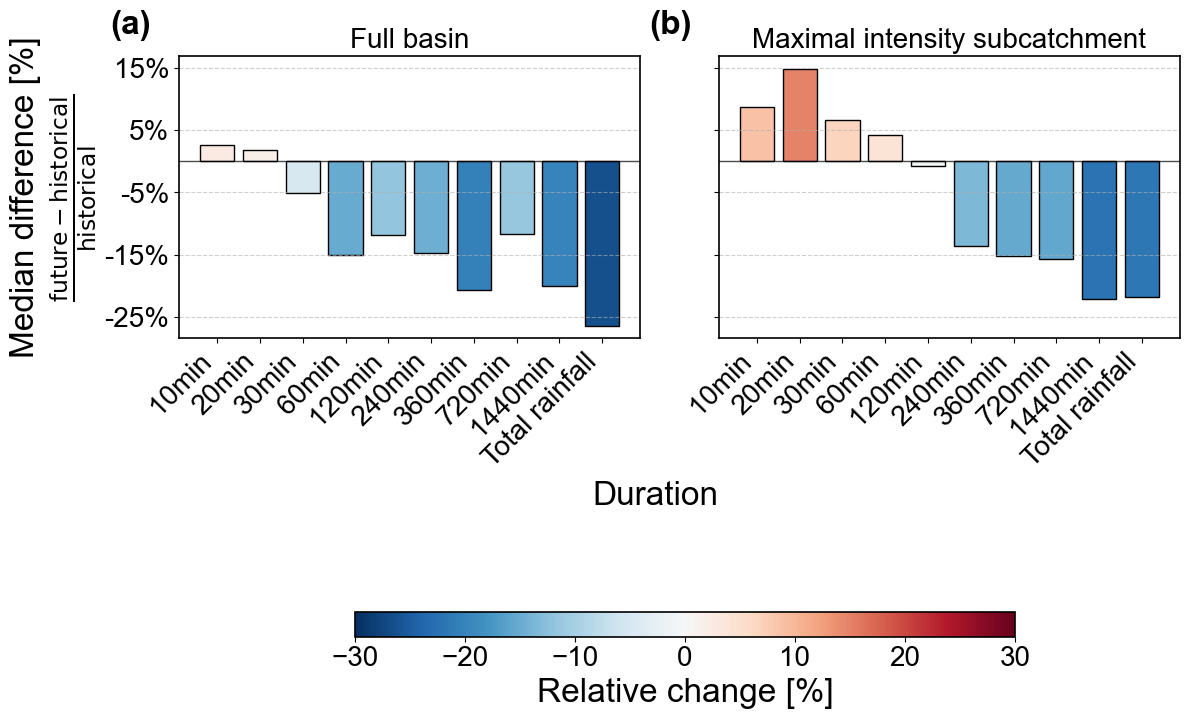

C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\4191713375.py:109: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha='right')
C:\Users\raznu\AppData\Local\Temp\ipykernel_40756\4191713375.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


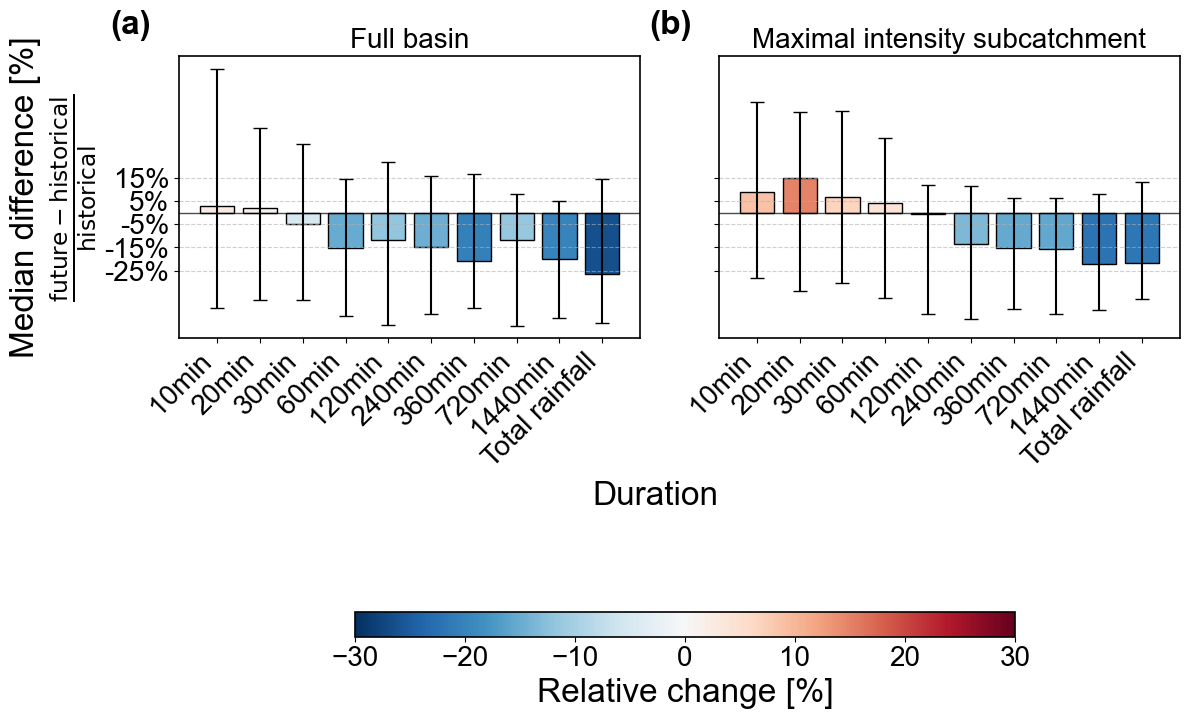

In [14]:

# Ensure no-shift filtered data exists
if 'no_shift_df' not in globals() or no_shift_df is None or no_shift_df.empty:
    no_shift_df = grouped_df[(grouped_df['x'] == 0) & (grouped_df['y'] == 0)].copy()

# Helper: event-wise percent change per (group, measure)
def eventwise_percent_change(df, group_label, measure):
    sel = df[(df['group_label'] == group_label) & (df['measure'] == measure)]
    if sel.empty:
        return pd.Series(dtype=float)
    # Per-event, per-scenario median, then compute percent change per event
    pivot = sel.groupby(['event_num', 'scenario'])['value'].median().unstack()
    if pivot is None or 'historical' not in pivot.columns or 'future' not in pivot.columns:
        return pd.Series(dtype=float)
    pct = ((pivot['future'] - pivot['historical']) / pivot['historical']) * 100
    return pct.replace([np.inf, -np.inf], np.nan).dropna()

# Build plotting data with medians and IQR-based asymmetric errors (across events)
plot_data = {g: {'labels': [], 'med': [], 'err_low': [], 'err_up': []} for g in groups}
for g in groups:
    for m in rain_parameters:
        pct = eventwise_percent_change(no_shift_df, g, m)
        if pct.empty:
            med = np.nan; q25 = np.nan; q75 = np.nan
        else:
            med = pct.median()
            q25 = pct.quantile(0.25)
            q75 = pct.quantile(0.75)
        # Short label for x-axis
        lbl = ("Total rainfall" if m.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize() == "Total rain"
               else m.replace("max", "").replace("_intensity", "").replace("_", " ").strip().capitalize())
        plot_data[g]['labels'].append(lbl)
        plot_data[g]['med'].append(med)
        plot_data[g]['err_low'].append(max(0, med - q25) if pd.notna(med) and pd.notna(q25) else 0.0)
        plot_data[g]['err_up'].append(max(0, q75 - med) if pd.notna(med) and pd.notna(q75) else 0.0)

# Styling (consistent with earlier cells)
TITLE_FONT = {'fontsize': 20}
LABEL_FONT = {'fontsize': 24}
TICK_FONT = {'labelsize': 20}
SUBPLOT_LABEL_FONT = {'fontsize': 24, 'fontweight': 'bold'}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2

# Color mapping by median value
max_abs_diff = 30
norm = mcolors.TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0, vmax=max_abs_diff)
cmap = plt.cm.RdBu_r

# ---- 1) Bars without error bars ----
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)
subplot_labels = ['(a)', '(b)'] if len(groups) == 2 else ['(a)', '(b)', '(c)']
for ax, g, subplot_label in zip(axes, groups, subplot_labels):
    labels = plot_data[g]['labels']
    med = np.array(plot_data[g]['med'], dtype=float)
    colors = cmap(norm(med))

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.bar(labels, med, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    ax.set_title(g.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize(),
                 **TITLE_FONT)
    if ax == axes[0]:
        ax.set_ylabel("Median difference [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(-25, 25, 10))
    ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)
# Colorbar
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# ---- 2) Bars + the same IQR error bars ----
fig, axes = plt.subplots(1, len(groups), figsize=(12, 5), sharey=True)
for ax, g, subplot_label in zip(axes, groups, subplot_labels):
    labels = plot_data[g]['labels']
    med = np.array(plot_data[g]['med'], dtype=float)
    yerr = np.vstack([plot_data[g]['err_low'], plot_data[g]['err_up']])
    colors = cmap(norm(med))

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.bar(labels, med, yerr=yerr, color=colors, edgecolor='black', capsize=5)
    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.7)

    ax.set_title(g.replace('_', ' ').replace('singular subcatchment', 'Maximal intensity subcatchment').capitalize(),
                 **TITLE_FONT)
    if ax == axes[0]:
        ax.set_ylabel("Median difference [%]\n$\\frac{\\mathrm{future} - \\mathrm{historical}}{\\mathrm{historical}}$", **LABEL_FONT)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', **TICK_FONT)
    ax.tick_params(axis='y', **TICK_FONT)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(-25, 25, 10))
    ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
    ax.text(-0.15, 1.08, subplot_label, transform=ax.transAxes, **SUBPLOT_LABEL_FONT)

fig.text(0.55, -0.02, "Duration", ha='center', va='center', **LABEL_FONT)
# Colorbar
cbar_ax = fig.add_axes([0.3, -0.3, 0.55, 0.05])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Relative change [%]", **LABEL_FONT)
cbar.ax.tick_params(**TICK_FONT)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()